<a href="https://colab.research.google.com/github/Minwoo5/BDAI-13th-Cohort/blob/main/ML1/Lecture/260924_01_%E1%84%8C%E1%85%A5%E1%86%AB%E1%84%8E%E1%85%A5%E1%84%85%E1%85%B5_%E1%84%80%E1%85%A7%E1%86%AF%E1%84%8E%E1%85%B3%E1%86%A8%E1%84%8E%E1%85%B5%E1%84%8B%E1%85%AA_%E1%84%8B%E1%85%B5%E1%84%89%E1%85%A1%E1%86%BC%E1%84%8E%E1%85%B5_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 데이터 전처리 실습 (1) · 결측치와 이상치

Applied Data Analysis / ML1 모델링반

In [ ]:
# ============================================================
# 0-1. 환경 설정
# ============================================================
import warnings
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
from scipy import stats

from sklearn.impute import SimpleImputer, KNNImputer, MissingIndicator
from sklearn.experimental import enable_iterative_imputer  # noqa: F401
from sklearn.impute import IterativeImputer
from sklearn.linear_model import (LinearRegression, Ridge, BayesianRidge,
                                  HuberRegressor, RANSACRegressor, LogisticRegression)
from sklearn.ensemble import IsolationForest, RandomForestRegressor
from sklearn.neighbors import LocalOutlierFactor, NearestNeighbors
from sklearn.covariance import MinCovDet, EmpiricalCovariance
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import (mean_squared_error, mean_absolute_error, r2_score,
                             roc_auc_score, average_precision_score,
                             confusion_matrix, classification_report)

warnings.filterwarnings("ignore")

# ---- 한글 폰트 ----
def set_korean_font():
    # 설치된 폰트 중 한글 글리프를 가진 것을 우선순위대로 찾는다.
    # Colab -> NanumGothic, Windows -> Malgun Gothic, macOS -> AppleGothic,
    # Linux -> Noto Sans CJK (JP/KR 어느 쪽이든 한글 글리프를 포함한다)
    candidates = ["NanumGothic", "NanumBarunGothic", "Malgun Gothic", "AppleGothic",
                  "Noto Sans CJK KR", "Noto Sans KR",
                  "Noto Sans CJK JP", "Noto Sans CJK SC", "Noto Sans CJK TC",
                  "Source Han Sans KR", "UnDotum"]
    available = {f.name for f in fm.fontManager.ttflist}
    for name in candidates:
        if name in available:
            mpl.rcParams["font.family"] = name
            return name
    print("[주의] 한글 폰트를 찾지 못했습니다. 그림의 한글이 깨질 수 있습니다.")
    print("       Colab에서는 아래를 실행한 뒤 런타임을 재시작하세요.")
    print("       !apt-get install -y fonts-nanum && rm -rf ~/.cache/matplotlib")
    return mpl.rcParams["font.family"]

# 주의: seaborn의 set_style()은 font.family 를 "sans-serif"로 되돌려 놓는다.
#       그래서 스타일을 먼저 적용하고 폰트를 나중에 지정해야 한글이 살아남는다.
sns.set_style("whitegrid", {"grid.alpha": 0.25})

FONT = set_korean_font()
mpl.rcParams["font.family"] = FONT
mpl.rcParams["axes.unicode_minus"] = False

# 라벨 안에서 한글과 $수식$ 을 섞어 쓰면 mathtext가 문자열 전체를 파싱하면서
# 한글 부분까지 수식용 폰트로 그리려다 글자가 네모로 깨진다.
# mathtext 폰트를 한글 폰트로 지정해 두면 "이론값 $(1-r)^4$" 같은 라벨이 정상 출력된다.
mpl.rcParams["mathtext.fontset"] = "custom"
for key in ("mathtext.rm", "mathtext.it", "mathtext.bf",
            "mathtext.sf", "mathtext.cal", "mathtext.tt"):
    mpl.rcParams[key] = FONT

mpl.rcParams["figure.dpi"] = 110
mpl.rcParams["savefig.dpi"] = 110
mpl.rcParams["axes.grid"] = True
mpl.rcParams["grid.alpha"] = 0.25
mpl.rcParams["axes.titlesize"] = 11
mpl.rcParams["axes.labelsize"] = 10
mpl.rcParams["font.size"] = 9.5

# ---- 노트북 전체에서 쓰는 색 약속 ----
# 파랑 = 관측/정상/처리 후,  빨강 = 결측/이상/진리,  회색 = 보조
C = {
    "blue":  "#2E5FA3",
    "red":   "#C0392B",
    "green": "#1E8449",
    "amber": "#D68910",
    "gray":  "#7F8C8D",
    "light": "#BFD3E6",
    "dark":  "#1B2631",
}

RNG_SEED = 42
rng = np.random.default_rng(RNG_SEED)

print(f"한글 폰트 : {FONT}")
print(f"pandas    : {pd.__version__}")
print(f"numpy     : {np.__version__}")
import sklearn; print(f"sklearn   : {sklearn.__version__}")

한글 폰트 : Noto Sans CJK JP
pandas    : 3.0.2
numpy     : 2.4.4
sklearn   : 1.8.0


In [ ]:
# ============================================================
# 0-2. 그림을 반복해서 그리기 위한 작은 도구들
# ============================================================

def panel(nrows=1, ncols=1, w=5.0, h=3.6, **kw):
    """일관된 크기의 subplot 격자를 만든다."""
    fig, axes = plt.subplots(nrows, ncols, figsize=(w * ncols, h * nrows), **kw)
    return fig, axes


def annotate_bars(ax, fmt="{:.3f}", dy=0.01, fontsize=8):
    """막대 위에 값을 적는다."""
    ymax = ax.get_ylim()[1]
    for p in ax.patches:
        v = p.get_height()
        if np.isfinite(v):
            ax.text(p.get_x() + p.get_width() / 2, v + ymax * dy,
                    fmt.format(v), ha="center", va="bottom", fontsize=fontsize)


def summarize(name, y_true, y_pred):
    """회귀 성능 한 줄 요약."""
    return {
        "전략": name,
        "RMSE": float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "MAE": float(mean_absolute_error(y_true, y_pred)),
        "R2": float(r2_score(y_true, y_pred)),
    }


def show_table(df, caption=None, floatfmt="{:.4f}"):
    """표를 보기 좋게 출력한다."""
    if caption:
        print(caption)
        print("-" * max(len(caption), 40))
    with pd.option_context("display.float_format", floatfmt.format,
                           "display.max_columns", 50, "display.width", 200):
        print(df.to_string(index=False) if isinstance(df, pd.DataFrame) else df)
    print()

---

# 0부. 실험 데이터 설계

## 합성 데이터로 시작하는 이유

실제 데이터에는 결정적인 약점이 하나 있습니다. 정답을 모른다는 것이죠.

결측을 채웠을 때 우리가 넣은 값이 맞았는지 틀렸는지 확인할 방법이 없습니다. 원래 값이 없으니까요.
이상치를 지웠을 때 그것이 진짜 오류였는지 의미 있는 신호였는지도 알 수 없습니다.
그래서 처리 전후를 비교하는 실험은 실제 데이터로는 원리적으로 불가능합니다.

지난 OT에서 진짜 위험도 $R(f)$ 를 계산하려고 세상을 직접 만들었던 것과 같은 전략을 씁니다.
데이터를 우리가 만들면 세 가지가 가능해집니다.
결측을 주입하기 전의 원본 값을 알고 있으니 대치 품질을 RMSE로 직접 잴 수 있고,
어떤 점을 이상치로 심었는지 알고 있으니 탐지 알고리즘을 ROC-AUC로 평가할 수 있습니다.
그리고 데이터를 만들 때 쓴 진짜 회귀계수를 알고 있으니, 전처리가 계수 추정을 얼마나 비틀었는지 볼 수 있습니다.

현실에서는 이 셋 중 어느 것도 할 수 없습니다. 그러니까 여기서 감각을 익혀 두고 나가는 겁니다.

## 데이터 생성 모형

아파트 매매가를 흉내 낸 데이터를 만듭니다. 진짜 구조는 이렇게 둡니다.

$$
\text{price} = \beta_0 + \beta_1\,\text{area} + \beta_2\,\text{rooms} + \beta_3\,\text{age}
+ \beta_4\,\text{dist} + \beta_5\,\text{floor} + \varepsilon,
\qquad \varepsilon \sim \mathcal N(0,\sigma^2)
$$

여기서 한 가지를 의도적으로 설계합니다. 변수들 사이에 상관 구조를 넣는 겁니다.
면적이 크면 방이 많고, 역에서 멀면 대체로 건물이 조금 더 오래됐다는 식으로요.

이 상관이 있어야 KNN이나 MICE 같은 다변량 대치가 평균 대체보다 나은 이유를 볼 수 있습니다.
변수들이 서로 완전히 무관하다면 다른 변수를 아무리 들여다봐도 얻을 정보가 없으니
평균 대체보다 나을 방법이 없거든요. 뒤에서 이 점을 `floor` 변수로 직접 확인합니다.

In [ ]:
# ============================================================
# 0-3. 깨끗한 원본 데이터 생성
# ============================================================
N = 2000

def make_clean_data(n=N, seed=RNG_SEED):
    r = np.random.default_rng(seed)

    # --- 상관을 가진 잠재 요인 ---
    # z1: 주거 규모 요인, z2: 입지 요인
    z1 = r.normal(0, 1, n)
    z2 = r.normal(0, 1, n)

    area  = 60 + 22 * z1 + r.normal(0, 6, n)              # 전용면적(m^2)
    rooms = np.clip(np.round(2 + 0.9 * z1 + r.normal(0, 0.45, n)), 1, 6)  # 방 개수
    dist  = np.clip(400 + 380 * z2 + r.normal(0, 140, n), 30, None)       # 역까지 거리(m)
    age   = np.clip(12 + 6.5 * z2 + r.normal(0, 4.5, n), 0, 45)           # 연식(년)
    floor = np.clip(np.round(r.gamma(3.2, 2.6, n)), 1, 30)                # 층

    beta = dict(const=120.0, area=4.6, rooms=9.0, age=-2.2, dist=-0.028, floor=1.1)
    sigma = 26.0

    price = (beta["const"]
             + beta["area"]  * area
             + beta["rooms"] * rooms
             + beta["age"]   * age
             + beta["dist"]  * dist
             + beta["floor"] * floor
             + r.normal(0, sigma, n))

    df = pd.DataFrame({
        "area": area.round(1),
        "rooms": rooms.astype(int),
        "age": age.round(1),
        "dist": dist.round(0),
        "floor": floor.astype(int),
        "price": price.round(1),
    })
    return df, beta, sigma


clean, TRUE_BETA, TRUE_SIGMA = make_clean_data()
FEATURES = ["area", "rooms", "age", "dist", "floor"]
TARGET = "price"

print(f"원본 데이터: {clean.shape[0]}행 × {clean.shape[1]}열, 결측 {clean.isna().sum().sum()}개")
print(f"진짜 계수  : {TRUE_BETA}")
print(f"진짜 잡음  : sigma = {TRUE_SIGMA}  ->  이론상 도달 가능한 최소 RMSE = {TRUE_SIGMA:.1f}")
print()
clean.head()

원본 데이터: 2000행 × 6열, 결측 0개
진짜 계수  : {'const': 120.0, 'area': 4.6, 'rooms': 9.0, 'age': -2.2, 'dist': -0.028, 'floor': 1.1}
진짜 잡음  : sigma = 26.0  ->  이론상 도달 가능한 최소 RMSE = 26.0



,area,rooms,age,dist,floor,price
0,68.2,2,9.9,275.0,6,401.3
1,42.5,1,11.7,320.0,3,255.9
2,78.1,3,8.2,735.0,8,433.2
3,94.1,3,12.4,433.0,3,589.8
4,25.7,1,6.6,30.0,5,179.6


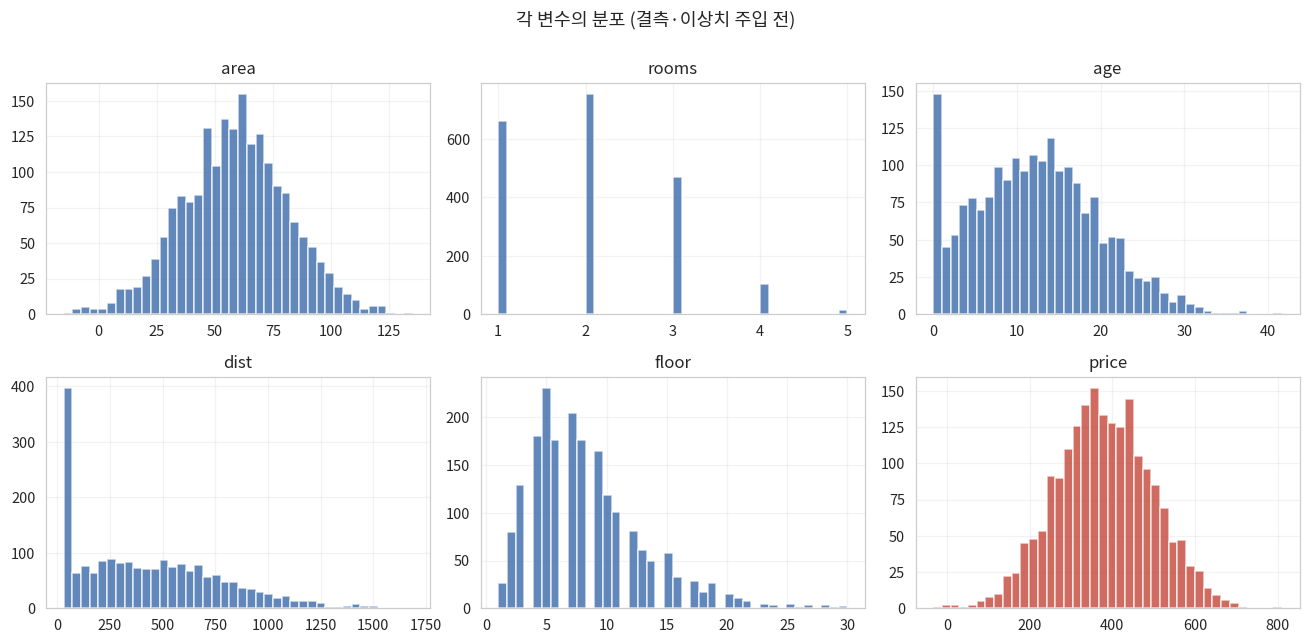

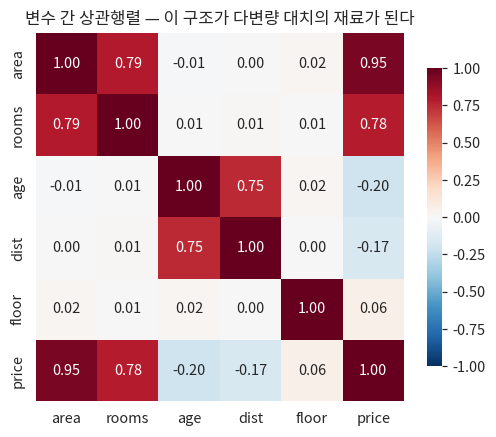

기초 통계량
----------------------------------------
   변수   count   mean    std    min    25%    50%    75%     max
 area 2000.00  58.87  22.83 -15.20  43.90  59.45  73.93  135.30
rooms 2000.00   2.03   0.91   1.00   1.00   2.00   3.00    5.00
  age 2000.00  12.22   7.39   0.00   6.70  12.15  17.10   41.70
 dist 2000.00 440.82 344.04  30.00 130.00 395.00 674.25 1687.00
floor 2000.00   8.28   4.69   1.00   5.00   7.00  11.00   30.00
price 2000.00 380.44 116.85 -33.90 301.65 380.50 460.42  811.30



In [ ]:
# ============================================================
# 0-4. 데이터 한눈에 보기
# ============================================================
fig, axes = panel(2, 3, w=4.0, h=2.9)
for ax, col in zip(axes.ravel(), FEATURES + [TARGET]):
    ax.hist(clean[col], bins=40,
            color=C["red"] if col == TARGET else C["blue"], alpha=0.75, edgecolor="white")
    ax.set_title(col)
    ax.set_ylabel("")
fig.suptitle("각 변수의 분포 (결측·이상치 주입 전)", y=1.00, fontsize=12)
fig.tight_layout()
plt.show()

# 상관행렬
corr = clean.corr()
fig, ax = panel(1, 1, w=5.4, h=4.4)
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            vmin=-1, vmax=1, square=True, cbar_kws={"shrink": .8}, ax=ax)
ax.set_title("변수 간 상관행렬 — 이 구조가 다변량 대치의 재료가 된다")
plt.show()

show_table(clean.describe().T.reset_index().rename(columns={"index": "변수"}),
           "기초 통계량", "{:.2f}")

## 상관행렬을 어떻게 읽어야 하는가

`area`와 `rooms`의 상관이 높게 나옵니다. 같은 잠재 요인 $z_1$ 에서 만들었으니 당연한 결과입니다.
`dist`와 `age`도 서로 관계가 있고, 이쪽은 $z_2$ 에서 나왔습니다.
반면 `floor`는 다른 어떤 변수와도 거의 무관하도록 따로 만들었습니다.

이 차이를 기억해 두세요. 나중에 결측을 주입하고 대치할 때,
`area`가 비어 있으면 `rooms`를 보고 꽤 정확하게 복원할 수 있습니다.
그런데 `floor`가 비어 있으면 어떤 방법을 써도 잘 복원되지 않습니다. 참조할 단서가 없으니까요.

강의에서 말한 원칙이 바로 여기서 확인됩니다. 중요한 것은 결측률이 아니라
그 변수가 다른 변수들로 얼마나 예측 가능한가입니다.
상관이 없는 변수는 결측률이 5%여도 대치가 사실상 무의미하고,
상관이 강한 변수는 30%가 비어 있어도 꽤 잘 복원됩니다.

---

# 1부. 결측치

## 1-1. 세 가지 메커니즘을 직접 만들어 보기

$R$ 을 결측 지시변수라고 두겠습니다. 관측되면 1, 결측이면 0입니다.
세 메커니즘은 $R$ 이 무엇에 의존하느냐로 갈립니다.
MCAR은 $Y \perp\!\!\!\perp R$ 로 아무것에도 의존하지 않고,
MAR은 $Y \perp\!\!\!\perp R \mid X$ 로 관측된 변수에만 의존하며,
MNAR은 어느 쪽도 성립하지 않아 자기 값에 의존합니다.

정의만 보면 구분이 잘 안 됩니다. 그래서 직접 만들어서 눈으로 보겠습니다.
세 경우 모두 `price`에 똑같이 25%의 결측을 주입하되, 빠지는 규칙만 다르게 합니다.
MCAR은 동전을 던져서 빼고, MAR은 `area`가 작을수록 빠질 확률을 높이고,
MNAR은 `price` 자체가 높을수록 빠지게 합니다. 고가 매물이 가격 공개를 꺼린다는 설정이죠.

In [ ]:
# ============================================================
# 1-1. 세 가지 메커니즘으로 결측 주입
# ============================================================
def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))


def inject_mcar(df, col, rate=0.25, seed=0):
    r = np.random.default_rng(seed)
    out = df.copy()
    mask = r.random(len(df)) < rate
    out.loc[mask, col] = np.nan
    return out, mask


def inject_mar(df, col, driver, rate=0.25, strength=2.2, seed=0):
    """driver 변수가 작을수록 col이 결측될 확률이 높다."""
    r = np.random.default_rng(seed)
    z = -strength * stats.zscore(df[driver].to_numpy())
    p = sigmoid(z)
    p = p * (rate / p.mean())          # 전체 결측률을 rate에 맞춤
    mask = r.random(len(df)) < np.clip(p, 0, 1)
    out = df.copy()
    out.loc[mask, col] = np.nan
    return out, mask


def inject_mnar(df, col, rate=0.25, strength=2.2, seed=0):
    """col 값 자체가 클수록 col이 결측될 확률이 높다."""
    r = np.random.default_rng(seed)
    z = strength * stats.zscore(df[col].to_numpy())
    p = sigmoid(z)
    p = p * (rate / p.mean())
    mask = r.random(len(df)) < np.clip(p, 0, 1)
    out = df.copy()
    out.loc[mask, col] = np.nan
    return out, mask


RATE = 0.25
d_mcar, m_mcar = inject_mcar(clean, "price", RATE, seed=1)
d_mar,  m_mar  = inject_mar(clean, "price", "area", RATE, seed=2)
d_mnar, m_mnar = inject_mnar(clean, "price", RATE, seed=3)

for name, mask in [("MCAR", m_mcar), ("MAR", m_mar), ("MNAR", m_mnar)]:
    print(f"{name:5s}  결측률 {mask.mean():.1%}  "
          f"| 관측된 price 평균 {clean.loc[~mask,'price'].mean():8.1f}  "
          f"| 결측된 price의 진짜 평균 {clean.loc[mask,'price'].mean():8.1f}  "
          f"| 전체 평균 {clean['price'].mean():8.1f}")

MCAR   결측률 24.7%  | 관측된 price 평균    381.7  | 결측된 price의 진짜 평균    376.6  | 전체 평균    380.4
MAR    결측률 25.7%  | 관측된 price 평균    404.7  | 결측된 price의 진짜 평균    310.2  | 전체 평균    380.4
MNAR   결측률 25.6%  | 관측된 price 평균    356.3  | 결측된 price의 진짜 평균    450.5  | 전체 평균    380.4


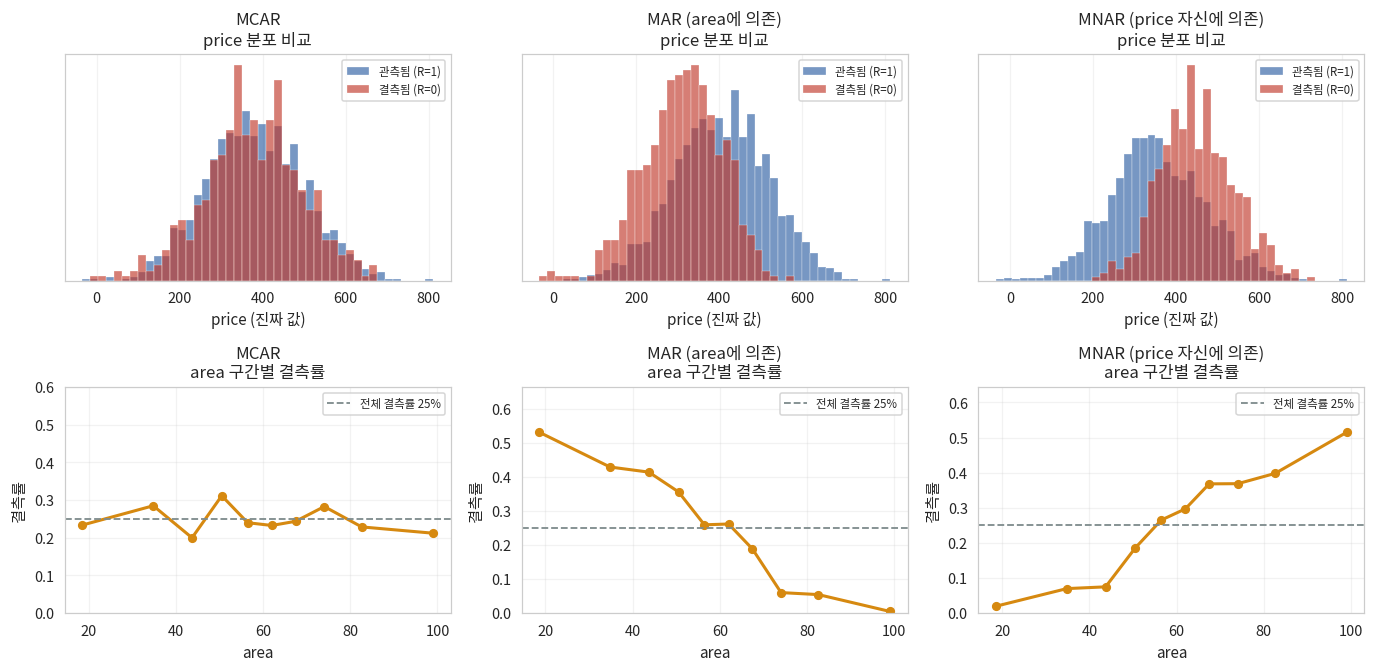

In [ ]:
# ============================================================
# 1-2. 세 메커니즘의 차이를 그림으로 보기
# ============================================================
fig, axes = panel(2, 3, w=4.2, h=3.1)
cases = [("MCAR", m_mcar), ("MAR (area에 의존)", m_mar), ("MNAR (price 자신에 의존)", m_mnar)]

# 윗줄: price의 분포를 관측/결측 그룹으로 나눠 비교
for ax, (name, mask) in zip(axes[0], cases):
    bins = np.linspace(clean["price"].min(), clean["price"].max(), 45)
    ax.hist(clean.loc[~mask, "price"], bins=bins, alpha=0.65,
            color=C["blue"], label="관측됨 (R=1)", density=True, edgecolor="white", lw=.3)
    ax.hist(clean.loc[mask, "price"], bins=bins, alpha=0.65,
            color=C["red"], label="결측됨 (R=0)", density=True, edgecolor="white", lw=.3)
    ax.set_title(f"{name}\nprice 분포 비교")
    ax.set_xlabel("price (진짜 값)")
    ax.legend(fontsize=7.5)
    ax.set_yticks([])

# 아랫줄: area(관측 가능한 변수) 대비 결측 확률
for ax, (name, mask) in zip(axes[1], cases):
    q = pd.qcut(clean["area"], 10, labels=False)
    rate_by_bin = pd.Series(mask).groupby(q).mean()
    centers = clean.groupby(q)["area"].mean()
    ax.plot(centers, rate_by_bin, "o-", color=C["amber"], lw=2, ms=5)
    ax.axhline(RATE, color=C["gray"], ls="--", lw=1.2, label=f"전체 결측률 {RATE:.0%}")
    ax.set_ylim(0, max(0.6, rate_by_bin.max() * 1.25))
    ax.set_title(f"{name}\narea 구간별 결측률")
    ax.set_xlabel("area")
    ax.set_ylabel("결측률")
    ax.legend(fontsize=7.5)

fig.tight_layout()
plt.show()

## 그림에서 무엇을 봐야 하는가

윗줄 세 개는 우리가 현실에서 절대 볼 수 없는 그림입니다. 결측된 값의 진짜 분포를 그렸으니까요.
시뮬레이션이라서 가능한 사치입니다.

MCAR에서는 파란색과 빨간색이 완전히 겹칩니다. 어느 값이 빠졌는지가 무작위니 당연합니다.
MAR로 가면 두 분포가 어긋나기 시작합니다. `area`가 작은 집이 많이 빠졌는데
면적이 작으면 가격도 낮으니, 결측 그룹의 가격이 낮은 쪽으로 치우칩니다.
MNAR에서는 어긋남이 가장 심합니다. 빨간색이 오른쪽 꼬리에 몰려 있죠. 비싼 집만 빠졌으니까요.

아랫줄은 현실에서도 그릴 수 있는 그림입니다. `area`는 관측되니까 구간을 나눠서 결측률을 볼 수 있습니다.
MCAR은 어느 구간에서나 25% 근처에서 평평합니다. 평평하다는 것 자체가 MCAR의 지문입니다.
MAR은 면적이 작은 쪽에서 53%, 큰 쪽에서 1%로 가파르게 우하향합니다.
MNAR은 반대로 우상향하는데, `price`가 클수록 빠지게 했고 `price`와 `area`가 강하게 붙어 있으니
면적이 클수록 결측률이 높아 보이는 것입니다.

## 여기서 놓치면 안 되는 것

아랫줄 그림에서 MAR과 MNAR은 둘 다 기울어진 곡선으로 나타납니다.
지금은 기울기 방향이 반대라 달라 보이지만, 그건 제가 두 메커니즘을 반대 방향으로 설정했기 때문입니다.
MNAR을 "싼 집이 가격을 감춘다"로 바꾸면 두 곡선이 같은 방향으로 기울어지고,
그러면 그림만으로는 전혀 구분할 수 없게 됩니다.

즉 아랫줄이 알려주는 것은 결측률이 관측된 변수와 관계가 있다는 사실까지입니다.
그 관계가 `area` 때문인지 `price` 자신 때문인지는 말해주지 않습니다.
구분하려면 윗줄이 필요한데 윗줄은 현실에서 그릴 수 없죠.

이것이 강의에서 말한 "MAR은 검정하는 것이 아니라 논증하는 것"의 실체입니다.
데이터만으로는 판별이 불가능하고, 결측을 설명하는 변수를 우리가 전부 가지고 있는가라는
도메인 판단이 반드시 들어가야 합니다.

셀 출력의 세 줄 숫자도 같이 보세요. MCAR에서는 관측된 price의 평균이 전체 평균과 거의 같고,
MAR에서는 위로, MNAR에서는 한참 위로 치우칩니다.
완전제거가 언제 안전하고 언제 위험한지가 그 세 줄에 전부 들어 있습니다.

---

## 1-2. 처리하기 전에 봐야 할 세 장의 그림

실무 데이터를 받으면 대치 방법을 고르기 전에 확인할 것이 세 가지 있습니다.
어느 변수에 얼마나 빠져 있는지, 어디에 빠져 있는지, 그리고 같이 빠지는지입니다.

세 번째를 자주 빠뜨리는데 이게 은근히 중요합니다.
여러 변수가 항상 같이 빠진다면 특정 수집 경로가 통째로 실패했다는 뜻이거든요.
설문에서 2페이지를 안 넘긴 응답자는 2페이지 문항이 전부 비어 있습니다.
이런 경우에는 결측 패턴 자체가 하나의 그룹 변수가 됩니다.

아래에서는 현실에 가깝게, 여러 변수에 서로 다른 메커니즘으로 결측을 주입합니다.
`area`는 MCAR, `age`는 `dist`에 의존하는 MAR, `floor`는 MCAR,
그리고 `dist`와 `rooms`는 같은 수집 경로가 실패해 동시에 빠지도록 만들었습니다.

In [ ]:
# ============================================================
# 1-3. 현실적인 결측 패턴 주입 (여러 변수 · 여러 메커니즘)
# ============================================================
def build_messy(df, seed=7):
    r = np.random.default_rng(seed)
    out = df.copy()
    n = len(out)

    # (1) area : MCAR 8%
    out.loc[r.random(n) < 0.08, "area"] = np.nan

    # (2) age : MAR — 역에서 멀수록(dist 큼) 연식 기록이 잘 누락됨
    p = sigmoid(1.8 * stats.zscore(df["dist"].to_numpy()))
    p = p * (0.18 / p.mean())
    out.loc[r.random(n) < np.clip(p, 0, 1), "age"] = np.nan

    # (3) floor : MCAR 12% — 다른 변수와 상관이 거의 없는 변수
    out.loc[r.random(n) < 0.12, "floor"] = np.nan

    # (4) dist, rooms : 같은 수집 경로 실패로 '동시에' 빠짐 (블록 결측)
    block = r.random(n) < 0.07
    out.loc[block, ["dist", "rooms"]] = np.nan

    return out


messy = build_messy(clean)

miss_rate = messy.isna().mean().sort_values(ascending=False)
show_table(miss_rate.rename("결측률").reset_index().rename(columns={"index": "변수"}),
           "변수별 결측률", "{:.3f}")
print(f"결측이 하나라도 있는 행: {messy.isna().any(axis=1).sum()} / {len(messy)} "
      f"({messy.isna().any(axis=1).mean():.1%})")

변수별 결측률
----------------------------------------
   변수   결측률
  age 0.176
floor 0.130
 area 0.077
rooms 0.066
 dist 0.066
price 0.000

결측이 하나라도 있는 행: 761 / 2000 (38.0%)


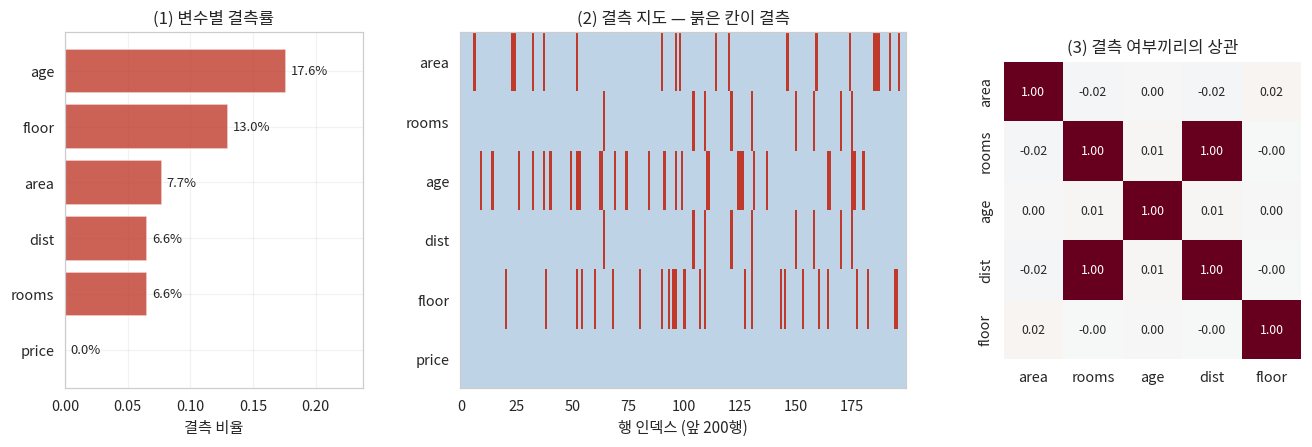

가장 흔한 결측 패턴 상위 8개 (1=결측)
----------------------------------------
패턴(area,rooms,age,dist,floor,price)  행 수    비율
                             000000 1239 0.620
                             001000  262 0.131
                             000010  182 0.091
                             100000  104 0.052
                             010100   88 0.044
                             001010   39 0.019
                             101000   21 0.011
                             011100   21 0.011



In [ ]:
# ============================================================
# 1-4. 결측 진단 3종 세트
# ============================================================
fig = plt.figure(figsize=(14.5, 4.2))
gs = fig.add_gridspec(1, 3, width_ratios=[1.0, 1.5, 1.0], wspace=0.28)

# (1) 결측률 막대
ax1 = fig.add_subplot(gs[0])
mr = messy.isna().mean().sort_values()
ax1.barh(mr.index, mr.values, color=C["red"], alpha=0.8)
for i, v in enumerate(mr.values):
    ax1.text(v + 0.004, i, f"{v:.1%}", va="center", fontsize=8.5)
ax1.set_xlim(0, mr.max() * 1.35)
ax1.set_title("(1) 변수별 결측률")
ax1.set_xlabel("결측 비율")

# (2) 결측 지도 — 행 200개만 잘라서
ax2 = fig.add_subplot(gs[1])
sub = messy.isna().iloc[:200]
ax2.imshow(sub.T.to_numpy(), aspect="auto", cmap=mpl.colors.ListedColormap([C["light"], C["red"]]),
           interpolation="nearest")
ax2.set_yticks(range(sub.shape[1]), sub.columns)
ax2.set_xlabel("행 인덱스 (앞 200행)")
ax2.set_title("(2) 결측 지도 — 붉은 칸이 결측")
ax2.grid(False)

# (3) 결측 공발생 상관
ax3 = fig.add_subplot(gs[2])
na_flags = messy.isna().astype(int)
na_flags = na_flags.loc[:, na_flags.sum() > 0]
sns.heatmap(na_flags.corr(), annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            vmin=-1, vmax=1, square=True, cbar=False, ax=ax3,
            annot_kws={"size": 8})
ax3.set_title("(3) 결측 여부끼리의 상관")

plt.show()

# 결측 패턴 빈도표
pattern = (messy.isna().astype(int)
           .astype(str).agg("".join, axis=1)
           .value_counts().head(8))
pat_df = pd.DataFrame({"패턴(area,rooms,age,dist,floor,price)": pattern.index,
                       "행 수": pattern.values,
                       "비율": (pattern.values / len(messy))})
show_table(pat_df, "가장 흔한 결측 패턴 상위 8개 (1=결측)", "{:.3f}")

## 세 장에서 읽어낸 것

결측률 막대를 보면 `age`가 18%로 가장 높고 `price`에는 결측이 없습니다.
타깃에 결측이 없다는 건 다행스러운 일입니다.
강의에서 말했듯 타깃 결측은 예측변수 결측보다 훨씬 다루기 까다롭거든요.

결측 지도에서는 붉은 칸이 흩어져 있는 변수와 세로로 나란히 줄이 서는 변수가 구분됩니다.
`area`와 `floor`는 흩어져 있고, `rooms`와 `dist`는 나란히 섭니다.
나란히 선다는 건 같은 행에서 동시에 빠졌다는 뜻이죠.

세 번째 그림에서 확인 사살이 됩니다. `rooms`와 `dist`의 결측 상관이 1.00입니다. 항상 같이 빠집니다.

이 발견이 전략을 바꿉니다. `rooms`가 빠진 행은 `dist`도 없으니,
`dist`로 `rooms`를 채우는 전략을 이 행들에는 쓸 수 없습니다.
KNN이나 MICE가 다른 변수를 참조하려는데 참조할 그 변수도 비어 있는 상황인 거죠.
블록 결측이 있으면 다변량 대치의 이점이 그만큼 줄어듭니다.
그림을 그리지 않았다면 모르고 지나갔을 사실입니다.

패턴 빈도표에서는 `000000`, 즉 완전한 행이 가장 많고 그다음이 한 변수만 빠진 패턴들입니다.
중간에 `011010` 같은 게 보이면 그게 블록 결측입니다.

---

## 1-3. 삭제의 대가

가장 쉬운 처리는 삭제입니다. 편향만 놓고 보면 MCAR에서는 정당합니다.
남은 데이터가 여전히 무작위 표본이니까요. 문제는 얼마나 남느냐입니다.

변수 $p$ 개가 각각 독립적으로 결측률 $r$ 을 가진다면 한 행이 완전할 확률은 $(1-r)^p$ 입니다.
지수함수라서, 개별 결측률이 작아도 변수가 많으면 데이터가 증발합니다.
그림으로 확인하고 우리 데이터에서 실제로 얼마나 잃는지 보겠습니다.

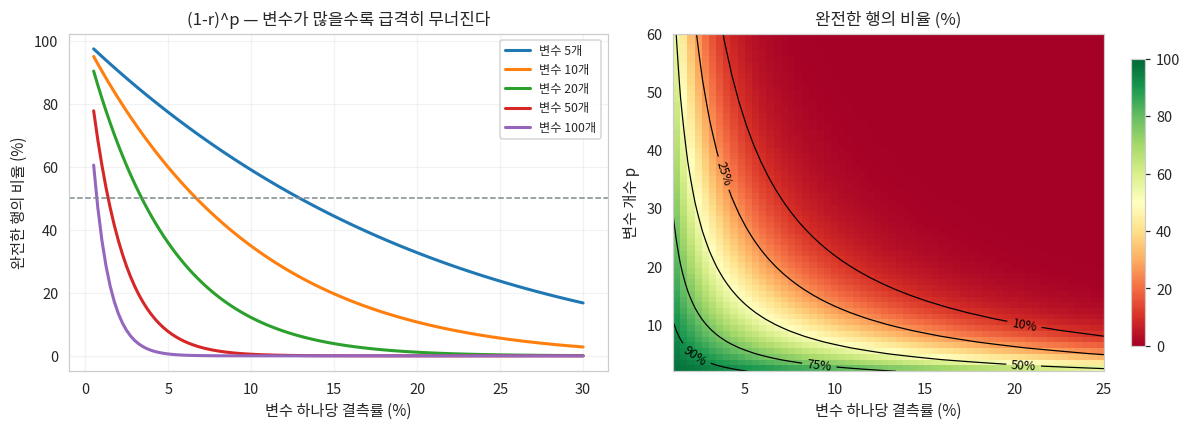

전체 2000행 중 완전한 행 1239행 (62.0%)
변수별 최대 결측률은 17.6%인데, 행 기준으로는 38.0%를 잃었습니다.

삭제 전후 평균 비교 (MAR 메커니즘이 걸린 age에 주목):
   변수  원본 전체  완전제거 후  차이(%)
 area  58.87   59.44   0.97
rooms   2.03    2.05   1.22
  age  12.22   11.63  -4.85
 dist 440.82  393.23 -10.80
floor   8.28    8.17  -1.39
price 380.44  385.12   1.23



In [ ]:
# ============================================================
# 1-5. 완전제거(listwise deletion) 생존율
# ============================================================
fig, axes = panel(1, 2, w=5.6, h=4.0)

# (좌) 이론 곡선
ps = np.array([5, 10, 20, 50, 100])
rs = np.linspace(0.005, 0.30, 120)
for p in ps:
    axes[0].plot(rs * 100, (1 - rs) ** p * 100, lw=2, label=f"변수 {p}개")
axes[0].axhline(50, color=C["gray"], ls="--", lw=1)
axes[0].set_xlabel("변수 하나당 결측률 (%)")
axes[0].set_ylabel("완전한 행의 비율 (%)")
axes[0].set_title("(1-r)^p — 변수가 많을수록 급격히 무너진다")
axes[0].legend(fontsize=8)

# (우) 히트맵
P = np.arange(2, 61)
R = np.linspace(0.01, 0.25, 60)
grid = (1 - R[None, :]) ** P[:, None] * 100
im = axes[1].imshow(grid, aspect="auto", origin="lower", cmap="RdYlGn",
                    vmin=0, vmax=100,
                    extent=[R[0] * 100, R[-1] * 100, P[0], P[-1]])
cs = axes[1].contour(R * 100, P, grid, levels=[10, 25, 50, 75, 90],
                     colors="k", linewidths=0.8)
axes[1].clabel(cs, fmt="%d%%", fontsize=8)
axes[1].set_xlabel("변수 하나당 결측률 (%)")
axes[1].set_ylabel("변수 개수 p")
axes[1].set_title("완전한 행의 비율 (%)")
axes[1].grid(False)
plt.colorbar(im, ax=axes[1], shrink=.85)

fig.tight_layout()
plt.show()

# 우리 데이터에서의 실제 손실
n_all = len(messy)
n_cc = len(messy.dropna())
print(f"전체 {n_all}행 중 완전한 행 {n_cc}행 ({n_cc/n_all:.1%})")
print(f"변수별 최대 결측률은 {messy.isna().mean().max():.1%}인데, 행 기준으로는 {1-n_cc/n_all:.1%}를 잃었습니다.")
print()
print("삭제 전후 평균 비교 (MAR 메커니즘이 걸린 age에 주목):")
cmp = pd.DataFrame({
    "원본 전체": clean[FEATURES + [TARGET]].mean(),
    "완전제거 후": messy.dropna()[FEATURES + [TARGET]].mean(),
})
cmp["차이(%)"] = (cmp["완전제거 후"] / cmp["원본 전체"] - 1) * 100
show_table(cmp.reset_index().rename(columns={"index": "변수"}), None, "{:.2f}")

## 얼마나 잃었는가

변수별 결측률은 최대 18%인데 행 기준으로는 40% 가까이를 잃었습니다. 지수 붕괴의 실물입니다.

그런데 손실이 전부가 아닙니다. 평균 비교표에서 `age`와 `dist`를 보세요.
`age`에 "역에서 멀수록 기록이 누락된다"는 MAR 메커니즘을 걸어뒀기 때문에,
완전제거를 하고 나면 역에서 가까운 집이 과대 대표됩니다. `dist`의 평균이 원본보다 낮게 나올 겁니다.

데이터를 잃었고, 남은 데이터마저 편향되었습니다. 둘 다 잃은 셈이죠.

---

## 1-4. 평균 대체가 분산을 얼마나 줄이는가

강의에서 유도했던 식을 다시 씁니다. MCAR 상황에서 $n$ 개 중 $m$ 개가 관측되었을 때
관측 평균으로 나머지를 채우면 이렇게 됩니다.

$$
S^2_{\text{imp}} = \frac{1}{n-1}\sum_{i=1}^{n}(x_i - \bar x_{obs})^2
= \frac{1}{n-1}\sum_{i \in obs}(x_i - \bar x_{obs})^2
= \frac{m-1}{n-1}\,S^2_{obs}
$$

채워 넣은 항들은 편차가 정확히 0이라 합에서 통째로 사라집니다.
그래서 분산이 관측 비율만큼 줄어듭니다.

상관계수도 따라서 감쇠합니다. 채운 점들이 $x = \bar x$ 라는 수직선 위에 놓이는 바람에
공분산에 전혀 기여하지 못하기 때문입니다.

식이 맞는지 실험으로 확인하겠습니다. 결측률을 0에서 60%까지 바꿔가며 측정합니다.

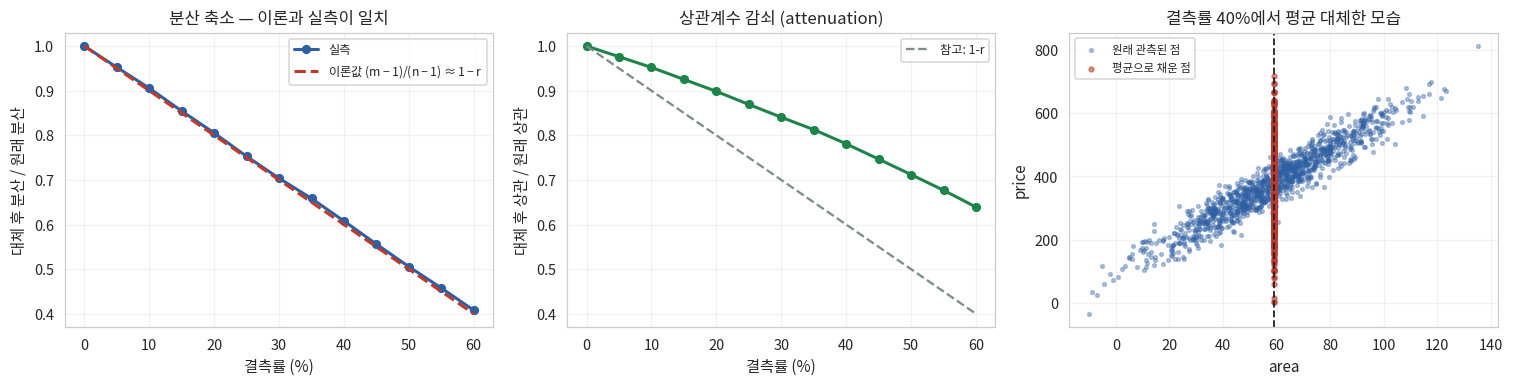

결측률별 축소 정도
----------------------------------------
 rate  분산비(실측)  분산비(이론 1-r)  상관비(실측)
0.000    1.000        1.000    1.000
0.100    0.906        0.900    0.952
0.200    0.805        0.800    0.898
0.300    0.704        0.700    0.840
0.400    0.608        0.600    0.781
0.500    0.506        0.500    0.712
0.600    0.408        0.400    0.639



In [ ]:
# ============================================================
# 1-6. 평균 대체가 분산과 상관을 얼마나 줄이는가
# ============================================================
rates = np.arange(0.0, 0.65, 0.05)
rows = []
REPS = 30

for rate in rates:
    v_ratio, c_ratio = [], []
    for rep in range(REPS):
        r = np.random.default_rng(1000 + rep)
        x = clean["area"].to_numpy().copy()
        y = clean["price"].to_numpy()
        mask = r.random(len(x)) < rate
        x_na = x.copy(); x_na[mask] = np.nan
        if np.all(np.isnan(x_na)):
            continue
        x_imp = np.where(mask, np.nanmean(x_na), x)
        v_ratio.append(np.var(x_imp, ddof=1) / np.var(x, ddof=1))
        c_ratio.append(np.corrcoef(x_imp, y)[0, 1] / np.corrcoef(x, y)[0, 1])
    rows.append({"rate": rate,
                 "분산비(실측)": np.mean(v_ratio),
                 "분산비(이론 1-r)": 1 - rate,
                 "상관비(실측)": np.mean(c_ratio)})

res_shrink = pd.DataFrame(rows)

fig, axes = panel(1, 3, w=4.6, h=3.6)

axes[0].plot(res_shrink["rate"] * 100, res_shrink["분산비(실측)"], "o-",
             color=C["blue"], lw=2, ms=5, label="실측")
axes[0].plot(res_shrink["rate"] * 100, res_shrink["분산비(이론 1-r)"], "--",
             color=C["red"], lw=2, label="이론값 $(m-1)/(n-1)\\approx 1-r$")
axes[0].set_xlabel("결측률 (%)"); axes[0].set_ylabel("대체 후 분산 / 원래 분산")
axes[0].set_title("분산 축소 — 이론과 실측이 일치"); axes[0].legend(fontsize=8)

axes[1].plot(res_shrink["rate"] * 100, res_shrink["상관비(실측)"], "o-",
             color=C["green"], lw=2, ms=5)
axes[1].plot(res_shrink["rate"] * 100, 1 - res_shrink["rate"], "--",
             color=C["gray"], lw=1.5, label="참고: 1-r")
axes[1].set_xlabel("결측률 (%)"); axes[1].set_ylabel("대체 후 상관 / 원래 상관")
axes[1].set_title("상관계수 감쇠 (attenuation)"); axes[1].legend(fontsize=8)

# 산점도로 직접 보기 (결측률 40%)
r = np.random.default_rng(0)
mask = r.random(len(clean)) < 0.40
x = clean["area"].to_numpy(); y = clean["price"].to_numpy()
x_imp = np.where(mask, np.nanmean(np.where(mask, np.nan, x)), x)
axes[2].scatter(x[~mask], y[~mask], s=6, alpha=.35, color=C["blue"], label="원래 관측된 점")
axes[2].scatter(x_imp[mask], y[mask], s=10, alpha=.55, color=C["red"], label="평균으로 채운 점")
axes[2].axvline(np.nanmean(x[~mask]), color=C["dark"], ls="--", lw=1.2)
axes[2].set_xlabel("area"); axes[2].set_ylabel("price")
axes[2].set_title("결측률 40%에서 평균 대체한 모습"); axes[2].legend(fontsize=7.5)

fig.tight_layout()
plt.show()

show_table(res_shrink.iloc[::2], "결측률별 축소 정도", "{:.3f}")

## 이론과 실측이 겹칩니다

왼쪽 그림에서 실측값과 이론값이 사실상 포개져 있습니다. 칠판에서 유도한 식이 그대로 확인된 거죠.
결측률 30%면 분산이 70%로, 50%면 50%로 줄어듭니다.

가운데 그림을 보면 상관계수도 거의 같은 비율로 감쇠합니다.
이건 회귀계수가 실제보다 작게 나온다는 뜻입니다. 계수가 0 쪽으로 끌려가니
유의한 관계를 유의하지 않다고 보고하게 됩니다.

오른쪽 산점도가 이 현상의 가장 직관적인 모습입니다.
빨간 점들이 세로줄 하나 위에 완벽하게 정렬돼 있습니다.
`area`의 변동은 통째로 사라졌는데 `price`의 변동은 그대로죠. 저 세로줄이 상관을 희석시킵니다.

## 왜 위험한가

평균 대체를 하고 나면 데이터프레임이 깨끗해집니다. 에러도 없고 모델도 잘 돌아갑니다.
아무것도 잘못된 것처럼 보이지 않는다는 점이 이 방법의 가장 위험한 부분입니다.

분산이 작아졌으니 표준오차가 작아지고, 신뢰구간이 좁아지고, p값이 작아집니다.
정보를 만들어낸 적이 없는데 통계는 정보가 늘었다고 착각합니다.
강의에서 말한 "과도한 확신"이 정확히 이것입니다.

예측만 할 거라면 어느 정도 감당할 만합니다.
하지만 계수를 해석하거나 신뢰구간을 보고할 계획이라면 평균 대체는 쓰면 안 됩니다.

---

## 1-5. 결정론적 대치와 확률적 대치

여기가 강의의 핵심이었으니 다시 정리하고 가겠습니다.

$$
\text{예측의 목표: } \hat y = \mathbb E[Y \mid X]
\qquad\qquad
\text{대치의 목표: } y^{imp} \sim P(Y \mid X)
$$

지난 시간에 제곱손실의 최적 예측이 조건부 평균이라는 것을 증명했습니다.
그런데 대치에서는 그 최적 예측을 쓰면 안 됩니다.
우리가 복원하려는 것은 "이 값에 대한 최선의 추측"이 아니라
"이 값이 관측되었다면 어땠을까"이기 때문입니다.
그 값은 회귀선 위에 있지 않고 회귀선 주변에 $\sigma$ 만큼 흩어져 있습니다.

절차는 세 단계입니다. 관측치만으로 모형을 적합해 $\hat\beta$ 와 $\hat\sigma^2$ 을 얻고,
결측치에 대해 $\hat y = x^\top\hat\beta$ 를 계산한 다음,
$y^{imp} = \hat y + \varepsilon^*$ 로 무작위성을 주입합니다. 여기서 $\varepsilon^*\sim\mathcal N(0,\hat\sigma^2)$ 이고요.

마지막 한 줄이 있고 없고의 차이를 보겠습니다.

관측치로 적합한 모형의 잔차 표준편차 sigma_hat = 25.85
데이터를 만들 때 쓴 진짜 sigma            = 26.00
→ 우리가 주입할 잡음의 크기는 '줄일 수 없는 오차'의 추정치입니다.



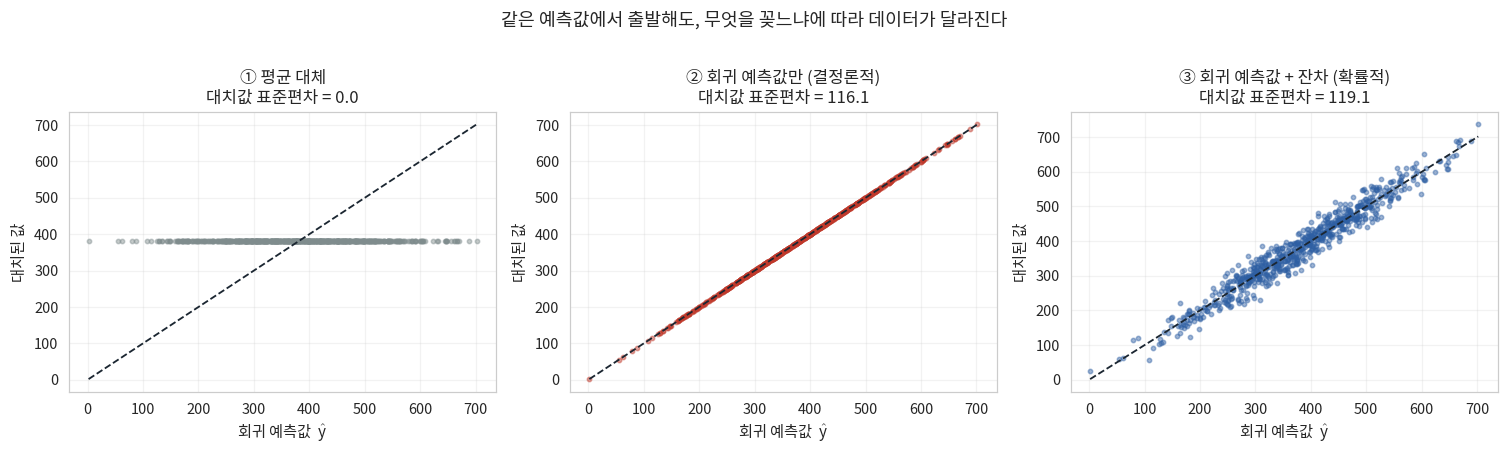

In [ ]:
# ============================================================
# 1-7. 결정론적 회귀 대치 vs 확률적 회귀 대치
# ============================================================
work = clean.copy()
r = np.random.default_rng(11)
mask_p = r.random(len(work)) < 0.35      # price의 35%를 MCAR로 제거
truth = work.loc[mask_p, "price"].to_numpy()   # 신의 시점: 진짜 값

obs = work.loc[~mask_p]
mis = work.loc[mask_p]

lr = LinearRegression().fit(obs[FEATURES], obs["price"])
y_hat = lr.predict(mis[FEATURES])

resid = obs["price"].to_numpy() - lr.predict(obs[FEATURES])
sigma_hat = np.sqrt(np.mean(resid ** 2))          # 줄일 수 없는 오차의 추정치

imp_det = y_hat                                    # 결정론적
imp_sto = y_hat + np.random.default_rng(12).normal(0, sigma_hat, len(y_hat))   # 확률적
imp_mean = np.full_like(y_hat, obs["price"].mean())  # 비교용: 평균 대체

print(f"관측치로 적합한 모형의 잔차 표준편차 sigma_hat = {sigma_hat:.2f}")
print(f"데이터를 만들 때 쓴 진짜 sigma            = {TRUE_SIGMA:.2f}")
print("→ 우리가 주입할 잡음의 크기는 '줄일 수 없는 오차'의 추정치입니다.\n")

fig, axes = panel(1, 3, w=4.6, h=4.0)

for ax, vals, name, col in [
    (axes[0], imp_mean, "① 평균 대체", C["gray"]),
    (axes[1], imp_det,  "② 회귀 예측값만 (결정론적)", C["red"]),
    (axes[2], imp_sto,  "③ 회귀 예측값 + 잔차 (확률적)", C["blue"]),
]:
    ax.scatter(y_hat, vals, s=8, alpha=.45, color=col)
    lo, hi = y_hat.min(), y_hat.max()
    ax.plot([lo, hi], [lo, hi], color=C["dark"], lw=1.2, ls="--")
    ax.set_xlabel("회귀 예측값  $\\hat{y}$")
    ax.set_ylabel("대치된 값")
    sd = np.std(vals, ddof=1)
    ax.set_title(f"{name}\n대치값 표준편차 = {sd:.1f}")

fig.suptitle("같은 예측값에서 출발해도, 무엇을 꽂느냐에 따라 데이터가 달라진다", y=1.02, fontsize=12)
fig.tight_layout()
plt.show()

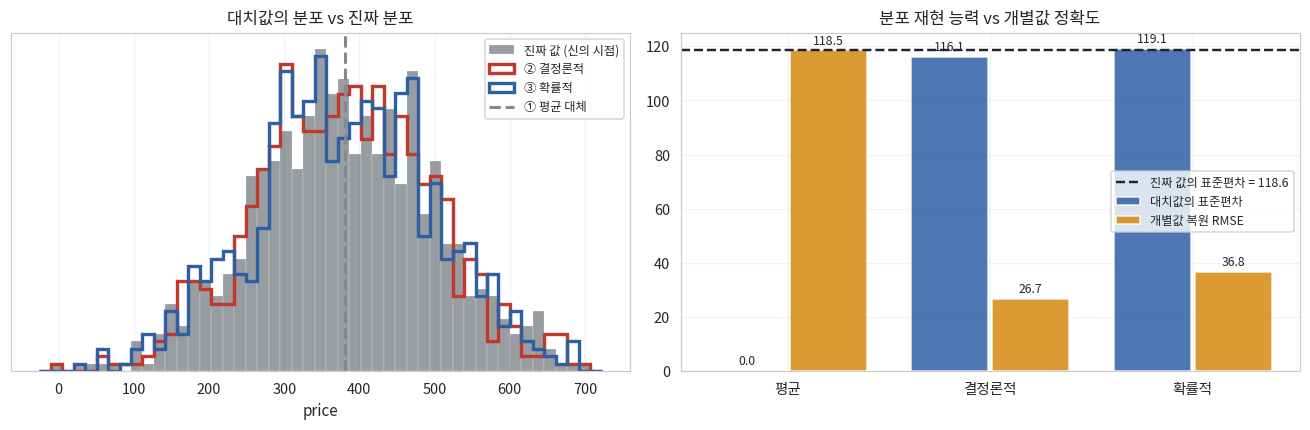

세 방식 비교
----------------------------------------
       방식     평균   표준편차  개별값 RMSE
  ① 평균 대체 380.94   0.00    118.52
② 결정론적 회귀 379.76 116.15     26.71
 ③ 확률적 회귀 380.35 119.13     36.79
     진짜 값 379.56 118.60      0.00



In [ ]:
# ============================================================
# 1-8. 세 방식의 분포와 복원 정확도 비교
# ============================================================
fig, axes = panel(1, 2, w=6.0, h=4.0)

bins = np.linspace(truth.min() - 30, truth.max() + 30, 50)
axes[0].hist(truth, bins=bins, alpha=.45, color=C["dark"], density=True,
             label="진짜 값 (신의 시점)", edgecolor="white", lw=.3)
axes[0].hist(imp_det, bins=bins, histtype="step", lw=2.2, color=C["red"],
             density=True, label="② 결정론적")
axes[0].hist(imp_sto, bins=bins, histtype="step", lw=2.2, color=C["blue"],
             density=True, label="③ 확률적")
axes[0].axvline(imp_mean[0], color=C["gray"], lw=2, ls="--", label="① 평균 대체")
axes[0].set_title("대치값의 분포 vs 진짜 분포")
axes[0].set_xlabel("price"); axes[0].set_yticks([])
axes[0].legend(fontsize=8)

summary = pd.DataFrame({
    "방식": ["① 평균 대체", "② 결정론적 회귀", "③ 확률적 회귀", "진짜 값"],
    "평균": [imp_mean.mean(), imp_det.mean(), imp_sto.mean(), truth.mean()],
    "표준편차": [imp_mean.std(ddof=1), imp_det.std(ddof=1), imp_sto.std(ddof=1), truth.std(ddof=1)],
    "개별값 RMSE": [np.sqrt(np.mean((imp_mean - truth) ** 2)),
                    np.sqrt(np.mean((imp_det - truth) ** 2)),
                    np.sqrt(np.mean((imp_sto - truth) ** 2)),
                    0.0],
})

x = np.arange(3)
axes[1].bar(x - 0.2, summary["표준편차"][:3], width=0.38,
            color=C["blue"], alpha=.85, label="대치값의 표준편차")
axes[1].bar(x + 0.2, summary["개별값 RMSE"][:3], width=0.38,
            color=C["amber"], alpha=.85, label="개별값 복원 RMSE")
axes[1].axhline(truth.std(ddof=1), color=C["dark"], ls="--", lw=1.6,
                label=f"진짜 값의 표준편차 = {truth.std(ddof=1):.1f}")
axes[1].set_xticks(x, ["평균", "결정론적", "확률적"])
axes[1].set_title("분포 재현 능력 vs 개별값 정확도")
axes[1].legend(fontsize=8)
annotate_bars(axes[1], "{:.1f}")

fig.tight_layout()
plt.show()

show_table(summary, "세 방식 비교", "{:.2f}")

## 두 지표가 정반대를 가리킵니다

오른쪽 막대그래프가 이 노트북에서 가장 중요한 그림입니다.
평균 대체는 대치값의 표준편차가 0이고 개별값 복원 RMSE도 가장 큽니다. 양쪽 다 꼴찌죠.
그런데 결정론적 회귀와 확률적 회귀를 비교하면 순위가 뒤집힙니다.

결정론적 대치가 개별값 RMSE에서 이깁니다. 당연한 결과입니다.
조건부 평균이 제곱손실의 최적해라는 걸 우리가 이미 증명했으니까요.

그런데 분포를 보면 집니다. 왼쪽 히스토그램에서 빨간 선이 진짜 분포보다 가운데로 뾰족하게 쏠려 있습니다.
파란 선은 검은 히스토그램과 폭이 비슷하고요.

## 왜 이런 일이 생기는가

분산 분해로 보면 명확합니다.

$$
\underbrace{\operatorname{Var}(Y)}_{\text{진짜 분산}} \;=\; \underbrace{\operatorname{Var}\big(\mathbb E[Y\mid X]\big)}_{\text{설명된 분산}} \;+\; \underbrace{\mathbb E\big[\operatorname{Var}(Y\mid X)\big]}_{=\;\sigma^2}
$$

결정론적 대치는 첫 번째 항만 재현하고 두 번째 항을 통째로 버립니다.
$\sigma^2$ 은 지난 시간에 배운 줄일 수 없는 오차입니다.
예측에서는 우리를 막아서던 벽이었는데, 대치에서는 그 벽을 일부러 다시 세워야 합니다.
잔차를 더하는 한 줄이 정확히 그 일을 합니다.

## 그래서 무엇을 써야 하는가

목적에 따라 다릅니다. 이 노트북에서 계속 반복될 답입니다.

순수하게 예측 성능만 중요하다면 결정론적 대치도 괜찮습니다. 개별값 정확도가 높으니까요.
반대로 분포나 분산, 상관, 표준오차, 신뢰구간이 결과물에 들어간다면 반드시 확률적 대치를 써야 합니다.
어느 쪽인지 애매하면 확률적 대치가 안전합니다. 잃는 것이 적고 얻는 것이 많거든요.

---

## 1-6. 대치 도구들을 전부 비교해 보기

이제 sklearn이 제공하는 도구들을 한자리에 놓고 비교합니다.
신의 시점이 있으니 정답과 대조할 수 있죠.

`SimpleImputer`는 평균이든 중앙값이든 단변량이고 불확실성이 없습니다.
`KNNImputer`는 이웃들의 평균을 쓰니 다변량이지만, 평균을 내는 순간 불확실성이 사라집니다.
다만 `k=1`로 두면 이웃의 실제 값을 그대로 가져오므로 변동성이 따라옵니다.
`IterativeImputer`는 MICE 방식으로 반복 회귀를 돌리는데,
`sample_posterior=True`를 주면 사후분포에서 뽑아 확률적 대치가 됩니다.

평가 지표는 두 개를 씁니다. 하나만 보면 앞 절에서 확인한 함정에 그대로 빠집니다.
복원 RMSE로 개별값을 얼마나 맞혔는지 보고,
분산 보존율로 데이터의 변동성을 얼마나 지켰는지 봅니다. 후자는 1에 가까울수록 좋습니다.

대치 방법별 복원 품질 (결측된 칸만 평가)
----------------------------------------
                      대치 방법  복원 RMSE(표준화)  분산 보존율
        SimpleImputer(mean)         1.004   0.000
      SimpleImputer(median)         1.014   0.000
            KNNImputer(k=5)         0.772   0.483
            KNNImputer(k=1)         1.001   1.027
           IterativeImputer         0.640   0.565
IterativeImputer(posterior)         0.923   1.089



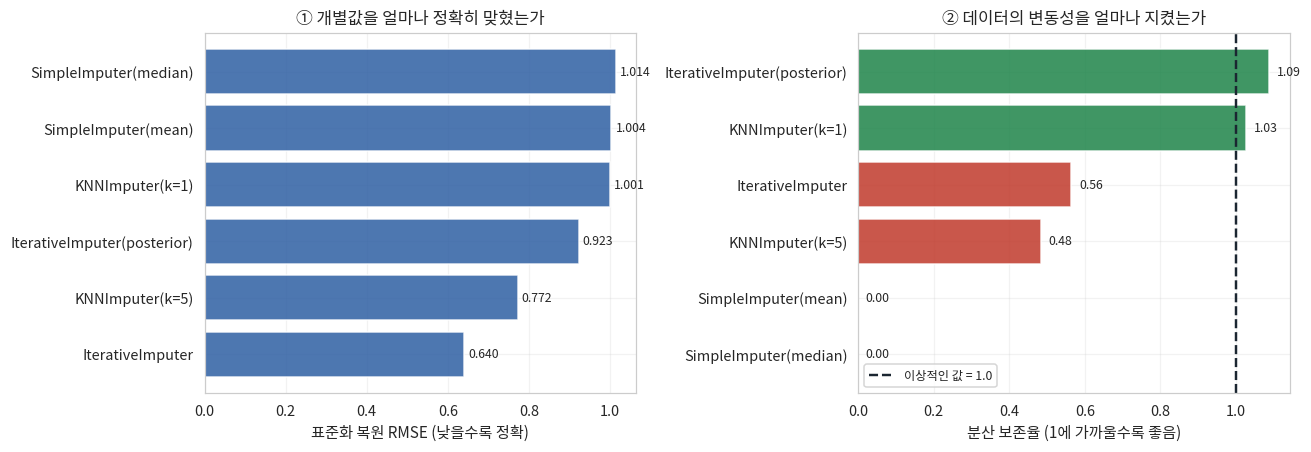

In [ ]:
# ============================================================
# 1-9. 대치기 6종 비교
# ============================================================
COLS = FEATURES + [TARGET]

def evaluate_imputers(df_clean, df_na, cols=COLS):
    na_mask = df_na[cols].isna().to_numpy()
    truth_mat = df_clean[cols].to_numpy()

    imputers = {
        "SimpleImputer(mean)":   SimpleImputer(strategy="mean"),
        "SimpleImputer(median)": SimpleImputer(strategy="median"),
        "KNNImputer(k=5)":       KNNImputer(n_neighbors=5),
        "KNNImputer(k=1)":       KNNImputer(n_neighbors=1),
        "IterativeImputer":      IterativeImputer(estimator=BayesianRidge(),
                                                  max_iter=15, random_state=0,
                                                  sample_posterior=False),
        "IterativeImputer(posterior)": IterativeImputer(estimator=BayesianRidge(),
                                                        max_iter=15, random_state=0,
                                                        sample_posterior=True),
    }

    rows, filled = [], {}
    for name, imp in imputers.items():
        # KNN은 거리 기반이라 스케일링이 필요 -> 파이프라인처럼 직접 처리
        if name.startswith("KNN"):
            mu = np.nanmean(df_na[cols].to_numpy(), axis=0)
            sd = np.nanstd(df_na[cols].to_numpy(), axis=0)
            Z = (df_na[cols].to_numpy() - mu) / sd
            Zf = imp.fit_transform(Z)
            X_imp = Zf * sd + mu
        else:
            X_imp = imp.fit_transform(df_na[cols])

        filled[name] = X_imp
        rec = {"대치 방법": name}
        rmse_all, var_all = [], []
        for j, c in enumerate(cols):
            m = na_mask[:, j]
            if m.sum() == 0:
                continue
            rmse = np.sqrt(np.mean((X_imp[m, j] - truth_mat[m, j]) ** 2))
            vr = np.var(X_imp[m, j], ddof=1) / np.var(truth_mat[m, j], ddof=1)
            rmse_all.append(rmse / np.std(truth_mat[:, j]))   # 표준화 RMSE
            var_all.append(vr)
        rec["복원 RMSE(표준화)"] = np.mean(rmse_all)
        rec["분산 보존율"] = np.mean(var_all)
        rows.append(rec)

    return pd.DataFrame(rows), filled


imp_res, filled_sets = evaluate_imputers(clean, messy)
show_table(imp_res, "대치 방법별 복원 품질 (결측된 칸만 평가)", "{:.3f}")

fig, axes = panel(1, 2, w=6.0, h=4.2)
order = imp_res.sort_values("복원 RMSE(표준화)")
axes[0].barh(order["대치 방법"], order["복원 RMSE(표준화)"], color=C["blue"], alpha=.85)
axes[0].set_xlabel("표준화 복원 RMSE (낮을수록 정확)")
axes[0].set_title("① 개별값을 얼마나 정확히 맞혔는가")
for i, v in enumerate(order["복원 RMSE(표준화)"]):
    axes[0].text(v + 0.01, i, f"{v:.3f}", va="center", fontsize=8)

o2 = imp_res.sort_values("분산 보존율")
cols_bar = [C["red"] if abs(v - 1) > 0.25 else C["green"] for v in o2["분산 보존율"]]
axes[1].barh(o2["대치 방법"], o2["분산 보존율"], color=cols_bar, alpha=.85)
axes[1].axvline(1.0, color=C["dark"], ls="--", lw=1.6, label="이상적인 값 = 1.0")
axes[1].set_xlabel("분산 보존율 (1에 가까울수록 좋음)")
axes[1].set_title("② 데이터의 변동성을 얼마나 지켰는가")
axes[1].legend(fontsize=8)
for i, v in enumerate(o2["분산 보존율"]):
    axes[1].text(v + 0.02, i, f"{v:.2f}", va="center", fontsize=8)

fig.tight_layout()
plt.show()

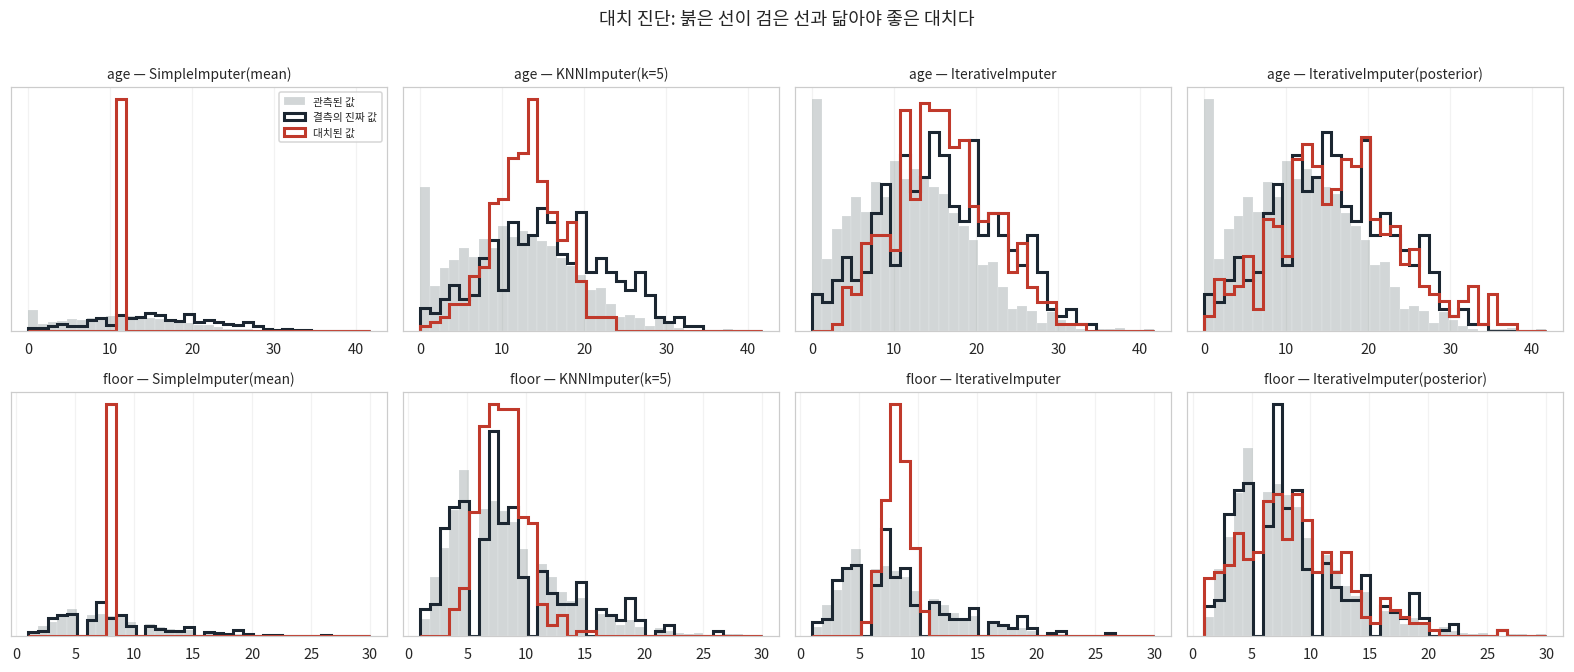

In [ ]:
# ============================================================
# 1-10. 대치 진단 — 관측 분포와 대치 분포를 겹쳐 본다
# ============================================================
diag_targets = ["age", "floor"]     # 상관이 강한 변수 vs 거의 무관한 변수
show_methods = ["SimpleImputer(mean)", "KNNImputer(k=5)",
                "IterativeImputer", "IterativeImputer(posterior)"]

fig, axes = panel(len(diag_targets), len(show_methods), w=3.6, h=3.0)
for i, col in enumerate(diag_targets):
    j_col = COLS.index(col)
    m = messy[col].isna().to_numpy()
    truth_v = clean.loc[m, col].to_numpy()
    obs_v = messy.loc[~m, col].to_numpy()
    for j, meth in enumerate(show_methods):
        ax = axes[i, j]
        imp_v = filled_sets[meth][m, j_col]
        bins = np.linspace(clean[col].min(), clean[col].max(), 36)
        ax.hist(obs_v, bins=bins, density=True, alpha=.35, color=C["gray"],
                label="관측된 값", edgecolor="white", lw=.3)
        ax.hist(truth_v, bins=bins, density=True, histtype="step", lw=2,
                color=C["dark"], label="결측의 진짜 값")
        ax.hist(imp_v, bins=bins, density=True, histtype="step", lw=2,
                color=C["red"], label="대치된 값")
        ax.set_yticks([])
        ax.set_title(f"{col} — {meth}", fontsize=9)
        if i == 0 and j == 0:
            ax.legend(fontsize=7)

fig.suptitle("대치 진단: 붉은 선이 검은 선과 닮아야 좋은 대치다", y=1.01, fontsize=12)
fig.tight_layout()
plt.show()

## 결과에서 읽어야 할 것

먼저 두 지표의 승자가 다릅니다.
무작위성이 없는 `IterativeImputer`가 복원 RMSE에서 1등입니다.
다변량 회귀로 조건부 평균을 잘 맞혔으니 당연하죠. 그런데 분산 보존율은 1에서 한참 떨어져 있습니다.
반대로 `IterativeImputer(posterior)`는 RMSE가 조금 나쁜 대신 분산 보존율이 1에 훨씬 가깝습니다.
`KNNImputer(k=1)`도 같은 성격인데, 이웃의 실제 값을 그대로 가져오니 원래 변동성이 딸려 오기 때문입니다.
앞 절의 트레이드오프가 여기서 그대로 반복됩니다.

평균 대체의 분산 보존율은 0에 가깝습니다. 결측 칸에 전부 같은 값을 넣었으니 분산이 있을 리가 없죠.
그래프에서 빨간 막대로 표시됩니다.

## 변수에 따라 이득이 전혀 다릅니다

진단 그림의 두 줄을 비교해 보세요.

윗줄 `age`는 `dist`와 상관이 있는 변수입니다. KNN과 Iterative가 검은 선에 꽤 가깝게 붙습니다.
아랫줄 `floor`는 다른 어떤 변수와도 무관하게 만든 변수인데,
어떤 고급 방법을 써도 평균 대체와 별 차이가 없습니다.

참조할 정보가 없으면 다변량 대치도 소용없습니다. 알고리즘이 없는 정보를 만들어낼 수는 없으니까요.
결측률보다 예측 가능성이 중요하다는 말이 그림으로 확인된 셈입니다.

## 대치 진단 그림은 습관으로 만드세요

이 그림 한 장이면 대치 품질을 한눈에 판정할 수 있습니다.
붉은 선이 가운데로 뾰족하게 몰려 있으면 결정론적 대치의 흔적이고 분산이 죽었다는 신호입니다.
붉은 선이 관측 분포인 회색과 똑같이 생겼다면 다른 변수 정보를 안 썼다는 뜻이고요.
붉은 선이 검은 선과 닮았다면 좋은 대치입니다.

현실에서는 검은 선, 즉 결측의 진짜 값을 볼 수 없으니 회색과 붉은색을 비교하게 됩니다.
MCAR이라면 둘이 비슷해야 하고, MAR이라면 오히려 체계적으로 달라야 정상입니다.

---

## 1-7. 빈칸 자체가 정보일 때

MNAR 상황에서는 "빠졌다"는 사실 자체가 신호입니다. 강의의 마약 사용 설문 예시가 그랬죠.

이럴 때 쓰는 것이 결측 지시변수입니다. 대치는 하되 결측이었다는 사실을 별도 열로 남깁니다.
모형으로 쓰면 $Y^* \sim X + R + X\cdot R$ 이 되고,
상호작용항 $X \cdot R$ 이 있으면 결측 집단과 비결측 집단에 서로 다른 기울기를 줄 수 있습니다.

아래에서는 `area`에 MNAR 결측을 주입합니다.
넓은 집일수록 면적을 안 적는 구조로 만들고, 지시변수를 넣었을 때와 안 넣었을 때의 예측 성능을 비교합니다.

area 결측률 30.0% | 결측된 집의 진짜 면적 평균 74.0 | 관측된 집 52.4
MNAR 상황에서 결측 지시변수의 효과 (test set)
----------------------------------------
             전략   RMSE    MAE    R2
         평균 대체만 51.111 40.005 0.812
평균 대체 + 결측 지시변수 42.132 31.783 0.872
       MICE 대치만 41.261 30.363 0.878
 MICE + 결측 지시변수 38.896 28.432 0.891



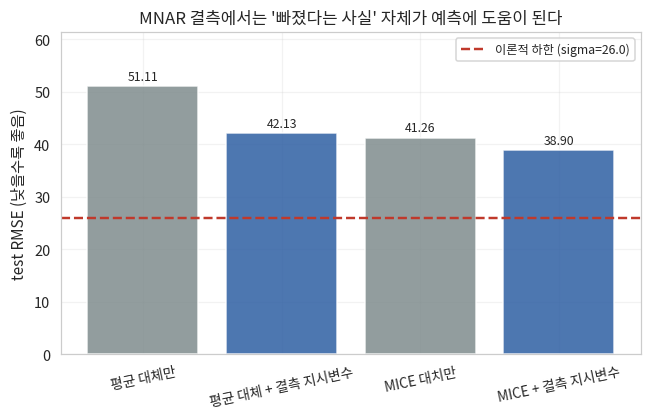

In [ ]:
# ============================================================
# 1-11. MissingIndicator의 효과 (MNAR 상황)
# ============================================================
r = np.random.default_rng(21)
mnar_df = clean.copy()
p = sigmoid(2.4 * stats.zscore(clean["area"].to_numpy()))   # 넓은 집일수록 면적 미기재
p = p * (0.30 / p.mean())
mnar_mask = r.random(len(clean)) < np.clip(p, 0, 1)
mnar_df.loc[mnar_mask, "area"] = np.nan
print(f"area 결측률 {mnar_mask.mean():.1%} "
      f"| 결측된 집의 진짜 면적 평균 {clean.loc[mnar_mask,'area'].mean():.1f} "
      f"| 관측된 집 {clean.loc[~mnar_mask,'area'].mean():.1f}")

X = mnar_df[FEATURES]; y = mnar_df[TARGET]
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.3, random_state=0)

variants = {
    "평균 대체만": Pipeline([
        ("imp", SimpleImputer(strategy="mean")),
        ("sc", StandardScaler()),
        ("m", Ridge(alpha=1.0))]),
    "평균 대체 + 결측 지시변수": Pipeline([
        ("imp", SimpleImputer(strategy="mean", add_indicator=True)),
        ("sc", StandardScaler()),
        ("m", Ridge(alpha=1.0))]),
    "MICE 대치만": Pipeline([
        ("imp", IterativeImputer(estimator=BayesianRidge(), max_iter=15, random_state=0)),
        ("sc", StandardScaler()),
        ("m", Ridge(alpha=1.0))]),
    "MICE + 결측 지시변수": Pipeline([
        ("imp", IterativeImputer(estimator=BayesianRidge(), max_iter=15,
                                 random_state=0, add_indicator=True)),
        ("sc", StandardScaler()),
        ("m", Ridge(alpha=1.0))]),
}

rows = []
for name, pipe in variants.items():
    pipe.fit(Xtr, ytr)
    rows.append(summarize(name, yte, pipe.predict(Xte)))
ind_res = pd.DataFrame(rows)
show_table(ind_res, "MNAR 상황에서 결측 지시변수의 효과 (test set)", "{:.3f}")

fig, ax = panel(1, 1, w=6.8, h=3.8)
xpos = np.arange(len(ind_res))
colors = [C["gray"], C["blue"], C["gray"], C["blue"]]
ax.bar(xpos, ind_res["RMSE"], color=colors, alpha=.85)
ax.set_xticks(xpos, ind_res["전략"], rotation=12, fontsize=9)
ax.set_ylabel("test RMSE (낮을수록 좋음)")
ax.axhline(TRUE_SIGMA, color=C["red"], ls="--", lw=1.6,
           label=f"이론적 하한 (sigma={TRUE_SIGMA})")
ax.set_ylim(0, ind_res["RMSE"].max() * 1.2)
ax.set_title("MNAR 결측에서는 '빠졌다는 사실' 자체가 예측에 도움이 된다")
ax.legend(fontsize=8)
annotate_bars(ax, "{:.2f}")
plt.show()

## 결과와 경고

지시변수를 넣은 쪽의 RMSE가 더 낮게 나옵니다. 빈칸의 위치가 정보를 담고 있었기 때문입니다.
넓은 집일수록 면적을 안 적는 구조를 만들었으니 "면적이 비어 있다"는 사실이 곧 "이 집은 넓다"는 신호죠.
모델이 그 신호를 쓸 수 있도록 열어준 것이 지시변수입니다.

여기에 반드시 경고를 붙여야 합니다.
지시변수 방법은 예측에는 좋지만 계수 해석이나 인과 추론이 목적이면 편향을 만듭니다.

Jones(1996)의 결과인데, MCAR 상황에서조차 지시변수를 넣은 회귀의 계수는 참값으로 수렴하지 않습니다.
직관적으로 말하면, 채워 넣은 값과 진짜 값의 차이를 $R$ 이 부분적으로만 흡수하고
나머지가 다른 계수 쪽으로 새어 들어갑니다.

그러니 이렇게 기억하시면 됩니다. 예측 모델에는 넣고, 해석용 회귀에는 넣지 마세요.
캐글 같은 예측 대회에서는 이게 거의 표준 기법입니다.
결측 자체가 강력한 피처로 작동하는 경우가 생각보다 훨씬 많거든요.

---

# 2부. 이상치

## 2-1. 기준이 세 가지인데 답이 다릅니다

널리 쓰이는 세 가지 기준을 정확히 정의하고 시작하겠습니다.

첫 번째는 IQR, Tukey's fences입니다.
$\text{IQR} = Q_3 - Q_1$ 로 두고 $[Q_1 - 1.5\,\text{IQR},\; Q_3 + 1.5\,\text{IQR}]$ 바깥을 이상치로 봅니다.

여기서 1.5라는 숫자가 어디서 왔는지 아는 사람이 의외로 적습니다.
데이터가 정규분포를 따를 때 $Q_1 = \mu - 0.6745\sigma$, $Q_3 = \mu + 0.6745\sigma$ 이므로
$\text{IQR} = 1.349\sigma$ 가 됩니다. 그러면

$$
Q_3 + 1.5\,\text{IQR} = 0.6745\sigma + 1.5 \times 1.349\sigma = 2.698\sigma
$$

대략 $\pm 2.7\sigma$ 입니다. 정규분포에서 이 바깥에 놓일 확률이 약 0.7%니까
정규분포라면 1000개 중 7개 정도가 이상치로 찍힙니다. Tukey가 그 정도를 적당하다고 본 거죠.
임의로 고른 숫자가 아니라 설계된 숫자입니다.

두 번째는 Z-score로, $z_i = (x_i - \bar x)/s$ 가 3을 넘으면 이상치로 봅니다.

세 번째가 MAD 기반 Modified Z-score입니다.
$\text{MAD} = \operatorname{median}(|x_i - \operatorname{median}(x)|)$ 로 두고
$M_i = 0.6745\,(x_i - \operatorname{median}(x))/\text{MAD}$ 를 계산해 3.5를 기준으로 씁니다.

0.6745를 곱하는 이유도 같은 맥락입니다.
정규분포에서 $\text{MAD} = 0.6745\sigma$ 이기 때문에, 이 상수를 곱하면
MAD가 $\sigma$ 처럼 행동해서 Z-score와 같은 척도로 읽을 수 있게 됩니다.

## 결정적 차이는 무엇으로 중심과 산포를 재느냐입니다

| | 중심 | 산포 | 붕괴점 |
|---|---|---|---|
| IQR | 중앙값 | 사분위수 범위 | 25% |
| Z-score | 평균 | 표준편차 | 0% |
| Modified Z | 중앙값 | MAD | 50% |

붕괴점은 추정치를 완전히 망가뜨리는 데 필요한 오염 비율을 말합니다.
Z-score의 붕괴점이 0%라는 것은 점 하나만 무한대로 보내도
평균과 표준편차가 함께 무한대가 된다는 뜻입니다.
이 성질이 다음 절에서 실제 실패로 나타납니다.

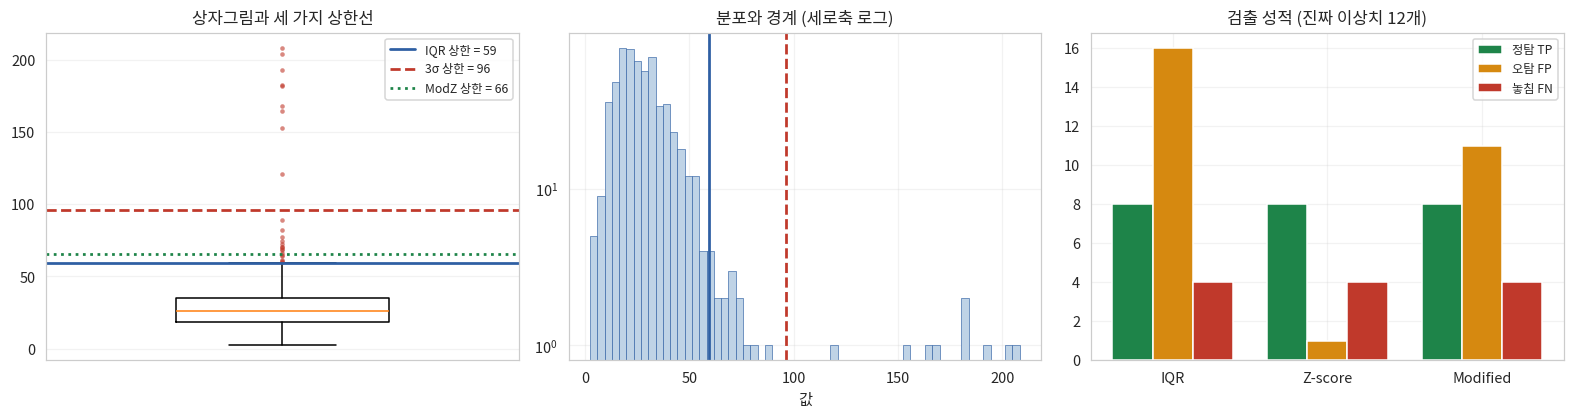

단변량 기준 비교
----------------------------------------
              기준  검출 수  실제 이상치 검출(TP)  오탐(FP)  놓침(FN)   재현율   정밀도
       IQR (1.5)    24              8      16       4 0.667 0.333
    Z-score (3σ)     9              8       1       4 0.667 0.889
Modified Z (3.5)    19              8      11       4 0.667 0.421



In [ ]:
# ============================================================
# 2-1. 세 기준을 같은 데이터에 적용
# ============================================================
r = np.random.default_rng(31)
base = r.lognormal(mean=3.2, sigma=0.45, size=600)          # 오른쪽 꼬리가 긴 분포
outs = np.concatenate([r.uniform(150, 210, 8), r.uniform(2, 5, 4)])
xs = np.concatenate([base, outs])
is_true_out = np.concatenate([np.zeros(len(base), bool), np.ones(len(outs), bool)])

def iqr_bounds(x, k=1.5):
    q1, q3 = np.percentile(x, [25, 75]); iqr = q3 - q1
    return q1 - k * iqr, q3 + k * iqr

def z_bounds(x, k=3.0):
    return x.mean() - k * x.std(ddof=1), x.mean() + k * x.std(ddof=1)

def mad_scores(x):
    med = np.median(x)
    mad = np.median(np.abs(x - med))
    return 0.6745 * (x - med) / (mad if mad > 0 else 1e-12)

lo_i, hi_i = iqr_bounds(xs)
lo_z, hi_z = z_bounds(xs)
mz = mad_scores(xs)

flag = {
    "IQR (1.5)":        (xs < lo_i) | (xs > hi_i),
    "Z-score (3σ)":     (xs < lo_z) | (xs > hi_z),
    "Modified Z (3.5)": np.abs(mz) > 3.5,
}

fig, axes = panel(1, 3, w=4.8, h=3.9)

# (1) 상자그림 + 세 기준선
axes[0].boxplot(xs, vert=True, widths=.45,
                flierprops=dict(marker="o", ms=3, mfc=C["red"], mec="none", alpha=.6))
for y, name, col, ls in [(hi_i, "IQR 상한", C["blue"], "-"),
                         (hi_z, "3σ 상한", C["red"], "--"),
                         (np.median(xs) + 3.5 * np.median(np.abs(xs - np.median(xs))) / 0.6745,
                          "ModZ 상한", C["green"], ":")]:
    axes[0].axhline(y, color=col, ls=ls, lw=1.8, label=f"{name} = {y:.0f}")
axes[0].set_title("상자그림과 세 가지 상한선")
axes[0].set_xticks([])
axes[0].legend(fontsize=8)

# (2) 히스토그램
bins = np.linspace(xs.min(), xs.max(), 60)
axes[1].hist(xs, bins=bins, color=C["light"], edgecolor=C["blue"], lw=.4)
for y, col, ls in [(hi_i, C["blue"], "-"), (hi_z, C["red"], "--")]:
    axes[1].axvline(y, color=col, ls=ls, lw=1.8)
axes[1].set_yscale("log")
axes[1].set_title("분포와 경계 (세로축 로그)")
axes[1].set_xlabel("값")

# (3) 검출 결과 비교
res_rows = []
for name, f in flag.items():
    tp = int((f & is_true_out).sum()); fp = int((f & ~is_true_out).sum())
    fn = int((~f & is_true_out).sum())
    res_rows.append({"기준": name, "검출 수": int(f.sum()),
                     "실제 이상치 검출(TP)": tp, "오탐(FP)": fp, "놓침(FN)": fn,
                     "재현율": tp / is_true_out.sum(),
                     "정밀도": tp / max(f.sum(), 1)})
crit_res = pd.DataFrame(res_rows)

w = 0.26
xp = np.arange(len(crit_res))
axes[2].bar(xp - w, crit_res["실제 이상치 검출(TP)"], w, color=C["green"], label="정탐 TP")
axes[2].bar(xp,     crit_res["오탐(FP)"],            w, color=C["amber"], label="오탐 FP")
axes[2].bar(xp + w, crit_res["놓침(FN)"],            w, color=C["red"],   label="놓침 FN")
axes[2].set_xticks(xp, [n.split(" ")[0] for n in crit_res["기준"]])
axes[2].set_title(f"검출 성적 (진짜 이상치 {is_true_out.sum()}개)")
axes[2].legend(fontsize=8)

fig.tight_layout()
plt.show()
show_table(crit_res, "단변량 기준 비교", "{:.3f}")

## 같은 데이터, 세 개의 답

경계선 위치부터 보세요. IQR이 가장 낮은 경계를 잡고, 그래서 가장 많이 검출하는 동시에 오탐도 가장 많습니다.
Z-score 경계가 가장 높아서 가장 적게 검출하고, Modified Z는 그 중간에 있습니다.

IQR의 오탐이 많은 이유가 중요합니다.
1.5배 규칙은 방금 유도했듯이 정규분포를 전제로 만들어진 숫자입니다.
그런데 이 데이터는 로그정규라 오른쪽 꼬리가 깁니다. 분포 가정이 틀리면 기준도 틀리는 거죠.
비대칭 분포에서는 로그 변환을 먼저 하거나 비대칭을 반영한 규칙을 써야 합니다.

---

## 2-2. Z-score가 실패하는 결정적 상황

강의에서 다룬 마스킹을 실험으로 확인합니다.
이상치가 여러 개 뭉쳐 있으면 그것들이 평균과 표준편차를 자기 쪽으로 끌어당겨서 스스로를 숨깁니다.
Z-score의 붕괴점이 0%라는 것이 이 현상의 이론적 근거였죠.

이상치 개수를 늘려가며 각 기준이 얼마나 잡아내는지 보겠습니다.

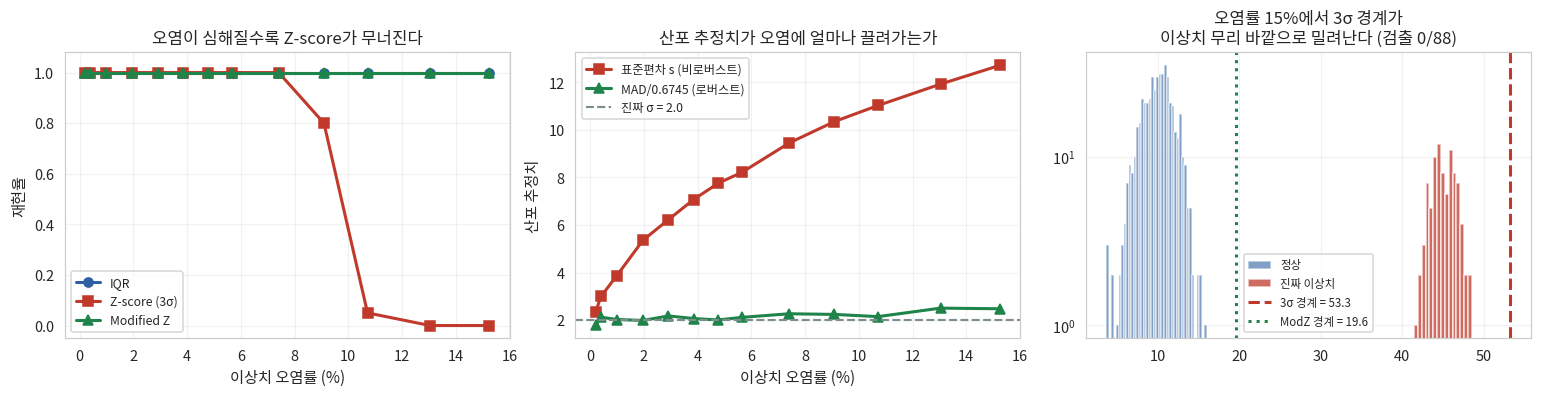

마스킹 실험
----------------------------------------
 이상치 개수  오염률(%)  IQR 재현율  Z-score 재현율  ModZ 재현율     sd
      1   0.200    1.000        1.000     1.000  2.347
      2   0.398    1.000        1.000     1.000  2.992
      5   0.990    1.000        1.000     1.000  3.871
     10   1.961    1.000        1.000     1.000  5.356
     15   2.913    1.000        1.000     1.000  6.228
     20   3.846    1.000        1.000     1.000  7.071
     25   4.762    1.000        1.000     1.000  7.757
     30   5.660    1.000        1.000     1.000  8.226
     40   7.407    1.000        1.000     1.000  9.453
     50   9.091    1.000        0.800     1.000 10.353
     60  10.714    1.000        0.050     1.000 11.030
     75  13.043    1.000        0.000     1.000 11.930
     90  15.254    1.000        0.000     1.000 12.721



In [ ]:
# ============================================================
# 2-2. 이상치 개수가 늘어날 때 각 기준의 검출력
# ============================================================
def masking_experiment(n_out_list, n_base=500, out_center=45, seed=0):
    rows = []
    for k in n_out_list:
        r = np.random.default_rng(seed + k)
        b = r.normal(10, 2, n_base)
        o = r.normal(out_center, 1.5, k) if k > 0 else np.empty(0)
        x = np.concatenate([b, o])
        truth = np.concatenate([np.zeros(n_base, bool), np.ones(k, bool)])
        lo_i, hi_i = iqr_bounds(x)
        lo_z, hi_z = z_bounds(x)
        f_i = (x < lo_i) | (x > hi_i)
        f_z = (x < lo_z) | (x > hi_z)
        f_m = np.abs(mad_scores(x)) > 3.5
        rows.append({
            "이상치 개수": k,
            "오염률(%)": 100 * k / len(x),
            "IQR 재현율": (f_i & truth).sum() / max(k, 1),
            "Z-score 재현율": (f_z & truth).sum() / max(k, 1),
            "ModZ 재현율": (f_m & truth).sum() / max(k, 1),
            "sd": x.std(ddof=1),
            "mad_scaled": np.median(np.abs(x - np.median(x))) / 0.6745,
        })
    return pd.DataFrame(rows)

ks = [1, 2, 5, 10, 15, 20, 25, 30, 40, 50, 60, 75, 90]
mask_res = masking_experiment(ks)

fig, axes = panel(1, 3, w=4.7, h=3.7)

axes[0].plot(mask_res["오염률(%)"], mask_res["IQR 재현율"], "o-", color=C["blue"], lw=2, label="IQR")
axes[0].plot(mask_res["오염률(%)"], mask_res["Z-score 재현율"], "s-", color=C["red"], lw=2, label="Z-score (3σ)")
axes[0].plot(mask_res["오염률(%)"], mask_res["ModZ 재현율"], "^-", color=C["green"], lw=2, label="Modified Z")
axes[0].set_xlabel("이상치 오염률 (%)"); axes[0].set_ylabel("재현율")
axes[0].set_ylim(-0.05, 1.08)
axes[0].set_title("오염이 심해질수록 Z-score가 무너진다")
axes[0].legend(fontsize=8)

axes[1].plot(mask_res["오염률(%)"], mask_res["sd"], "s-", color=C["red"], lw=2,
             label="표준편차 s (비로버스트)")
axes[1].plot(mask_res["오염률(%)"], mask_res["mad_scaled"], "^-", color=C["green"], lw=2,
             label="MAD/0.6745 (로버스트)")
axes[1].axhline(2.0, color=C["gray"], ls="--", lw=1.4, label="진짜 σ = 2.0")
axes[1].set_xlabel("이상치 오염률 (%)"); axes[1].set_ylabel("산포 추정치")
axes[1].set_title("산포 추정치가 오염에 얼마나 끌려가는가")
axes[1].legend(fontsize=8)

# 구체적 사례: 오염 15%
r = np.random.default_rng(99)
N_OUT_DEMO = 88
x_demo = np.concatenate([r.normal(10, 2, 500), r.normal(45, 1.5, N_OUT_DEMO)])
truth_demo = np.concatenate([np.zeros(500, bool), np.ones(N_OUT_DEMO, bool)])
axes[2].hist(x_demo[~truth_demo], bins=40, color=C["blue"], alpha=.6, label="정상")
axes[2].hist(x_demo[truth_demo], bins=15, color=C["red"], alpha=.75, label="진짜 이상치")
lo_z2, hi_z2 = z_bounds(x_demo)
axes[2].axvline(hi_z2, color=C["red"], ls="--", lw=2, label=f"3σ 경계 = {hi_z2:.1f}")
med = np.median(x_demo); mad = np.median(np.abs(x_demo - med))
axes[2].axvline(med + 3.5 * mad / 0.6745, color=C["green"], ls=":", lw=2,
                label=f"ModZ 경계 = {med + 3.5*mad/0.6745:.1f}")
axes[2].set_yscale("log")
n_caught = int((x_demo[truth_demo] > hi_z2).sum())
axes[2].set_title(f"오염률 {truth_demo.mean():.0%}에서 3σ 경계가\n이상치 무리 바깥으로 밀려난다 "
                  f"(검출 {n_caught}/{N_OUT_DEMO})")
axes[2].legend(fontsize=7.5)

fig.tight_layout()
plt.show()
show_table(mask_res[["이상치 개수", "오염률(%)", "IQR 재현율", "Z-score 재현율", "ModZ 재현율", "sd"]],
           "마스킹 실험", "{:.3f}")

## 이상치가 많아질수록 이상치를 못 찾습니다

왼쪽 그림이 결론입니다. 오염률이 7%를 넘어가는 순간 빨간 선, 즉 Z-score의 재현율이
1.0에서 0으로 절벽처럼 떨어집니다. 초록 선인 Modified Z는 끝까지 1.0을 유지하고요.

가운데 그림이 원인을 보여줍니다.
빨간 선인 표준편차가 오염률과 함께 계속 커집니다. 진짜 $\sigma$ 는 2인데 12를 넘어갑니다.
표준편차가 커지면 $3\sigma$ 경계가 멀리 밀려나고, 이상치들이 그 안으로 들어와 버립니다.
초록 선인 MAD 기반 추정치는 거의 평평하게 2 근처를 유지합니다.
중앙값 기반이라 소수의 극단값에 흔들리지 않기 때문입니다. 붕괴점 50%가 이런 의미죠.

오른쪽 그림이 그 장면입니다.
빨간 점선인 $3\sigma$ 경계가 빨간 히스토그램보다 더 오른쪽에 그어져 있습니다.
경계가 이상치 무리를 통째로 지나쳐 버려서 88개 중 0개가 검출됩니다.
반면 초록 점선인 Modified Z 경계는 두 무리 사이 빈 공간에 정확히 놓여 88개를 전부 잡아냅니다.

같은 데이터에 같은 임계값 3인데 한쪽은 100%, 다른 쪽은 0%입니다.
차이는 오직 무엇으로 산포를 쟀느냐뿐입니다.

## 실무로 옮기면

"평균 $\pm 3\sigma$ 로 이상치를 제거한다"는 관행은 이상치가 적을 때만 작동합니다.
그런데 이상치가 적은지 많은지를 알려면 이미 이상치를 찾았어야 하죠. 순환 논리입니다.

그래서 기본값을 MAD 기반이나 IQR로 두는 편이 안전합니다. 둘 다 로버스트한 통계량을 쓰니까요.
그리고 마스킹은 Isolation Forest가 서브샘플링을 쓰는 이유이기도 합니다.
서브샘플에서는 뭉쳐 있던 이상치가 흩어지면서 마스킹이 풀립니다. 뒤에서 직접 확인합니다.

---

## 2-3. 변수를 하나씩 봐서는 절대 못 잡는 이상치

강의에서 들었던 예입니다. 키 190cm에 몸무게 50kg.
각각은 정상 범위 안에 있는데 조합이 불가능하죠.
이런 이상치는 어떤 단변량 기준으로도 잡히지 않습니다. 상관 구조를 봐야 합니다.

그 도구가 마할라노비스 거리입니다.

$$
d_M(x) = \sqrt{(x-\mu)^\top \Sigma^{-1}(x-\mu)}, \qquad d_M^2(x) \sim \chi^2_p
$$

$\Sigma^{-1}$ 을 끼워 넣으면 많이 퍼진 방향으로는 거리를 줄여 재고 적게 퍼진 방향으로는 늘려 잽니다.
타원형 데이터 구름을 원으로 펴놓고 거리를 재는 것과 같은 효과죠.
그리고 카이제곱 분포를 쓰면 임계값을 통계적으로 정할 수 있습니다. 자유도 $p$ 에 상위 1% 분위수를 쓰면 됩니다.

아래에서는 `area`–`rooms` 평면에 "면적은 큰데 방이 1개"인 점들을 심어 봅니다.

카이제곱(df=2) 99% 임계값: d_M = 3.035
단변량 IQR로 잡힌 주입 이상치 : 0 / 12
마할라노비스(일반)로 잡힌 개수 : 12 / 12
마할라노비스(로버스트 MCD)     : 12 / 12


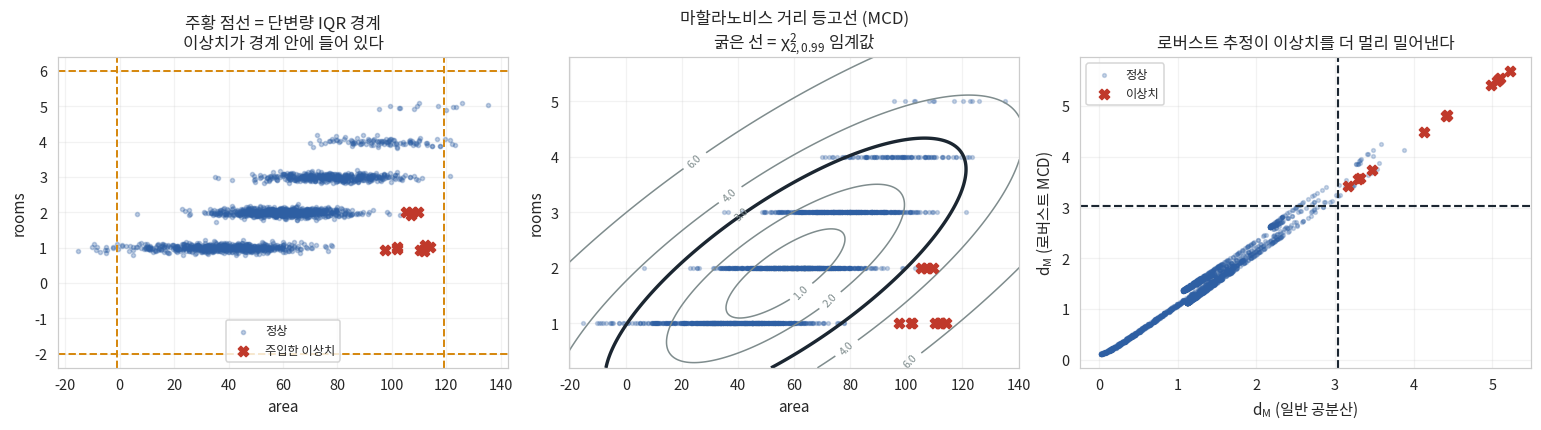

In [ ]:
# ============================================================
# 2-3. 다변량 이상치: 단변량으로는 안 보인다
# ============================================================
sub = clean[["area", "rooms"]].to_numpy().astype(float)
r = np.random.default_rng(41)

# 상관 구조를 위반하는 이상치 12개를 주입 (면적은 크고 방은 적다 / 반대도)
n_inj = 12
inj = np.column_stack([
    r.uniform(95, 115, n_inj),                       # 넓은 면적 (정상 범위 안)
    r.choice([1, 1, 2], n_inj).astype(float),        # 적은 방 개수 (정상 범위 안)
])
X2 = np.vstack([sub, inj])
truth2 = np.concatenate([np.zeros(len(sub), bool), np.ones(n_inj, bool)])

# 단변량 판정
uni_flag = np.zeros(len(X2), bool)
for j in range(2):
    lo, hi = iqr_bounds(X2[:, j])
    uni_flag |= (X2[:, j] < lo) | (X2[:, j] > hi)

# 마할라노비스 (일반 추정 vs 로버스트 MCD)
emp = EmpiricalCovariance().fit(X2)
mcd = MinCovDet(random_state=0).fit(X2)
d_emp = np.sqrt(emp.mahalanobis(X2))
d_mcd = np.sqrt(mcd.mahalanobis(X2))
thr = np.sqrt(stats.chi2.ppf(0.99, df=2))

print(f"카이제곱(df=2) 99% 임계값: d_M = {thr:.3f}")
print(f"단변량 IQR로 잡힌 주입 이상치 : {int(uni_flag[truth2].sum())} / {n_inj}")
print(f"마할라노비스(일반)로 잡힌 개수 : {int((d_emp[truth2] > thr).sum())} / {n_inj}")
print(f"마할라노비스(로버스트 MCD)     : {int((d_mcd[truth2] > thr).sum())} / {n_inj}")

fig, axes = panel(1, 3, w=4.7, h=4.0)

# (1) 산점도 + 단변량 경계
axes[0].scatter(X2[~truth2, 0], X2[~truth2, 1] + r.normal(0, .07, (~truth2).sum()),
                s=7, alpha=.3, color=C["blue"], label="정상")
axes[0].scatter(X2[truth2, 0], X2[truth2, 1] + r.normal(0, .07, truth2.sum()),
                s=45, color=C["red"], marker="X", label="주입한 이상치", zorder=5)
for j, fn in [(0, axes[0].axvline), (1, axes[0].axhline)]:
    lo, hi = iqr_bounds(X2[:, j])
    fn(lo, color=C["amber"], ls="--", lw=1.3)
    fn(hi, color=C["amber"], ls="--", lw=1.3)
axes[0].set_xlabel("area"); axes[0].set_ylabel("rooms")
axes[0].set_title("주황 점선 = 단변량 IQR 경계\n이상치가 경계 안에 들어 있다")
axes[0].legend(fontsize=8)

# (2) 마할라노비스 등고선
gx = np.linspace(X2[:, 0].min() - 5, X2[:, 0].max() + 5, 220)
gy = np.linspace(X2[:, 1].min() - .8, X2[:, 1].max() + .8, 220)
GX, GY = np.meshgrid(gx, gy)
G = np.column_stack([GX.ravel(), GY.ravel()])
Z = np.sqrt(mcd.mahalanobis(G)).reshape(GX.shape)
cs = axes[1].contour(GX, GY, Z, levels=[1, 2, thr, 4, 6], colors=[C["gray"]] * 5, linewidths=1)
axes[1].clabel(cs, fmt="%.1f", fontsize=7)
axes[1].contour(GX, GY, Z, levels=[thr], colors=[C["dark"]], linewidths=2.2)
axes[1].scatter(X2[~truth2, 0], X2[~truth2, 1], s=6, alpha=.25, color=C["blue"])
axes[1].scatter(X2[truth2, 0], X2[truth2, 1], s=45, color=C["red"], marker="X", zorder=5)
axes[1].set_xlabel("area"); axes[1].set_ylabel("rooms")
axes[1].set_title(f"마할라노비스 거리 등고선 (MCD)\n굵은 선 = $\\chi^2_{{2,0.99}}$ 임계값")

# (3) 거리 비교
axes[2].scatter(d_emp[~truth2], d_mcd[~truth2], s=6, alpha=.25, color=C["blue"], label="정상")
axes[2].scatter(d_emp[truth2], d_mcd[truth2], s=45, color=C["red"], marker="X", label="이상치")
axes[2].axhline(thr, color=C["dark"], ls="--", lw=1.4)
axes[2].axvline(thr, color=C["dark"], ls="--", lw=1.4)
axes[2].set_xlabel("$d_M$ (일반 공분산)"); axes[2].set_ylabel("$d_M$ (로버스트 MCD)")
axes[2].set_title("로버스트 추정이 이상치를 더 멀리 밀어낸다")
axes[2].legend(fontsize=8)

fig.tight_layout()
plt.show()

## 단변량으로는 100% 놓칩니다

왼쪽 그림을 보면 빨간 X 표시가 주황 점선인 단변량 IQR 경계 안쪽에 있습니다.
면적 95~115는 정상 범위이고 방 1~2개도 정상 범위니까 각 축에서는 아무 문제가 없습니다.
그런데 데이터 구름과 비교하면 명백히 떨어져 있습니다.
면적이 크면 방이 많아야 한다는 규칙을 위반했기 때문이죠.

가운데 그림의 마할라노비스 등고선은 기울어진 타원입니다. 데이터의 상관 구조를 따라간 결과입니다.
빨간 X들이 굵은 임계선 바깥에 놓이면서 잡힙니다.

오른쪽 그림은 일반 공분산과 로버스트 MCD를 비교한 것인데 MCD 쪽 거리가 훨씬 큽니다.
일반 공분산은 이상치를 포함해서 추정하니 공분산이 부풀려지고,
그 결과 이상치까지의 거리가 짧게 나옵니다. 마할라노비스 버전의 마스킹인 셈이죠.

실무에서 이상치 처리라고 하면 대개 컬럼별 `describe()`와 boxplot으로 끝냅니다.
그런데 변수 간 관계를 위반하는 이상치가 오히려 더 의미 있는 경우가 많습니다.
사기 거래가 대표적으로 그런 유형이고요.

다만 마할라노비스는 데이터가 하나의 타원형 덩어리일 때만 작동합니다.
군집이 여러 개면 무너집니다. 그때 필요한 것이 다음 절의 LOF입니다.

---

## 2-4. Local Outlier Factor — "멀다"는 상대적입니다

강의의 핵심 그림을 코드로 재현합니다.
밀도가 다른 두 군집을 만들고 각각의 옆에 같은 성격의 점을 놓습니다.
$a_1$ 은 빽빽한 군집 옆이라 그 동네 기준으로는 엄청 먼 점이고,
$a_2$ 는 성긴 군집 옆이라 그 동네 기준으로는 흔한 거리에 있는 점입니다.
전역 기준인 단순 kNN 거리로는 두 점을 구분할 수 없습니다. LOF는 구분합니다.

정의를 다시 적으면 이렇습니다.

$$
\text{reach-dist}_k(p,o) = \max\{k\text{-}distance(o),\, d(p,o)\}
$$
$$
LRD_k(p) = \left(\frac{1}{|N_k(p)|}\sum_{o\in N_k(p)}\text{reach-dist}_k(p,o)\right)^{-1}
\qquad
LOF_k(p) = \frac{\frac{1}{|N_k(p)|}\sum_{o\in N_k(p)} LRD_k(o)}{LRD_k(p)}
$$

먼저 직접 구현해서 sklearn과 값이 일치하는지 확인하겠습니다.
식을 코드로 옮길 수 있으면 이해한 겁니다.

최대 절대 오차 : 1.539e-09
상관계수       : 1.0000000000

수식을 그대로 옮긴 구현이 sklearn과 일치합니다.
(sklearn은 논문과 달리 동점을 확장하지 않고 정확히 k개 이웃만 사용합니다.)


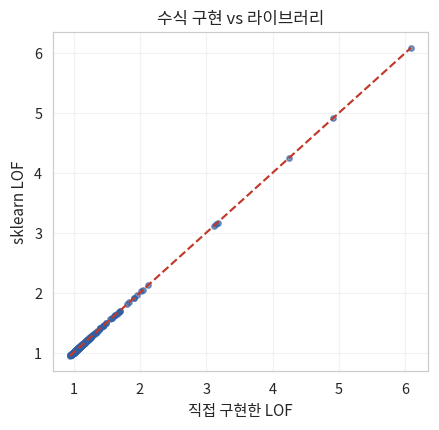

In [ ]:
# ============================================================
# 2-4. LOF 직접 구현 → sklearn과 대조
# ============================================================
def lof_from_scratch(X, k=20):
    n = len(X)
    nn = NearestNeighbors(n_neighbors=k + 1).fit(X)   # 자기 자신 포함이라 k+1
    dist, idx = nn.kneighbors(X)
    dist, idx = dist[:, 1:], idx[:, 1:]               # 자기 자신 제거

    k_distance = dist[:, -1]                          # k번째 이웃까지의 거리

    # reach-dist_k(p, o) = max(k-distance(o), d(p,o))
    reach = np.maximum(k_distance[idx], dist)

    # LRD = 1 / 평균 reach-dist
    lrd = 1.0 / (reach.mean(axis=1) + 1e-12)

    # LOF = 이웃들의 LRD 평균 / 자신의 LRD
    lof = lrd[idx].mean(axis=1) / lrd
    return lof, k_distance, lrd


# 검증용 데이터
r = np.random.default_rng(7)
Xv = np.vstack([r.normal([0, 0], 0.35, (160, 2)),
                r.normal([4, 4], 1.20, (160, 2)),
                r.uniform(-2, 7, (12, 2))])

K = 20
lof_mine, _, _ = lof_from_scratch(Xv, k=K)
lof_sk = -LocalOutlierFactor(n_neighbors=K).fit(Xv).negative_outlier_factor_

print(f"최대 절대 오차 : {np.abs(lof_mine - lof_sk).max():.3e}")
print(f"상관계수       : {np.corrcoef(lof_mine, lof_sk)[0,1]:.10f}")
print()
print("수식을 그대로 옮긴 구현이 sklearn과 일치합니다.")
print("(sklearn은 논문과 달리 동점을 확장하지 않고 정확히 k개 이웃만 사용합니다.)")

fig, ax = panel(1, 1, w=4.4, h=4.0)
ax.scatter(lof_mine, lof_sk, s=12, alpha=.6, color=C["blue"])
lim = [min(lof_mine.min(), lof_sk.min()), max(lof_mine.max(), lof_sk.max())]
ax.plot(lim, lim, color=C["red"], ls="--", lw=1.4)
ax.set_xlabel("직접 구현한 LOF"); ax.set_ylabel("sklearn LOF")
ax.set_title("수식 구현 vs 라이브러리")
plt.show()

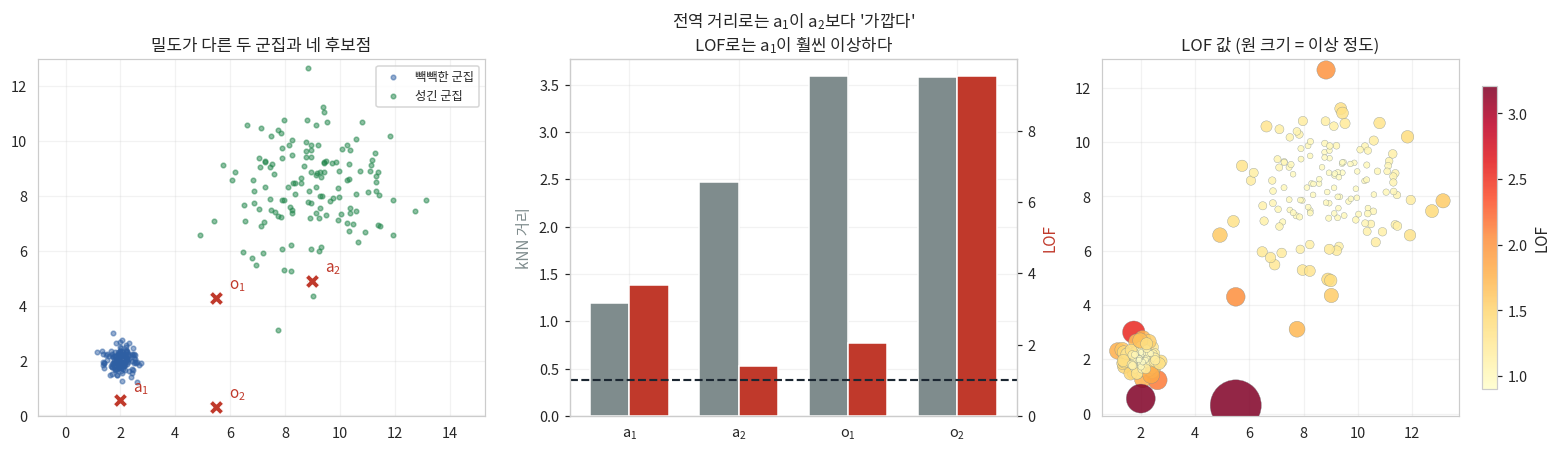

같은 네 점을 세 가지 기준으로 채점
----------------------------------------
             후보점  kNN 거리 (전역 기준)  LOF (지역 기준)  IsolationForest 점수
$a_1$ (빽빽한 군집 옆)           1.192        3.672               0.634
 $a_2$ (성긴 군집 옆)           2.465        1.409               0.534
   $o_1$ (군집 사이)           3.586        2.048               0.621
   $o_2$ (완전 외곽)           3.577        9.517               0.726



In [ ]:
# ============================================================
# 2-5. a1 / a2 재현 — LOF가 전역 기준과 어떻게 다른가
# ============================================================
r = np.random.default_rng(3)
dense = r.normal([2.0, 2.0], 0.30, (140, 2))     # 빽빽한 군집
loose = r.normal([9.0, 8.0], 1.60, (140, 2))     # 성긴 군집

probes = np.array([
    [2.0, 0.55],    # a1 : 빽빽한 군집에서 약 1.4 떨어짐
    [9.0, 4.9],     # a2 : 성긴 군집에서 약 3.1 떨어짐 (절대거리는 더 멂)
    [5.5, 4.3],     # o1 : 두 군집 사이의 빈 공간
    [5.5, 0.3],     # o2 : 완전히 동떨어짐
])
labels = ["$a_1$ (빽빽한 군집 옆)", "$a_2$ (성긴 군집 옆)", "$o_1$ (군집 사이)", "$o_2$ (완전 외곽)"]

Xp = np.vstack([dense, loose, probes])
K = 20

lof_all, kdist_all, _ = lof_from_scratch(Xp, k=K)
iso = IsolationForest(n_estimators=200, random_state=0, contamination="auto").fit(Xp)
if_score = -iso.score_samples(Xp)      # 논문 정의의 s(x,n) (0~1, 클수록 이상)

probe_idx = np.arange(len(Xp) - 4, len(Xp))
cmp_probe = pd.DataFrame({
    "후보점": labels,
    "kNN 거리 (전역 기준)": kdist_all[probe_idx],
    "LOF (지역 기준)": lof_all[probe_idx],
    "IsolationForest 점수": if_score[probe_idx],
})

fig, axes = panel(1, 3, w=4.8, h=4.2)

# (1) 데이터 배치
axes[0].scatter(dense[:, 0], dense[:, 1], s=9, alpha=.5, color=C["blue"], label="빽빽한 군집")
axes[0].scatter(loose[:, 0], loose[:, 1], s=9, alpha=.5, color=C["green"], label="성긴 군집")
for (px, py), lb in zip(probes, labels):
    axes[0].scatter(px, py, s=90, color=C["red"], marker="X", zorder=6, edgecolor="white", lw=.8)
    axes[0].annotate(lb.split(" ")[0], (px, py), textcoords="offset points",
                     xytext=(8, 6), fontsize=10, color=C["red"], weight="bold")
axes[0].set_title("밀도가 다른 두 군집과 네 후보점")
axes[0].legend(fontsize=8)
axes[0].set_aspect("equal", adjustable="datalim")

# (2) 전역 기준 vs LOF
w = 0.36
xp_ = np.arange(4)
ax2 = axes[1]
ax2.bar(xp_ - w/2, cmp_probe["kNN 거리 (전역 기준)"], w, color=C["gray"], label="kNN 거리 (전역)")
ax2.set_ylabel("kNN 거리", color=C["gray"])
ax2b = ax2.twinx()
ax2b.bar(xp_ + w/2, cmp_probe["LOF (지역 기준)"], w, color=C["red"], label="LOF (지역)")
ax2b.axhline(1.0, color=C["dark"], ls="--", lw=1.4)
ax2b.set_ylabel("LOF", color=C["red"])
ax2b.grid(False)
ax2.set_xticks(xp_, ["$a_1$", "$a_2$", "$o_1$", "$o_2$"])
ax2.set_title("전역 거리로는 $a_1$이 $a_2$보다 '가깝다'\nLOF로는 $a_1$이 훨씬 이상하다")

# (3) LOF 점수를 원 크기로
sizes = 14 + 130 * np.clip(lof_all - 1, 0, None)
sc = axes[2].scatter(Xp[:, 0], Xp[:, 1], s=sizes, c=lof_all, cmap="YlOrRd",
                     vmin=0.9, vmax=np.percentile(lof_all, 99.5),
                     edgecolor=C["gray"], lw=.25, alpha=.85)
plt.colorbar(sc, ax=axes[2], shrink=.85, label="LOF")
axes[2].set_title("LOF 값 (원 크기 = 이상 정도)")
axes[2].set_aspect("equal", adjustable="datalim")

fig.tight_layout()
plt.show()
show_table(cmp_probe, "같은 네 점을 세 가지 기준으로 채점", "{:.3f}")

## 이 표가 LOF의 존재 이유입니다

표를 세로로 읽어 보세요.

kNN 거리로 재면 $a_1$ 이 1.19, $a_2$ 가 2.47입니다. $a_1$ 이 절반 이하로 가깝습니다.
전역 기준으로는 $a_2$ 쪽이 더 이상해 보인다는 뜻이죠.

LOF로 재면 정반대가 됩니다. $a_1$ 이 3.67, $a_2$ 가 1.41입니다.
$a_2$ 는 1에 가까우니 사실상 정상이고, $a_1$ 은 주변보다 3.7배 성기다는 판정을 받습니다.

$a_1$ 이 속한 동네는 표준편차 0.30짜리 빽빽한 군집이고 $a_2$ 의 동네는 1.60짜리 성긴 군집이니
같은 거리라도 의미가 전혀 다릅니다. 서울 도심의 200미터와 산골의 200미터가 다른 것과 같습니다.

LOF는 분모에 자기 밀도를 놓고 분자에 이웃 밀도를 놓아서 이 동네 사정을 상쇄시킵니다.
빽빽한 동네에서는 분모와 분자가 둘 다 크고 성긴 동네에서는 둘 다 작으니,
나누고 나면 "동네 평균 대비 나는 몇 배로 성긴가"만 남습니다.

같은 표의 Isolation Forest 점수도 보세요.
$o_1$, $o_2$ 처럼 전역적으로 동떨어진 점은 잘 잡지만 $a_1$ 에 대한 점수는 LOF만큼 두드러지지 않습니다.
iForest는 전역적인 알고리즘이라 로컬 이상치에 상대적으로 둔감합니다.
강의에서 말한 두 알고리즘의 거울상 관계가 이 숫자에 들어 있습니다.

---

## 2-5. Isolation Forest — 밀도를 재지 말고 격리해 보라

발상의 전환입니다. 정상을 모형화하지 않고 이상치의 "떼어내기 쉬움"을 직접 공략합니다.
무작위로 칼질을 했을 때 외딴 점은 금방 혼자 남고 붐비는 점은 오래 걸리는데, 그 깊이가 곧 점수입니다.

$$
s(x, n) = 2^{-\dfrac{E(h(x))}{c(n)}}, \qquad
c(n) = 2H(n-1) - \frac{2(n-1)}{n}, \qquad H(i) = \ln i + \gamma
$$

$c(n)$ 은 $n$ 개 점을 가진 이진 탐색 트리에서 실패한 탐색의 평균 경로 길이입니다.
isolation tree의 구조가 BST와 같기 때문에 이미 잘 연구된 자료구조 이론의 결과를 그대로 빌려온 것이죠.
말하자면 "이 크기에서 평균적인 깊이"라는 기준선입니다.

그래서 $E(h) = c(n)$ 이면 $s = 0.5$ 로 기준선에 놓이고,
$E(h)$ 가 0에 가까울수록 $s$ 가 1로, 반대로 깊어질수록 0으로 갑니다.

먼저 $c(n)$ 을 직접 계산하고, sklearn 점수에서 역산한 평균 깊이가 실제로 이 관계를 만족하는지 확인합니다.

c(   10) =  3.7489    (참고: log2(n) = 3.322)
c(   32) =  6.0849    (참고: log2(n) = 5.000)
c(  128) =  8.8584    (참고: log2(n) = 7.000)
c(  256) = 10.2448    (참고: log2(n) = 8.000)
c( 1024) = 13.0174    (참고: log2(n) = 10.000)
c( 4096) = 15.7900    (참고: log2(n) = 12.000)

서브샘플 크기 psi=256, c(psi)=10.2448 일 때의 점수 대응
------------------------------------------
 평균 깊이 E(h)  점수 s(x,n)         해석
     1.0000     0.9346   매우 강한 이상
     2.0000     0.8734      강한 이상
     4.0000     0.7629         이상
     5.0000     0.7130         이상
     6.0000     0.6663         의심
     8.0000     0.5820         경계
    10.2448     0.5000 기준선 (=0.5)
    12.0000     0.4440         정상
    15.0000     0.3624         정상
    20.0000     0.2584     확실한 정상



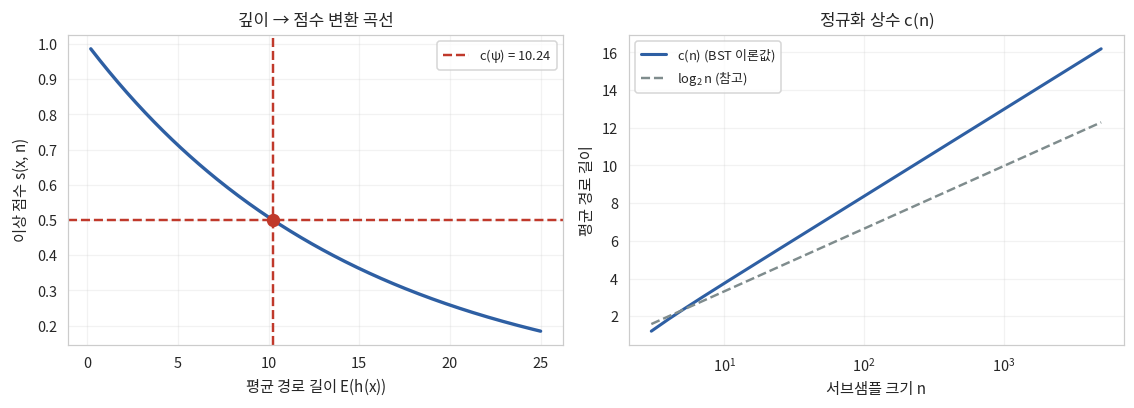

In [ ]:
# ============================================================
# 2-6. c(n) 계산과 점수-깊이 관계 확인
# ============================================================
EULER = 0.5772156649015329

def harmonic(i):
    return np.log(i) + EULER

def c_factor(n):
    n = np.asarray(n, dtype=float)
    return np.where(n > 2, 2 * harmonic(n - 1) - 2 * (n - 1) / n,
                    np.where(n == 2, 1.0, 0.0))

for n in [10, 32, 128, 256, 1024, 4096]:
    print(f"c({n:5d}) = {float(c_factor(n)):7.4f}    (참고: log2(n) = {np.log2(n):.3f})")
print()

psi = 256
cn = float(c_factor(psi))
depths = np.array([1, 2, 4, 5, 6, 8, cn, 12, 15, 20])
scores = 2 ** (-depths / cn)
tbl = pd.DataFrame({"평균 깊이 E(h)": depths, "점수 s(x,n)": scores,
                    "해석": ["매우 강한 이상", "강한 이상", "이상", "이상", "의심",
                            "경계", "기준선 (=0.5)", "정상", "정상", "확실한 정상"]})
show_table(tbl, f"서브샘플 크기 psi={psi}, c(psi)={cn:.4f} 일 때의 점수 대응", "{:.4f}")

fig, axes = panel(1, 2, w=5.2, h=3.8)
hh = np.linspace(0.2, 25, 300)
axes[0].plot(hh, 2 ** (-hh / cn), color=C["blue"], lw=2.2)
axes[0].axvline(cn, color=C["red"], ls="--", lw=1.6, label=f"$c(\\psi)$ = {cn:.2f}")
axes[0].axhline(0.5, color=C["red"], ls="--", lw=1.6)
axes[0].scatter([cn], [0.5], s=60, color=C["red"], zorder=5)
axes[0].set_xlabel("평균 경로 길이 $E(h(x))$"); axes[0].set_ylabel("이상 점수 $s(x,n)$")
axes[0].set_title("깊이 → 점수 변환 곡선")
axes[0].legend(fontsize=8.5)

ns = np.arange(3, 5000)
axes[1].plot(ns, c_factor(ns), color=C["blue"], lw=2, label="$c(n)$ (BST 이론값)")
axes[1].plot(ns, np.log2(ns), color=C["gray"], ls="--", lw=1.6, label="$\\log_2 n$ (참고)")
axes[1].set_xscale("log")
axes[1].set_xlabel("서브샘플 크기 n"); axes[1].set_ylabel("평균 경로 길이")
axes[1].set_title("정규화 상수 $c(n)$")
axes[1].legend(fontsize=8.5)
fig.tight_layout()
plt.show()

정상  평균 깊이  12.68  →  평균 점수 0.427
이상치 평균 깊이   4.97  →  평균 점수 0.716


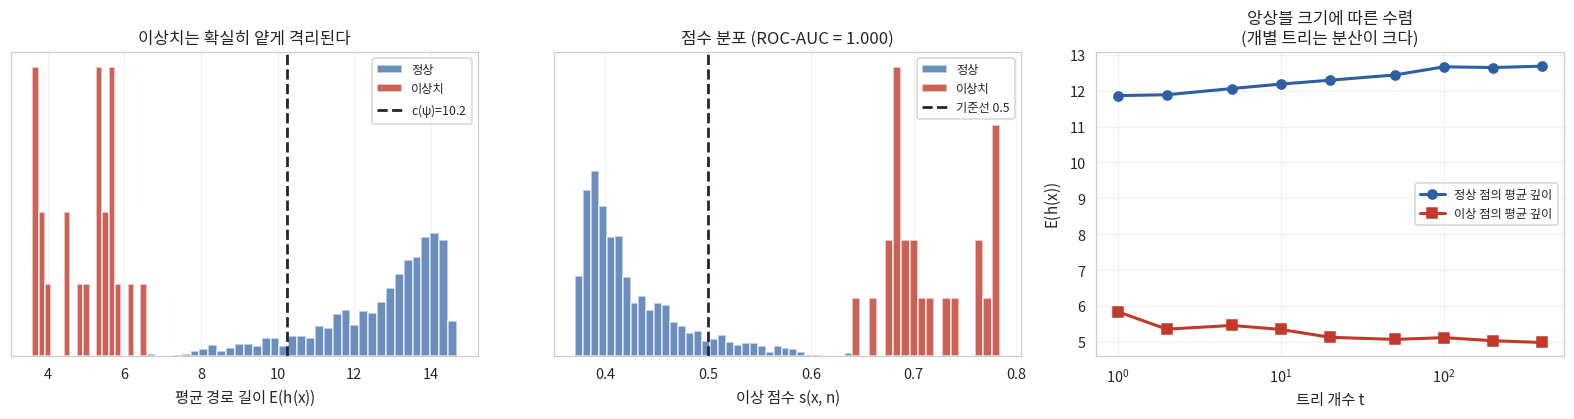

In [ ]:
# ============================================================
# 2-7. 실제로 이상치가 더 얕게 격리되는가
# ============================================================
r = np.random.default_rng(5)
Xn = r.normal(0, 1, (1000, 2))
Xo = r.uniform(-6, 6, (40, 2))
Xo = Xo[np.linalg.norm(Xo, axis=1) > 4.0]           # 바깥쪽만 남김
Xd = np.vstack([Xn, Xo])
yd = np.concatenate([np.zeros(len(Xn), bool), np.ones(len(Xo), bool)])

PSI = 256
clf = IsolationForest(n_estimators=300, max_samples=PSI, random_state=0).fit(Xd)
s_score = -clf.score_samples(Xd)                    # 논문 정의 s(x,n)
E_h = -np.log2(s_score) * float(c_factor(PSI))      # 점수에서 역산한 평균 깊이

fig, axes = panel(1, 3, w=4.8, h=3.9)

axes[0].hist(E_h[~yd], bins=35, alpha=.7, color=C["blue"], label="정상", density=True)
axes[0].hist(E_h[yd], bins=18, alpha=.8, color=C["red"], label="이상치", density=True)
axes[0].axvline(float(c_factor(PSI)), color=C["dark"], ls="--", lw=1.8,
                label=f"$c(\\psi)$={float(c_factor(PSI)):.1f}")
axes[0].set_xlabel("평균 경로 길이 $E(h(x))$"); axes[0].set_yticks([])
axes[0].set_title("이상치는 확실히 얕게 격리된다")
axes[0].legend(fontsize=8)

axes[1].hist(s_score[~yd], bins=35, alpha=.7, color=C["blue"], label="정상", density=True)
axes[1].hist(s_score[yd], bins=18, alpha=.8, color=C["red"], label="이상치", density=True)
axes[1].axvline(0.5, color=C["dark"], ls="--", lw=1.8, label="기준선 0.5")
axes[1].set_xlabel("이상 점수 $s(x,n)$"); axes[1].set_yticks([])
axes[1].set_title(f"점수 분포 (ROC-AUC = {roc_auc_score(yd, s_score):.3f})")
axes[1].legend(fontsize=8)

print(f"정상  평균 깊이 {E_h[~yd].mean():6.2f}  →  평균 점수 {s_score[~yd].mean():.3f}")
print(f"이상치 평균 깊이 {E_h[yd].mean():6.2f}  →  평균 점수 {s_score[yd].mean():.3f}")

# 트리 개수에 따른 수렴
tt = [1, 2, 5, 10, 20, 50, 100, 200, 400]
conv_n, conv_o = [], []
for t in tt:
    c2 = IsolationForest(n_estimators=t, max_samples=PSI, random_state=1).fit(Xd)
    ss = -c2.score_samples(Xd)
    hh2 = -np.log2(ss) * float(c_factor(PSI))
    conv_n.append(hh2[~yd].mean()); conv_o.append(hh2[yd].mean())
axes[2].plot(tt, conv_n, "o-", color=C["blue"], lw=2, label="정상 점의 평균 깊이")
axes[2].plot(tt, conv_o, "s-", color=C["red"], lw=2, label="이상 점의 평균 깊이")
axes[2].set_xscale("log"); axes[2].set_xlabel("트리 개수 t")
axes[2].set_ylabel("$E(h(x))$")
axes[2].set_title("앙상블 크기에 따른 수렴\n(개별 트리는 분산이 크다)")
axes[2].legend(fontsize=8)

fig.tight_layout()
plt.show()

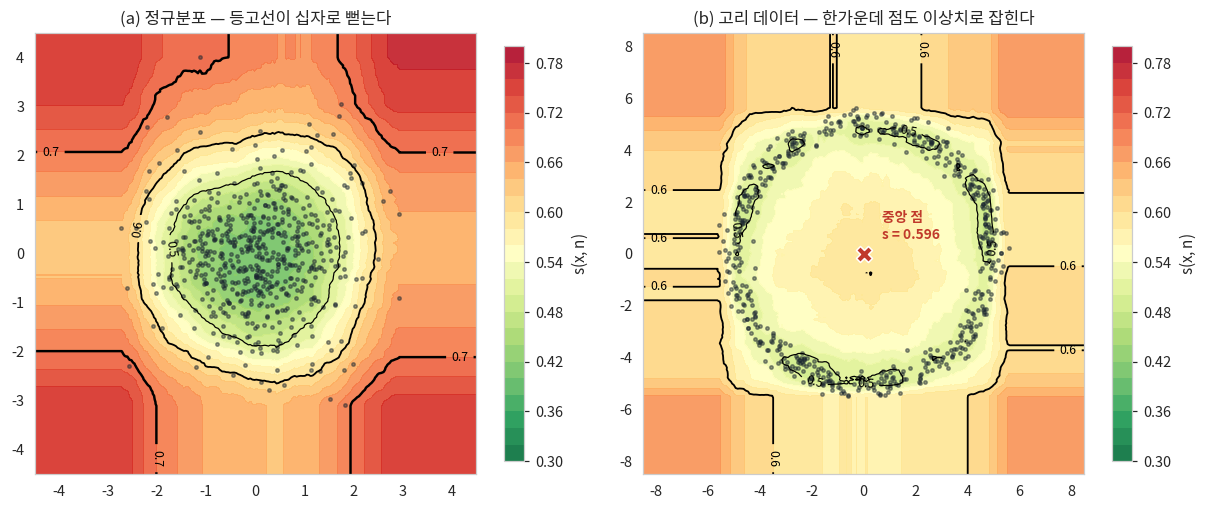

고리 위 점들의 평균 점수 : 0.508
한가운데 점의 점수       : 0.596

한가운데 점은 데이터 전체의 '평균'에 가장 가깝습니다.
마할라노비스 거리로 재면 가장 정상적인 점으로 판정됩니다.
Isolation Forest는 '중심에서의 거리'가 아니라 '격리 용이성'을 재기 때문에 이 점을 잡아냅니다.


In [ ]:
# ============================================================
# 2-8. 점수 등고선 — 축 정렬 편향과 고리 데이터
# ============================================================
def score_grid(model, xlim, ylim, res=220, sklearn_lof=None, data=None):
    gx = np.linspace(*xlim, res); gy = np.linspace(*ylim, res)
    GX, GY = np.meshgrid(gx, gy)
    G = np.column_stack([GX.ravel(), GY.ravel()])
    if sklearn_lof is not None:
        Z = -sklearn_lof.score_samples(G)
    else:
        Z = -model.score_samples(G)
    return GX, GY, Z.reshape(GX.shape)

r = np.random.default_rng(13)
# (a) 정규분포
Xa = r.normal(0, 1, (600, 2))
# (b) 고리 + 중앙 한 점 (강의의 두 번째 예제)
th = r.uniform(0, 2 * np.pi, 600)
rad = 5 + r.normal(0, 0.28, 600)
Xb = np.column_stack([rad * np.cos(th), rad * np.sin(th)])
Xb = np.vstack([Xb, [[0.0, 0.0]]])

fig, axes = panel(1, 2, w=5.6, h=5.0)

for ax, X, title, lim in [
    (axes[0], Xa, "(a) 정규분포 — 등고선이 십자로 뻗는다", (-4.5, 4.5)),
    (axes[1], Xb, "(b) 고리 데이터 — 한가운데 점도 이상치로 잡힌다", (-8.5, 8.5)),
]:
    m = IsolationForest(n_estimators=400, max_samples=256, random_state=0).fit(X)
    GX, GY, Z = score_grid(m, lim, lim)
    im = ax.contourf(GX, GY, Z, levels=np.linspace(0.3, 0.8, 26), cmap="RdYlGn_r", alpha=.9)
    cs = ax.contour(GX, GY, Z, levels=[0.5, 0.6, 0.7], colors="k", linewidths=[0.8, 1.2, 1.6])
    ax.clabel(cs, fmt="%.1f", fontsize=8)
    ax.scatter(X[:, 0], X[:, 1], s=5, color=C["dark"], alpha=.45)
    ax.set_title(title)
    ax.set_aspect("equal")
    ax.grid(False)
    plt.colorbar(im, ax=ax, shrink=.8, label="$s(x,n)$")

# 고리 중앙 점의 점수
m_ring = IsolationForest(n_estimators=400, max_samples=256, random_state=0).fit(Xb)
center_score = float(-m_ring.score_samples([[0.0, 0.0]])[0])
ring_scores = -m_ring.score_samples(Xb[:-1])
axes[1].scatter([0], [0], s=110, marker="X", color=C["red"], zorder=6, edgecolor="white", lw=1)
axes[1].annotate(f"중앙 점\ns = {center_score:.3f}", (0, 0), textcoords="offset points",
                 xytext=(12, 10), fontsize=9, color=C["red"], weight="bold")

fig.tight_layout()
plt.show()

print(f"고리 위 점들의 평균 점수 : {ring_scores.mean():.3f}")
print(f"한가운데 점의 점수       : {center_score:.3f}")
print()
print("한가운데 점은 데이터 전체의 '평균'에 가장 가깝습니다.")
print("마할라노비스 거리로 재면 가장 정상적인 점으로 판정됩니다.")
print("Isolation Forest는 '중심에서의 거리'가 아니라 '격리 용이성'을 재기 때문에 이 점을 잡아냅니다.")

## 두 등고선에서 보이는 것

정규분포 쪽부터 보면 점수가 밀도를 잘 반영합니다. 가운데가 낮고 바깥으로 갈수록 높아지죠.
저자들이 제안한 "0.6을 넘으면 잠재적 이상치"라는 기준선이 데이터 구름을 잘 감싸고 있습니다.

그런데 자세히 보면 0.7 등고선이 완벽한 원이 아니라 상하좌우로 십자 모양의 띠를 뻗고 있습니다.
이것이 축 정렬 편향입니다.

분할이 항상 `x₁ < 3.2?` 처럼 한 번에 한 축만 자르기 때문에 생기는 현상입니다.
대각선으로 자를 수가 없으니, 데이터 중심에서 축 방향으로 뻗은 텅 빈 영역이 낮은 점수를 받습니다.
실제로는 아무 데이터도 없는데 정상이라고 판정되는 유령 영역인 거죠.
해결책은 Extended Isolation Forest입니다. 축 평행 대신 무작위 방향의 초평면으로 자르면 등고선이 매끈해집니다.

여기서 얻을 교훈은 알고리즘의 귀납 편향이 무엇을 쉽게 표현하고 무엇을 표현 못 하는지를 결정한다는 점입니다.
축 정렬 분할이라는 선택이 계산 효율을 준 대신 특정 방향의 맹점을 만들었습니다. 공짜 점심은 없습니다.

고리 데이터 쪽이 더 흥미로운 결과입니다.
한가운데 점은 데이터 전체의 평균에 가장 가깝습니다. 마할라노비스 거리로 재면 가장 정상적인 점이죠.
그런데 실제로는 가장 이상합니다. 아무도 살지 않는 곳에 혼자 있으니까요.
Isolation Forest는 이 점에 높은 점수를 줍니다.
중심에서 먼 곳이 아니라 저밀도 영역을 찾는 알고리즘이기 때문입니다.

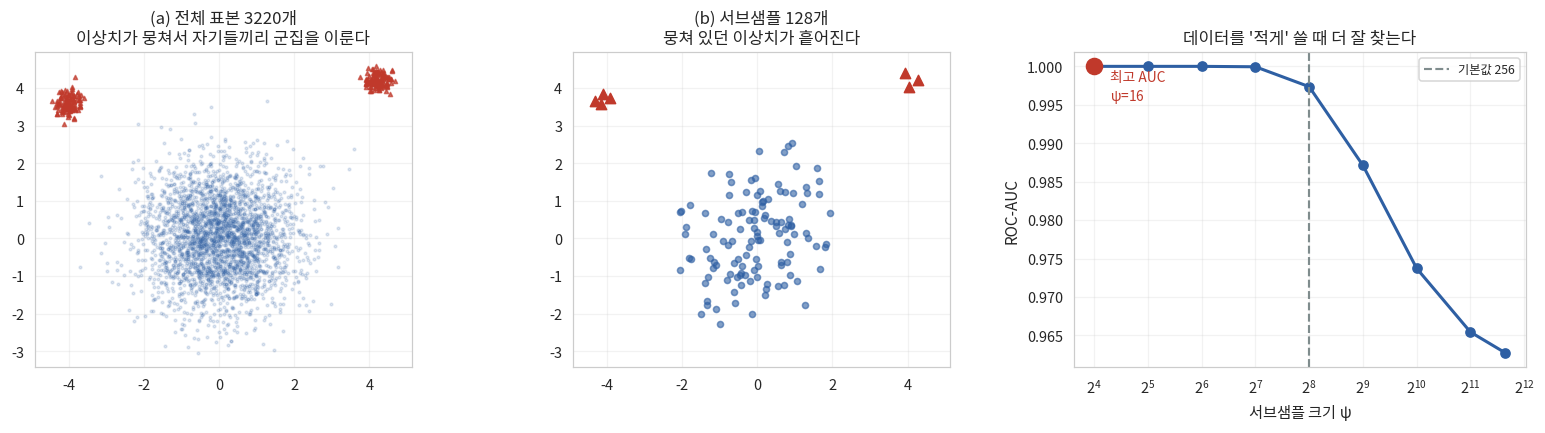

서브샘플 크기별 탐지 성능
----------------------------------------
 서브샘플 크기  ROC-AUC
      16   1.0000
      32   1.0000
      64   1.0000
     128   0.9999
     256   0.9974
     512   0.9871
    1024   0.9737
    2048   0.9654
    3220   0.9627



In [ ]:
# ============================================================
# 2-9. 서브샘플링이 마스킹을 해소한다
# ============================================================
r = np.random.default_rng(17)
# 이상치가 '뭉쳐서' 존재하는 상황 (마스킹이 일어나기 좋은 배치)
Xn2 = r.normal([0, 0], 1.0, (3000, 2))
clump1 = r.normal([4.2, 4.2], 0.18, (110, 2))
clump2 = r.normal([-4.0, 3.6], 0.18, (110, 2))
Xm = np.vstack([Xn2, clump1, clump2])
ym = np.concatenate([np.zeros(len(Xn2), bool), np.ones(220, bool)])

sizes = [16, 32, 64, 128, 256, 512, 1024, 2048, len(Xm)]
aucs = []
for s in sizes:
    m = IsolationForest(n_estimators=200, max_samples=min(s, len(Xm)),
                        random_state=0).fit(Xm)
    aucs.append(roc_auc_score(ym, -m.score_samples(Xm)))

fig, axes = panel(1, 3, w=4.8, h=3.9)

axes[0].scatter(Xm[~ym, 0], Xm[~ym, 1], s=3, alpha=.15, color=C["blue"])
axes[0].scatter(Xm[ym, 0], Xm[ym, 1], s=7, alpha=.7, color=C["red"], marker="^")
axes[0].set_title(f"(a) 전체 표본 {len(Xm)}개\n이상치가 뭉쳐서 자기들끼리 군집을 이룬다")
axes[0].set_aspect("equal")

sel = np.random.default_rng(0).choice(len(Xm), 128, replace=False)
axes[1].scatter(Xm[sel][~ym[sel], 0], Xm[sel][~ym[sel], 1], s=16, alpha=.6, color=C["blue"])
axes[1].scatter(Xm[sel][ym[sel], 0], Xm[sel][ym[sel], 1], s=45, color=C["red"], marker="^")
axes[1].set_xlim(axes[0].get_xlim()); axes[1].set_ylim(axes[0].get_ylim())
axes[1].set_title("(b) 서브샘플 128개\n뭉쳐 있던 이상치가 흩어진다")
axes[1].set_aspect("equal")

axes[2].plot(sizes, aucs, "o-", color=C["blue"], lw=2, ms=6)
best = int(np.argmax(aucs))
axes[2].scatter([sizes[best]], [aucs[best]], s=110, color=C["red"], zorder=5)
axes[2].annotate(f"최고 AUC\n$\\psi$={sizes[best]}", (sizes[best], aucs[best]),
                 textcoords="offset points", xytext=(10, -22), fontsize=9, color=C["red"])
axes[2].axvline(256, color=C["gray"], ls="--", lw=1.4, label="기본값 256")
axes[2].set_xscale("log", base=2)
axes[2].set_xlabel("서브샘플 크기 $\\psi$"); axes[2].set_ylabel("ROC-AUC")
axes[2].set_title("데이터를 '적게' 쓸 때 더 잘 찾는다")
axes[2].legend(fontsize=8)

fig.tight_layout()
plt.show()

show_table(pd.DataFrame({"서브샘플 크기": sizes, "ROC-AUC": aucs}),
           "서브샘플 크기별 탐지 성능", "{:.4f}")

## 데이터를 적게 쓸 때 더 잘 찾습니다

머신러닝에서 보기 드문 현상입니다. 보통은 데이터가 많을수록 좋은데 여기서는 반대예요.
오른쪽 그래프를 보면 AUC가 $\psi$ 가 작을 때 높다가 전체 표본을 쓰면 오히려 떨어집니다.

이유는 왼쪽 두 그림을 비교하면 바로 보입니다.
전체 표본에서는 이상치 220개가 두 개의 작은 덩어리를 이루고 있습니다.
덩어리를 격리하려면 분할이 여러 번 필요하고, 개별 이상치 입장에서도 주변에 이웃이 있으니 깊이가 깊어집니다.
이상치가 이상치가 아니게 되는 거죠. 앞에서 본 마스킹입니다.
서브샘플 128개에서는 그 덩어리가 해체되어 몇 개의 외딴 점이 되고, 쉽게 격리됩니다.

확률로 확인해 보면 이상치가 전체의 6.9%니까 128개를 뽑을 때 이상치의 기댓값이 약 9개입니다.
원래 110개씩 뭉쳐 있던 것이 뽑고 나면 서너 개로 흩어지는 셈입니다.

## 서브샘플링은 타협이 아니라 설계입니다

대부분의 방법에서 서브샘플링은 성능 손해를 감수하고 속도를 얻는 선택입니다.
Isolation Forest에서는 속도와 성능을 동시에 얻습니다. 논문이 $\psi = 256$ 을 기본값으로 제안한 이유죠.

계산 복잡도를 보면 의미가 더 분명해집니다.
학습이 $O(t\,\psi\log\psi)$, 예측이 $O(t\,n\log\psi)$ 인데,
$\psi$ 가 256으로 고정이므로 학습 시간이 데이터 크기 $n$ 과 무관합니다.
LOF의 $O(n^2)$ 과 비교하면 차원이 다릅니다.

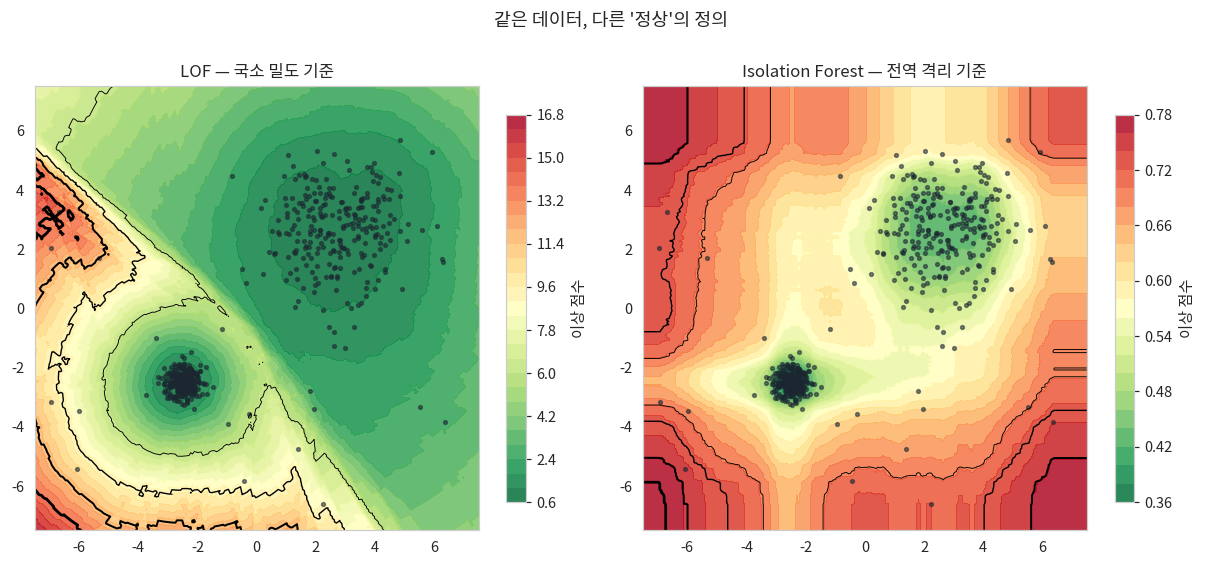

계산 시간 비교 (2차원 데이터)
----------------------------------------------------
n =   1000   LOF   0.005s   |   iForest   0.108s   |   배율  0.04x
n =   5000   LOF   0.020s   |   iForest   0.134s   |   배율  0.15x
n =  20000   LOF   0.094s   |   iForest   0.236s   |   배율  0.40x


In [ ]:
# ============================================================
# 2-10. LOF vs Isolation Forest — 결정 경계와 계산 시간
# ============================================================
import time

r = np.random.default_rng(23)
Xc = np.vstack([
    r.normal([-2.5, -2.5], 0.32, (250, 2)),   # 빽빽한 군집
    r.normal([2.8, 2.8], 1.25, (250, 2)),     # 성긴 군집
    r.uniform(-7, 7, (25, 2)),                # 흩어진 이상치
])

fig, axes = panel(1, 2, w=5.6, h=5.0)
lim = (-7.5, 7.5)
gx = np.linspace(*lim, 260); gy = np.linspace(*lim, 260)
GX, GY = np.meshgrid(gx, gy); G = np.column_stack([GX.ravel(), GY.ravel()])

lof_m = LocalOutlierFactor(n_neighbors=25, novelty=True).fit(Xc)
Zl = (-lof_m.score_samples(G)).reshape(GX.shape)
if_m = IsolationForest(n_estimators=300, max_samples=256, random_state=0).fit(Xc)
Zi = (-if_m.score_samples(G)).reshape(GX.shape)

for ax, Z, title, lev in [
    (axes[0], Zl, "LOF — 국소 밀도 기준", np.percentile(Zl, [70, 85, 95, 99])),
    (axes[1], Zi, "Isolation Forest — 전역 격리 기준", np.percentile(Zi, [70, 85, 95, 99])),
]:
    im = ax.contourf(GX, GY, Z, levels=25, cmap="RdYlGn_r", alpha=.85)
    ax.contour(GX, GY, Z, levels=lev, colors="k", linewidths=[.6, .9, 1.3, 1.8])
    ax.scatter(Xc[:, 0], Xc[:, 1], s=6, color=C["dark"], alpha=.55)
    ax.set_title(title); ax.set_aspect("equal"); ax.grid(False)
    plt.colorbar(im, ax=ax, shrink=.8, label="이상 점수")

fig.suptitle("같은 데이터, 다른 '정상'의 정의", y=1.01, fontsize=12)
fig.tight_layout()
plt.show()

# 계산 시간 비교
print("계산 시간 비교 (2차원 데이터)")
print("-" * 52)
for n in [1000, 5000, 20000]:
    Xt = np.random.default_rng(0).normal(0, 1, (n, 2))
    t0 = time.perf_counter(); LocalOutlierFactor(n_neighbors=20).fit_predict(Xt)
    t_lof = time.perf_counter() - t0
    t0 = time.perf_counter(); IsolationForest(n_estimators=100, random_state=0).fit(Xt).score_samples(Xt)
    t_if = time.perf_counter() - t0
    print(f"n = {n:6d}   LOF {t_lof:7.3f}s   |   iForest {t_if:7.3f}s   |   배율 {t_lof/t_if:5.2f}x")

## 두 알고리즘을 나란히 놓고 보면

LOF 쪽에서는 빽빽한 군집과 성긴 군집 각각을 따라 낮은 점수 영역이 형성됩니다.
성긴 군집의 낮은 영역이 더 넓은데, LOF가 "이 동네는 원래 성기다"를 인정했다는 뜻입니다.

Isolation Forest 쪽에서는 두 군집을 아우르는 하나의 넓은 정상 영역이 만들어집니다.
군집 사이의 빈 공간도 상대적으로 낮은 점수를 받고요. 전역적인 시야로 보기 때문입니다.
그래서 빽빽한 군집 바로 옆에 놓인 점은 LOF가 잡고 iForest는 놓칠 수 있습니다. 앞에서 본 $a_1$ 이 그 경우죠.

계산 시간 출력을 보면 $n$ 이 커질수록 배율이 벌어집니다.
LOF는 $O(n^2)$ 에 가깝게 늘어나고 iForest는 거의 선형입니다.
데이터가 수십만 건을 넘어가면 LOF는 현실적으로 쓸 수 없습니다.

## 선택 지침

| | LOF | Isolation Forest |
|---|---|---|
| 핵심 발상 | 주변 밀도 대비 내 밀도의 비율 | 무작위 분할로 격리하기까지의 깊이 |
| 점수 기준선 | 1 (상한 없음) | 0.5 (상한 1) |
| 국소성 | 로컬. 밀도가 다른 군집에 강함 | 전역. 로컬 이상치에 약함 |
| 거리 사용 | 씀. 스케일링 필수 | 안 씀. 단조변환에 불변 |
| 복잡도 | $O(n^2)$ | $O(t\,\psi\log\psi)$, $n$ 과 무관 |
| 고차원 | 거리 집중으로 붕괴 | 비교적 견고 |
| 주 약점 | 계산량, 차원의 저주 | 로컬 밀도 무시, 축 정렬 편향 |

데이터가 크면 Isolation Forest부터 시작하세요. 빠르고 스케일링도 필요 없습니다.
밀도가 다른 군집이 섞여 있다는 걸 알고 있으면 LOF를 씁니다.
둘 다 돌려서 공통으로 지목한 점은 신뢰도가 높고,
한쪽만 지목한 점을 들여다보면 데이터 구조를 이해하게 됩니다.

마지막으로 `contamination` 파라미터를 반드시 짚고 넘어가야 합니다.
두 클래스 모두 이 파라미터를 갖는데, 데이터의 몇 퍼센트가 이상치인가라는 가정입니다.
데이터에서 학습되는 값이 아니라 여러분이 주입하는 가정이라는 점이 중요합니다.
실제 이상 비율이 0.1%인데 `contamination=0.1`로 두면 정상 데이터의 10%가 강제로 이상 판정을 받습니다.
비지도 방법이라 알고리즘이 이 실수를 알려주지 않습니다.

---

# 3부. 전처리가 성능을 얼마나 바꾸는가

여기까지는 전처리 그 자체를 들여다봤습니다. 이제 성적표를 확인할 차례입니다.

실험 설계는 앞과 같은 신의 시점을 활용합니다.
먼저 깨끗한 원본으로 모델을 학습해서 성능의 상한을 확인합니다. 이론적 하한은 $\sigma = 26.0$ 이죠.
같은 데이터에 결측과 이상치를 주입하고, 여러 전처리 전략으로 각각 처리한 다음 같은 모델로 성능을 잽니다.
시험 데이터는 언제나 깨끗한 원본을 씁니다. 그래야 전처리 전략만의 효과를 분리할 수 있습니다.

한 가지 규칙을 반드시 지킵니다. 모든 전처리는 파이프라인 안에서 훈련 데이터로만 `fit` 합니다.
편의의 문제가 아니라 정확성의 문제입니다.
전체 데이터로 대치기를 학습하면 시험 데이터의 정보가 훈련 과정에 새어 들어갑니다.
3-7절에서 이 누수가 성능을 얼마나 부풀리는지 직접 측정합니다.

참고로 이 노트북에서는 모델을 Ridge 하나로 고정합니다. 전처리 효과만 떼어 보려는 것이고,
모델 자체를 비교하는 작업은 두 번째 노트북에서 따로 다룹니다.

훈련용 오염 데이터 요약
----------------------------------------------
      area  rooms    age  dist   floor  price
결측률  0.208    0.0  0.204   0.0  0.1245    0.0

주입한 이상치 행: 100개 (5.0%)
area 최댓값: 원본 135.3 → 오염 후 1259.0
price 범위: 원본 [-34, 811] → 오염 후 [-88, 847]


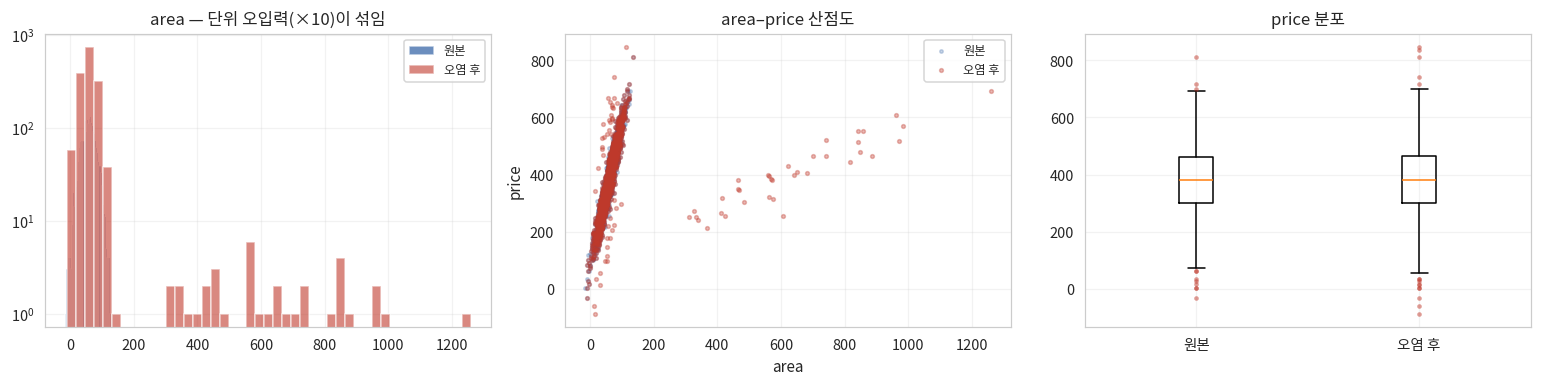

In [ ]:
# ============================================================
# 3-1. 오염된 훈련 데이터 만들기
# ============================================================
def contaminate(df, miss_rate=0.20, out_rate=0.05, out_strength=8.0, seed=0):
    r = np.random.default_rng(seed)
    out = df.copy()
    n = len(out)

    # (A) 결측 주입 — 변수마다 다른 메커니즘
    out.loc[r.random(n) < miss_rate, "area"] = np.nan                      # MCAR
    p = sigmoid(1.6 * stats.zscore(df["dist"].to_numpy()))                 # MAR (dist 의존)
    p = p * (miss_rate / p.mean())
    out.loc[r.random(n) < np.clip(p, 0, 1), "age"] = np.nan
    out.loc[r.random(n) < miss_rate * 0.6, "floor"] = np.nan               # MCAR (무관 변수)

    # (B) 이상치 주입 — 측정/입력 오류를 흉내
    k = int(n * out_rate)
    idx = r.choice(n, k, replace=False)
    half = k // 2
    # 단위 오입력: 면적을 10배로
    out.loc[out.index[idx[:half]], "area"] = out.loc[out.index[idx[:half]], "area"] * 10
    # 센서 오류: 타깃에 큰 잡음
    out.loc[out.index[idx[half:]], "price"] = (
        out.loc[out.index[idx[half:]], "price"]
        + r.choice([-1, 1], k - half) * out_strength * TRUE_SIGMA
    )
    out_flag = np.zeros(n, bool); out_flag[idx] = True
    return out, out_flag


dirty, dirty_out_flag = contaminate(clean, seed=101)

print("훈련용 오염 데이터 요약")
print("-" * 46)
print(dirty[FEATURES + [TARGET]].isna().mean().rename("결측률").to_frame().T.to_string())
print(f"\n주입한 이상치 행: {dirty_out_flag.sum()}개 ({dirty_out_flag.mean():.1%})")
print(f"area 최댓값: 원본 {clean['area'].max():.1f} → 오염 후 {dirty['area'].max():.1f}")
print(f"price 범위: 원본 [{clean['price'].min():.0f}, {clean['price'].max():.0f}] "
      f"→ 오염 후 [{dirty['price'].min():.0f}, {dirty['price'].max():.0f}]")

fig, axes = panel(1, 3, w=4.7, h=3.6)
axes[0].hist(clean["area"], bins=45, alpha=.7, color=C["blue"], label="원본")
axes[0].hist(dirty["area"].dropna(), bins=45, alpha=.6, color=C["red"], label="오염 후")
axes[0].set_yscale("log"); axes[0].set_title("area — 단위 오입력(×10)이 섞임")
axes[0].legend(fontsize=8)

axes[1].scatter(clean["area"], clean["price"], s=5, alpha=.25, color=C["blue"], label="원본")
axes[1].scatter(dirty["area"], dirty["price"], s=6, alpha=.35, color=C["red"], label="오염 후")
axes[1].set_xlabel("area"); axes[1].set_ylabel("price")
axes[1].set_title("area–price 산점도"); axes[1].legend(fontsize=8)

axes[2].boxplot([clean["price"], dirty["price"]],
                flierprops=dict(marker="o", ms=3, mfc=C["red"], mec="none", alpha=.5))
axes[2].set_xticks([1, 2], ["원본", "오염 후"])
axes[2].set_title("price 분포")
fig.tight_layout()
plt.show()

In [ ]:
# ============================================================
# 3-2. 전처리 전략 9종 × 회귀 성능
# ============================================================
# 시험 데이터는 언제나 '깨끗한 원본'
tr_idx, te_idx = train_test_split(np.arange(len(clean)), test_size=0.3, random_state=0)
X_te = clean.iloc[te_idx][FEATURES]
y_te = clean.iloc[te_idx][TARGET]

X_tr_dirty = dirty.iloc[tr_idx][FEATURES]
y_tr_dirty = dirty.iloc[tr_idx][TARGET]
X_tr_clean = clean.iloc[tr_idx][FEATURES]
y_tr_clean = clean.iloc[tr_idx][TARGET]


def iqr_mask(frame, cols, k=1.5):
    keep = np.ones(len(frame), bool)
    for c in cols:
        v = frame[c].to_numpy(dtype=float)
        ok = np.isfinite(v)
        if ok.sum() < 10:
            continue
        q1, q3 = np.nanpercentile(v, [25, 75]); iqr = q3 - q1
        keep &= ~(ok & ((v < q1 - k * iqr) | (v > q3 + k * iqr)))
    return keep


def run_strategy(name, Xtr, ytr, model=None, imputer=None, drop_rows=None, scale=True):
    Xtr = Xtr.copy(); ytr = ytr.copy()
    if drop_rows is not None:
        Xtr, ytr = Xtr.loc[drop_rows], ytr.loc[drop_rows]
    steps = []
    if imputer is not None:
        steps.append(("imp", imputer))
    if scale:
        steps.append(("sc", StandardScaler()))
    steps.append(("m", model if model is not None else Ridge(alpha=1.0)))
    pipe = Pipeline(steps)
    pipe.fit(Xtr, ytr)
    rec = summarize(name, y_te, pipe.predict(X_te))
    rec["훈련 행 수"] = len(Xtr)
    return rec, pipe


results, pipes = [], {}

# 0) 상한: 오염이 전혀 없는 경우
rec, p = run_strategy("0. 오염 없음 (성능 상한)", X_tr_clean, y_tr_clean)
results.append(rec); pipes[rec["전략"]] = p

# 1) 결측 행 전부 삭제
keep = X_tr_dirty.notna().all(axis=1)
rec, p = run_strategy("1. dropna (완전제거)", X_tr_dirty, y_tr_dirty,
                      drop_rows=X_tr_dirty.index[keep])
results.append(rec); pipes[rec["전략"]] = p

# 2) 0으로 채우기
rec, p = run_strategy("2. fillna(0)", X_tr_dirty, y_tr_dirty,
                      imputer=SimpleImputer(strategy="constant", fill_value=0))
results.append(rec); pipes[rec["전략"]] = p

# 3) 평균 대체
rec, p = run_strategy("3. 평균 대체", X_tr_dirty, y_tr_dirty,
                      imputer=SimpleImputer(strategy="mean"))
results.append(rec); pipes[rec["전략"]] = p

# 4) 중앙값 대체
rec, p = run_strategy("4. 중앙값 대체", X_tr_dirty, y_tr_dirty,
                      imputer=SimpleImputer(strategy="median"))
results.append(rec); pipes[rec["전략"]] = p

# 5) KNN 대치
rec, p = run_strategy("5. KNN 대치(k=5)", X_tr_dirty, y_tr_dirty,
                      imputer=KNNImputer(n_neighbors=5))
results.append(rec); pipes[rec["전략"]] = p

# 6) MICE
rec, p = run_strategy("6. MICE (IterativeImputer)", X_tr_dirty, y_tr_dirty,
                      imputer=IterativeImputer(estimator=BayesianRidge(),
                                               max_iter=15, random_state=0))
results.append(rec); pipes[rec["전략"]] = p

# 7) 중앙값 대체 + IQR로 이상치 행 제거
keep_iqr = iqr_mask(pd.concat([X_tr_dirty, y_tr_dirty], axis=1), FEATURES + [TARGET])
rec, p = run_strategy("7. 중앙값 대체 + IQR 행 제거", X_tr_dirty, y_tr_dirty,
                      imputer=SimpleImputer(strategy="median"),
                      drop_rows=X_tr_dirty.index[keep_iqr])
results.append(rec); pipes[rec["전략"]] = p

# 8) MICE + Isolation Forest로 이상치 제거
tmp = SimpleImputer(strategy="median").fit_transform(pd.concat([X_tr_dirty, y_tr_dirty], axis=1))
iso_tr = IsolationForest(n_estimators=300, contamination=0.06, random_state=0).fit(tmp)
keep_iso = iso_tr.predict(tmp) == 1
rec, p = run_strategy("8. MICE + IsolationForest 제거", X_tr_dirty, y_tr_dirty,
                      imputer=IterativeImputer(estimator=BayesianRidge(),
                                               max_iter=15, random_state=0),
                      drop_rows=X_tr_dirty.index[keep_iso])
results.append(rec); pipes[rec["전략"]] = p

# 9) MICE + 로버스트 회귀 (제거 대신 손실 함수를 바꾼다)
rec, p = run_strategy("9. MICE + Huber 회귀 (제거 없음)", X_tr_dirty, y_tr_dirty,
                      imputer=IterativeImputer(estimator=BayesianRidge(),
                                               max_iter=15, random_state=0),
                      model=HuberRegressor(epsilon=1.35, alpha=1e-4, max_iter=500))
results.append(rec); pipes[rec["전략"]] = p

perf = pd.DataFrame(results)
show_table(perf, "전처리 전략별 회귀 성능 (시험 데이터는 깨끗한 원본)", "{:.3f}")

전처리 전략별 회귀 성능 (시험 데이터는 깨끗한 원본)
----------------------------------------
                          전략   RMSE    MAE    R2  훈련 행 수
            0. 오염 없음 (성능 상한) 25.841 20.326 0.952    1400
            1. dropna (완전제거) 62.102 49.748 0.723     767
                2. fillna(0) 63.866 51.249 0.707    1400
                    3. 평균 대체 63.041 50.584 0.714    1400
                   4. 중앙값 대체 63.049 50.576 0.714    1400
              5. KNN 대치(k=5) 62.825 50.222 0.716    1400
  6. MICE (IterativeImputer) 62.498 49.967 0.719    1400
        7. 중앙값 대체 + IQR 행 제거 33.549 26.997 0.919    1332
8. MICE + IsolationForest 제거 48.107 38.362 0.834    1316
  9. MICE + Huber 회귀 (제거 없음) 62.699 50.097 0.717    1400



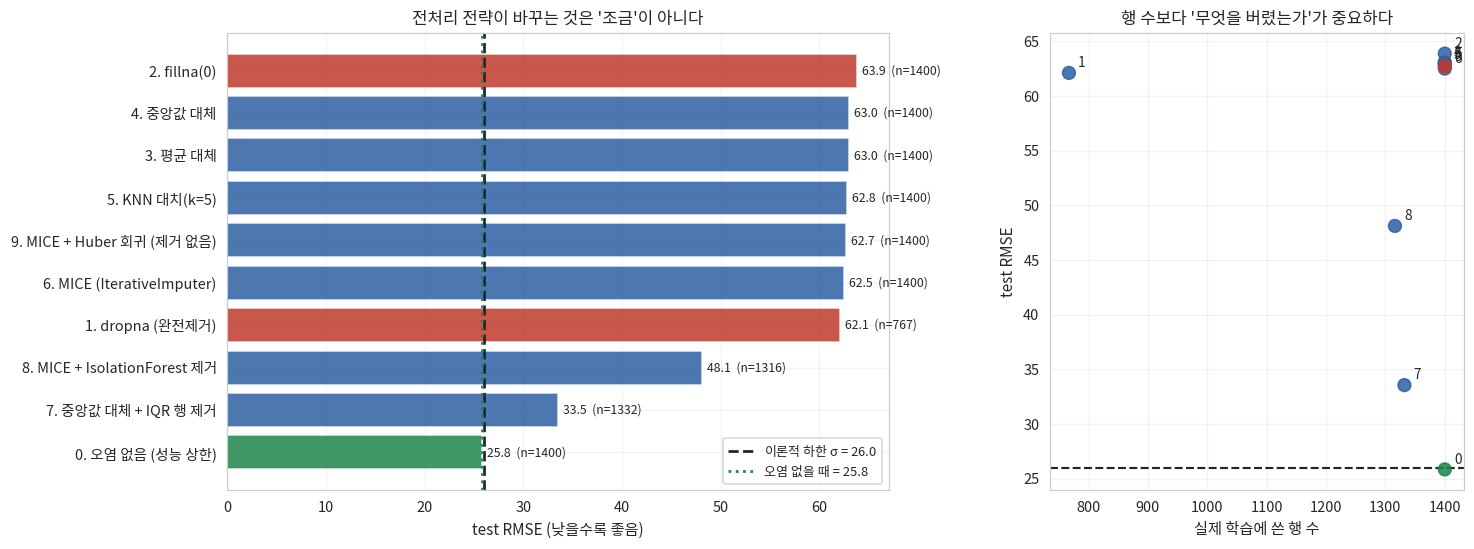

전처리 전략에 따른 회귀계수 추정 (원래 스케일로 환산)
----------------------------------------
 area  rooms    age   dist  floor                         전략
4.600  9.000 -2.200 -0.028  1.100                      진짜 계수
4.554  9.670 -2.122 -0.026  1.079           0. 오염 없음 (성능 상한)
0.104 97.670 -1.002 -0.056  0.489               2. fillna(0)
0.117 97.313 -1.852 -0.042  0.784                   3. 평균 대체
0.127 96.188 -2.671 -0.020  0.788 6. MICE (IterativeImputer)
0.116 95.533 -2.219 -0.028  0.985 9. MICE + Huber 회귀 (제거 없음)



In [ ]:
# ============================================================
# 3-3. 성능 비교 시각화
# ============================================================
fig = plt.figure(figsize=(14.5, 5.4))
gs = fig.add_gridspec(1, 2, width_ratios=[1.6, 1.0], wspace=0.3)

ax = fig.add_subplot(gs[0])
order = perf.sort_values("RMSE", ascending=True)
colors = []
for name in order["전략"]:
    if name.startswith("0."):
        colors.append(C["green"])
    elif name.startswith(("2.", "1.")):
        colors.append(C["red"])
    else:
        colors.append(C["blue"])
bars = ax.barh(order["전략"], order["RMSE"], color=colors, alpha=.85)
ax.axvline(TRUE_SIGMA, color=C["dark"], ls="--", lw=1.8,
           label=f"이론적 하한 $\\sigma$ = {TRUE_SIGMA}")
ax.axvline(perf.loc[0, "RMSE"], color=C["green"], ls=":", lw=1.8,
           label=f"오염 없을 때 = {perf.loc[0,'RMSE']:.1f}")
ax.set_xlabel("test RMSE (낮을수록 좋음)")
ax.set_title("전처리 전략이 바꾸는 것은 '조금'이 아니다")
ax.legend(fontsize=8.5, loc="lower right")
for i, (v, n) in enumerate(zip(order["RMSE"], order["훈련 행 수"])):
    ax.text(v + 0.5, i, f"{v:.1f}  (n={n})", va="center", fontsize=8)

ax2 = fig.add_subplot(gs[1])
ax2.scatter(perf["훈련 행 수"], perf["RMSE"], s=70, c=colors, alpha=.85, zorder=4)
for _, row in perf.iterrows():
    ax2.annotate(row["전략"].split(".")[0], (row["훈련 행 수"], row["RMSE"]),
                 textcoords="offset points", xytext=(6, 4), fontsize=9)
ax2.axhline(TRUE_SIGMA, color=C["dark"], ls="--", lw=1.4)
ax2.set_xlabel("실제 학습에 쓴 행 수"); ax2.set_ylabel("test RMSE")
ax2.set_title("행 수보다 '무엇을 버렸는가'가 중요하다")

plt.show()

# 계수 추정이 얼마나 왜곡되었는가
coef_rows = []
for name in ["0. 오염 없음 (성능 상한)", "2. fillna(0)", "3. 평균 대체",
             "6. MICE (IterativeImputer)", "9. MICE + Huber 회귀 (제거 없음)"]:
    p = pipes[name]
    sc = p.named_steps["sc"]
    beta_scaled = p.named_steps["m"].coef_
    beta_orig = beta_scaled / sc.scale_          # 표준화 되돌리기
    coef_rows.append(dict(zip(FEATURES, beta_orig), 전략=name))
coef_df = pd.DataFrame(coef_rows)[["전략"] + FEATURES]
true_row = pd.DataFrame([dict(zip(FEATURES, [TRUE_BETA[f] for f in FEATURES]), 전략="진짜 계수")])
coef_df = pd.concat([true_row, coef_df], ignore_index=True)
show_table(coef_df, "전처리 전략에 따른 회귀계수 추정 (원래 스케일로 환산)", "{:.3f}")

## 숫자부터 보겠습니다

가장 나쁜 전략과 가장 좋은 전략의 test RMSE 차이가 63.9와 25.8입니다.
모델은 하나도 바꾸지 않았습니다. 전처리만 바꿨습니다.

`fillna(0)`이 최악입니다. `area`가 결측이라고 0을 넣으면 모델은 면적 0제곱미터짜리 집을 학습합니다.
존재하지 않는 데이터를 만들어 넣은 것이고, 그 거짓 패턴이 회귀선을 통째로 비틀어 버립니다.
계수 표에서 `area` 계수가 진짜 값 4.6에서 얼마나 벗어나 있는지 확인해 보세요.
`fillna(0)`은 0이 그 변수에서 실제로 의미 있는 값일 때만 정당합니다.
재고 수량이라면 0이 "재고 없음"으로 말이 되지만 면적이나 나이는 그렇지 않습니다.

`dropna`는 오른쪽 산점도에서 왼쪽 끝, 즉 행 수가 가장 적은 곳에 있는데 RMSE가 특별히 좋지도 않습니다.
데이터를 많이 버렸는데 그 대가로 얻은 것이 별로 없죠.

이상치를 제거한 7번과 8번 전략이 눈에 띄게 좋습니다.
이상치를 그대로 두면 점 하나가 회귀선을 통째로 끌고 갑니다. 지난 OT에서 확인한 그대로입니다.
제곱손실은 오차를 제곱하니까 오차 20인 점 하나의 손실이 400이고,
그게 정상 점 수십 개의 손실 합을 능가해 버립니다.

## Huber가 기대만큼 작동하지 않은 이유

9번 Huber 회귀가 62.7로, 제거 전략인 33.5에 한참 못 미칩니다. 이 결과가 오히려 중요합니다.

Huber 손실은 이렇게 생겼습니다.

$$
\ell_\delta(e) = \begin{cases}\tfrac12 e^2 & |e|\le\delta\\ \delta(|e|-\tfrac12\delta) & |e|>\delta\end{cases}
$$

작은 오차는 제곱손실처럼, 큰 오차는 절대손실처럼 다룹니다. 첫 OT에서 배운 그대로죠.
그런데 Huber가 보호해 주는 것은 $y$ 방향의 이상치뿐입니다.

우리가 주입한 이상치는 두 종류였습니다.
`price`에 큰 잡음을 더한 것은 $y$ 방향 이상치라 Huber가 잘 막아냅니다.
문제는 `area`를 10배로 만든 쪽입니다. 이건 $x$ 방향 이상치, 즉 지렛대점입니다.

지렛대점은 손실 함수를 바꿔도 막을 수 없습니다. 그 점의 잔차가 크지 않기 때문입니다.
$x$ 가 극단적으로 크면 회귀선이 그 점을 향해 끌려가고, 끌려간 뒤에는 잔차가 작아집니다.
작은 잔차는 Huber의 제곱 구간 안에 있으니 Huber 입장에서는 아무 문제 없는 점으로 보이죠.
마스킹의 회귀 버전이라고 생각하시면 됩니다. 이상치가 모델을 자기 쪽으로 끌어당겨 스스로를 숨깁니다.

그래서 대응이 갈립니다.
$y$ 방향 이상치에는 Huber나 분위수 회귀 같은 로버스트 손실이 효과적이고,
$x$ 방향 지렛대점에는 탐지 후 제거나 RANSAC, 로버스트 공분산이 필요합니다.
3-5절에서는 $y$ 방향만 주입해서 이 대비를 다시 확인합니다. 거기서는 Huber가 확실히 이깁니다.

## 제거냐 로버스트 손실이냐

이상치가 명백한 오류, 그러니까 단위 오입력이나 센서 고장이라면 제거가 맞습니다. 그건 데이터가 아니니까요.
진짜 현상일 수도 있다면 로버스트 손실이 안전합니다. 정보를 버리지 않으면서 영향만 줄이거든요.
다만 방금 봤듯이 로버스트 손실은 $x$ 방향 이상치를 막아주지 않으니 탐지는 어차피 필요합니다.
실무에서는 제거하기 전에 왜 이 값이 나왔는지를 반드시 확인해야 하고, 그게 안 되면 로버스트 쪽이 낫습니다.

한 가지 더. `dropna`가 평균 대체보다 조금 나은데,
결측 행을 버리는 과정에서 이상치 행도 일부 함께 버려졌기 때문입니다.
우연히 얻은 이득이지 전략의 우수함이 아닙니다.
훈련 행이 1400에서 767로 절반 가까이 줄었다는 점도 같이 보세요.

마지막으로 계수 표가 성능 표보다 더 많은 것을 말해준다는 점을 강조하고 싶습니다.
RMSE만 보면 몇몇 전략이 비슷해 보이는데, 계수를 보면 어떤 전략이 구조를 제대로 복원했는지가 드러납니다.
예측만 할 거면 RMSE로 충분하지만 해석을 할 거라면 계수를 봐야 합니다.

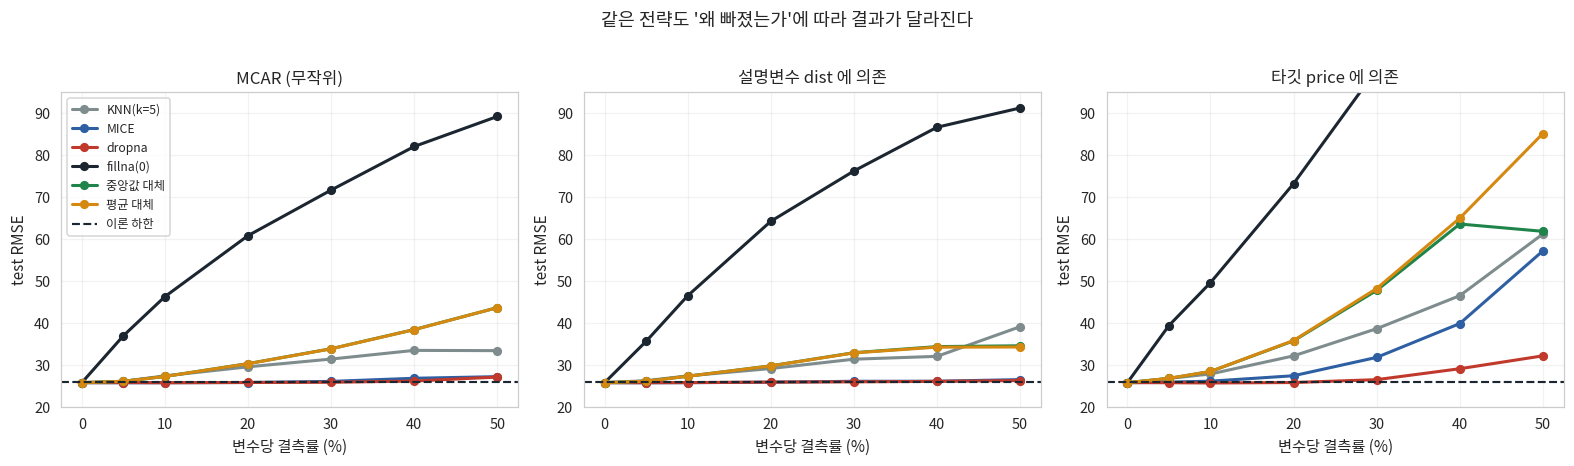

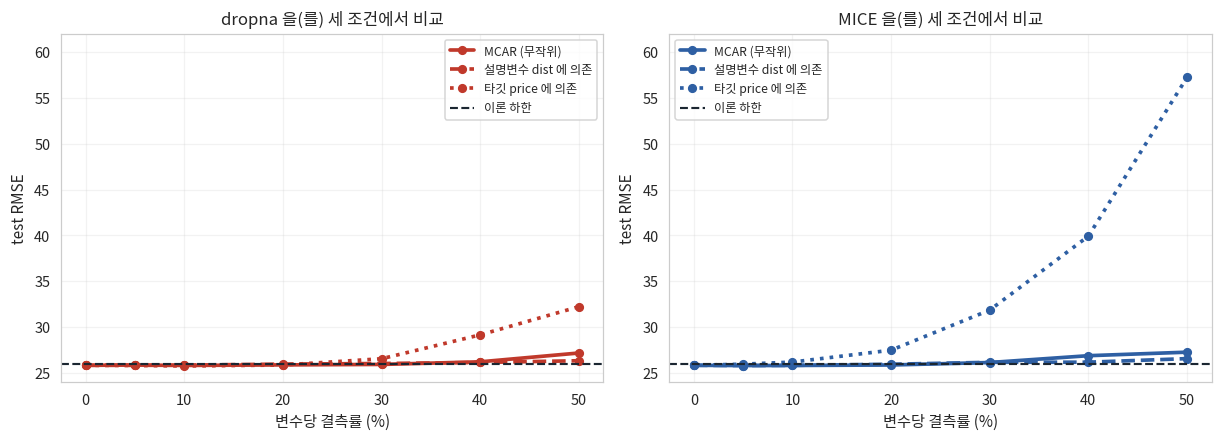

[MCAR (무작위)] 평균 test RMSE
----------------------------------------
 결측률  KNN(k=5)  MICE  dropna  fillna(0)  중앙값 대체  평균 대체
0.00     25.84 25.84   25.84      25.84   25.84  25.84
0.05     26.17 25.81   25.87      37.01   26.16  26.16
0.10     27.46 25.82   25.83      46.33   27.32  27.32
0.20     29.61 25.87   25.89      60.85   30.37  30.35
0.30     31.46 26.14   25.94      71.70   33.92  33.90
0.40     33.53 26.89   26.22      82.07   38.49  38.46
0.50     33.46 27.27   27.18      89.22   43.70  43.71

[설명변수 dist 에 의존] 평균 test RMSE
----------------------------------------
 결측률  KNN(k=5)  MICE  dropna  fillna(0)  중앙값 대체  평균 대체
0.00     25.84 25.84   25.84      25.84   25.84  25.84
0.05     26.32 25.81   25.83      35.69   26.19  26.19
0.10     27.45 25.83   25.86      46.54   27.38  27.36
0.20     29.21 25.96   25.97      64.26   29.85  29.83
0.30     31.43 26.17   26.04      76.24   32.97  32.93
0.40     32.10 26.18   26.15      86.65   34.43  34.30
0.50     39.17 26.57   26.34      91

In [ ]:
# ============================================================
# 3-4. 결측률을 바꿔가며 — 전략 × 메커니즘
#      결측이 (1) 무작위인가  (2) 다른 설명변수에 의존하는가
#      (3) 타깃 자신에 의존하는가 에 따라 결론이 달라진다.
# ============================================================
from sklearn.base import clone

MISS_COLS = ["area", "age", "floor", "rooms"]
MECHS = {
    "MCAR (무작위)": None,
    "설명변수 dist 에 의존": "dist",
    "타깃 price 에 의존": "price",
}

def make_missing(df, rate, driver, seed):
    r = np.random.default_rng(seed)
    d = df.copy()
    if driver is None:
        for c in MISS_COLS:
            d.loc[r.random(len(d)) < rate, c] = np.nan
        return d
    p = sigmoid(2.0 * stats.zscore(df[driver].to_numpy()))
    p = np.clip(p * (rate / p.mean()), 0, 1)
    for c in MISS_COLS:
        d.loc[r.random(len(d)) < p, c] = np.nan
    return d


STRATS = {
    "dropna": ("drop", None),
    "fillna(0)": ("imp", SimpleImputer(strategy="constant", fill_value=0)),
    "평균 대체": ("imp", SimpleImputer(strategy="mean")),
    "중앙값 대체": ("imp", SimpleImputer(strategy="median")),
    "KNN(k=5)": ("imp", KNNImputer(n_neighbors=5)),
    "MICE": ("imp", IterativeImputer(estimator=BayesianRidge(), max_iter=10, random_state=0)),
}

def sweep(rates, driver, label, reps=3):
    rows = []
    for rate in rates:
        for rep in range(reps):
            d = make_missing(clean, rate, driver, seed=500 + rep)
            Xtr_, ytr_ = d.iloc[tr_idx][FEATURES], d.iloc[tr_idx][TARGET]
            for name, (kind, imp) in STRATS.items():
                try:
                    if kind == "drop":
                        keep_ = Xtr_.notna().all(axis=1)
                        if keep_.sum() < 40:
                            rows.append({"결측률": rate, "전략": name,
                                         "RMSE": np.nan, "조건": label}); continue
                        pipe = Pipeline([("sc", StandardScaler()), ("m", Ridge(1.0))])
                        pipe.fit(Xtr_[keep_], ytr_[keep_])
                    else:
                        pipe = Pipeline([("imp", clone(imp)), ("sc", StandardScaler()),
                                         ("m", Ridge(1.0))])
                        pipe.fit(Xtr_, ytr_)
                    rmse = float(np.sqrt(mean_squared_error(y_te, pipe.predict(X_te))))
                except Exception:
                    rmse = np.nan
                rows.append({"결측률": rate, "전략": name, "RMSE": rmse, "조건": label})
    return pd.DataFrame(rows)


rates_sw = [0.0, 0.05, 0.10, 0.20, 0.30, 0.40, 0.50]
sweeps = {lab: sweep(rates_sw, drv, lab) for lab, drv in MECHS.items()}

palette = {"dropna": C["red"], "fillna(0)": C["dark"], "평균 대체": C["amber"],
           "중앙값 대체": C["green"], "KNN(k=5)": C["gray"], "MICE": C["blue"]}

fig, axes = panel(1, 3, w=4.8, h=4.1)
for ax, (lab, sw) in zip(axes, sweeps.items()):
    piv_ = sw.groupby(["결측률", "전략"])["RMSE"].mean().unstack()
    for col in piv_.columns:
        ax.plot(piv_.index * 100, piv_[col], "o-", lw=2, ms=5,
                color=palette.get(col), label=col)
    ax.axhline(TRUE_SIGMA, color=C["dark"], ls="--", lw=1.4, label="이론 하한")
    ax.set_xlabel("변수당 결측률 (%)"); ax.set_ylabel("test RMSE")
    ax.set_ylim(20, 95); ax.set_title(lab)
axes[0].legend(fontsize=8)
fig.suptitle("같은 전략도 '왜 빠졌는가'에 따라 결과가 달라진다", y=1.02, fontsize=12)
fig.tight_layout()
plt.show()

# dropna vs MICE 를 세 조건에서 직접 비교
fig, axes = panel(1, 2, w=5.6, h=4.1)
styles = {"MCAR (무작위)": "-", "설명변수 dist 에 의존": "--", "타깃 price 에 의존": ":"}
for ax, strat, col in [(axes[0], "dropna", C["red"]), (axes[1], "MICE", C["blue"])]:
    for lab, sw in sweeps.items():
        g_ = sw[sw["전략"] == strat].groupby("결측률")["RMSE"].mean()
        ax.plot(g_.index * 100, g_, styles[lab], color=col, lw=2.4, marker="o", ms=5, label=lab)
    ax.axhline(TRUE_SIGMA, color=C["dark"], ls="--", lw=1.4, label="이론 하한")
    ax.set_xlabel("변수당 결측률 (%)"); ax.set_ylabel("test RMSE")
    ax.set_ylim(24, 62); ax.set_title(f"{strat} 을(를) 세 조건에서 비교")
    ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

for lab, sw in sweeps.items():
    show_table(sw.groupby(["결측률", "전략"])["RMSE"].mean().unstack().reset_index(),
               f"[{lab}] 평균 test RMSE", "{:.2f}")

surv = [make_missing(clean, rt, None, 0).iloc[tr_idx][FEATURES].notna().all(axis=1).mean()
        for rt in rates_sw]
print("MCAR에서 dropna 이후 남는 훈련 행")
for rt, sv in zip(rates_sw, surv):
    print(f"  결측률 {rt:5.0%} -> {sv:6.1%}  ({int(sv*len(tr_idx)):5d}행)   이론값 (1-r)^4 = {(1-rt)**4:6.1%}")

## 교과서보다 한 단계 정확한 결론

`fillna(0)`은 세 조건 모두에서 재앙입니다. 검은 선이 하늘로 치솟죠.
타깃 의존 조건에서는 결측률 50%에 RMSE가 185까지 갑니다. 이론 하한이 26인데 말입니다.
가짜 데이터를 많이 만들어 넣을수록 모델이 가짜를 학습한다는 것,
이것만이 조건과 무관하게 성립하는 유일한 결론입니다.

MCAR에서는 `dropna`가 가장 강하게 나옵니다. 예상과 다르시죠?

MCAR에서 남은 데이터는 여전히 무작위 표본이라 편향이 없습니다.
그리고 대치는 없던 정보를 만들어내지 못합니다.
대치는 추정이고 추정에는 오차가 따르는데, 그 오차가 그대로 특징 행렬에 섞여 들어갑니다.
정리하면 MCAR에서 대치가 주는 것은 행 수뿐이고 그 대가로 잡음을 지불하는 셈입니다.
모델이 단순하고 남은 행이 충분하면 그 거래는 남는 장사가 아닙니다.

## 설명변수에 의존해도 회귀는 멀쩡합니다

두 번째 패널이 첫 번째와 거의 똑같이 생겼습니다. `dropna`가 결측률 50%에서도 26.3으로 버팁니다.

무작위가 아닌데 왜 멀쩡할까요. 우리가 적합하는 것이 조건부 모형이기 때문입니다.
완전제거는 $R=1$ 인 행만 쓰므로 실제로 적합하는 것은 $P(Y \mid X, R=1)$ 인데,
$R$ 이 $X$ 만의 함수라면 $X$ 를 조건으로 건 순간 $R$ 이 $Y$ 에 대해 아무 정보도 추가하지 않습니다.
그래서 $P(Y \mid X, R=1) = P(Y \mid X)$ 가 되고, 표본이 줄어들 뿐 회귀 관계는 그대로 남습니다.

실무에서 의외로 덜 알려진 사실입니다.
"결측이 무작위가 아니면 삭제하면 안 된다"는 흔한 조언은
정확히는 "결측이 타깃과 관계있으면 삭제하면 안 된다"입니다.
설명변수와만 관계있다면 회귀는 살아남습니다.
물론 변수별 평균이나 분포를 보고할 때는 여전히 편향됩니다. 1-3절에서 본 그 편향이죠.

## 타깃에 의존하면 대치가 삭제보다 나빠집니다

세 번째 패널의 결측률 50% 숫자를 보면 `dropna`가 32.2, MICE가 57.2, KNN이 61.2,
평균 대체가 85.2, `fillna(0)`이 184.8입니다.

왜 대치가 더 나쁠까요. 파이프라인 안의 대치기는 설명변수만 봅니다. 타깃 `price`는 볼 수 없습니다.
당연합니다. 예측 시점에는 타깃이 없으니 타깃을 써서 대치하면 그건 누수니까요.

그러니 대치기 입장에서는 결측을 일으킨 원인이 자기가 볼 수 없는 변수입니다.
즉 대치기에게 이 상황은 MNAR입니다.

그러면 이런 연쇄가 일어납니다.
대치 모형은 관측된 행에서 학습되는데 그 행들은 `price`가 낮은 쪽으로 치우쳐 있습니다.
그래서 결측 행, 즉 비싼 집의 `area`를 체계적으로 작게 채웁니다.
모델은 면적은 작은데 가격은 비싼 가짜 데이터를 잔뜩 보게 되고, `area` 계수가 눌리면서 회귀 전체가 비틀립니다.

대치가 편향을 없앤 것이 아니라 새로 만들어 넣은 겁니다.
반면 `dropna`는 정보를 버릴 뿐 가짜를 만들지는 않습니다.
남은 데이터가 잘린 분포라 편향되긴 하지만, 그 편향이 대치가 주입한 편향보다 작습니다.

정리하면 이렇습니다. 대치는 MAR을 가정하고 만들어진 도구입니다. 가정이 깨지면 도움이 아니라 해가 됩니다.
강의에서 "MNAR은 사실상 완전 교정이 불가능하다"고 했던 말의 실물이 이 표입니다.
MNAR에서 할 수 있는 것은 민감도 분석과 결측 지시변수뿐이고,
고급 대치 알고리즘을 쓴다고 해결되는 문제가 아닙니다.

## `dropna`를 언제 써도 되는가

결측이 타깃과 무관하다고 믿을 근거가 있고, 삭제 후에도 표본이 충분히 남고,
변수 개수가 적어서 $(1-r)^p$ 붕괴가 심하지 않을 때입니다.

이 실험은 세 조건을 전부 만족하도록 설계되어 있습니다.
결측을 변수 4개에만 넣었고 모델이 계수 5개짜리 선형회귀고 $n=1400$ 입니다.
출력 맨 아래 생존율 표를 보면 결측률 50%에서도 99행이 남죠.
변수가 50개라면 결측률 5%에서도 생존율이 8%입니다.

그래서 기본값은 대치로 두되 `dropna`를 항상 베이스라인으로 함께 돌려 보시길 권합니다.
대치가 `dropna`를 못 이긴다면 그 대치는 정보를 더한 것이 아니라 잡음이나 편향을 더한 것입니다.

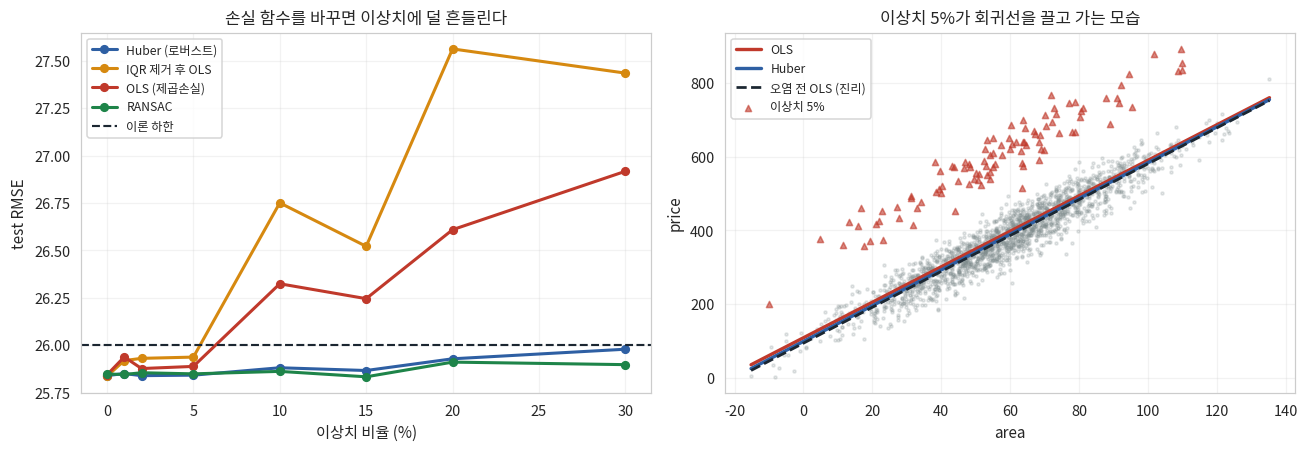

이상치 비율별 평균 test RMSE
----------------------------------------
 이상치 비율  Huber (로버스트)  IQR 제거 후 OLS  OLS (제곱손실)  RANSAC
   0.00         25.84         25.84       25.84   25.85
   0.01         25.85         25.92       25.94   25.85
   0.02         25.84         25.93       25.88   25.85
   0.05         25.84         25.94       25.89   25.85
   0.10         25.88         26.75       26.32   25.86
   0.15         25.87         26.52       26.25   25.83
   0.20         25.93         27.56       26.61   25.91
   0.30         25.98         27.43       26.92   25.90



In [ ]:
# ============================================================
# 3-5. 이상치의 영향 — 비율을 바꿔가며
#      여기서는 '타깃(y) 방향' 이상치만 주입한다.
#      3-3절에서 본 x 방향 지렛대점과의 대비를 확인하기 위해서다.
# ============================================================
def sweep_outliers(rates, strength=8.0, reps=5):
    rows = []
    for rate in rates:
        for rep in range(reps):
            r = np.random.default_rng(700 + rep)
            d = clean.copy()
            k = max(int(len(d) * rate), 0)
            if k > 0:
                idx = r.choice(len(d), k, replace=False)
                d.loc[d.index[idx], "price"] = (d.loc[d.index[idx], "price"]
                                                + r.choice([-1, 1], k) * strength * TRUE_SIGMA)
            Xtr_, ytr_ = d.iloc[tr_idx][FEATURES], d.iloc[tr_idx][TARGET]

            models = {
                "OLS (제곱손실)": LinearRegression(),
                "Huber (로버스트)": HuberRegressor(epsilon=1.35, alpha=1e-4, max_iter=800),
                "RANSAC": RANSACRegressor(random_state=0, min_samples=0.6),
            }
            for mname, m in models.items():
                pipe = Pipeline([("sc", StandardScaler()), ("m", m)])
                try:
                    pipe.fit(Xtr_, ytr_)
                    rmse = float(np.sqrt(mean_squared_error(y_te, pipe.predict(X_te))))
                except Exception:
                    rmse = np.nan
                rows.append({"이상치 비율": rate, "모델": mname, "RMSE": rmse})

            # IQR로 제거한 뒤 OLS
            keep_ = iqr_mask(pd.concat([Xtr_, ytr_], axis=1), FEATURES + [TARGET])
            if keep_.sum() > 50:
                pipe = Pipeline([("sc", StandardScaler()), ("m", LinearRegression())])
                pipe.fit(Xtr_[keep_], ytr_[keep_])
                rows.append({"이상치 비율": rate,
                             "모델": "IQR 제거 후 OLS",
                             "RMSE": float(np.sqrt(mean_squared_error(y_te, pipe.predict(X_te))))})
    return pd.DataFrame(rows)


orates = [0.0, 0.01, 0.02, 0.05, 0.10, 0.15, 0.20, 0.30]
osw = sweep_outliers(orates, reps=4)
opiv = osw.groupby(["이상치 비율", "모델"])["RMSE"].mean().unstack()

fig, axes = panel(1, 2, w=6.0, h=4.2)
pal2 = {"OLS (제곱손실)": C["red"], "Huber (로버스트)": C["blue"],
        "RANSAC": C["green"], "IQR 제거 후 OLS": C["amber"]}
for col in opiv.columns:
    axes[0].plot(opiv.index * 100, opiv[col], "o-", lw=2, ms=5,
                 color=pal2.get(col), label=col)
axes[0].axhline(TRUE_SIGMA, color=C["dark"], ls="--", lw=1.4, label="이론 하한")
axes[0].set_xlabel("이상치 비율 (%)"); axes[0].set_ylabel("test RMSE")
axes[0].set_title("손실 함수를 바꾸면 이상치에 덜 흔들린다")
axes[0].legend(fontsize=8)

# 회귀선이 실제로 어떻게 끌려가는지 (단변량)
r = np.random.default_rng(3)
xs_ = clean["area"].to_numpy(); ys_ = clean["price"].to_numpy()
k = int(len(xs_) * 0.05)
idx = r.choice(len(xs_), k, replace=False)
ys_c = ys_.copy(); ys_c[idx] += 9 * TRUE_SIGMA
grid = np.linspace(xs_.min(), xs_.max(), 100)[:, None]
for m, col, lb in [(LinearRegression(), C["red"], "OLS"),
                   (HuberRegressor(epsilon=1.35), C["blue"], "Huber")]:
    m.fit(xs_[:, None], ys_c)
    axes[1].plot(grid, m.predict(grid), color=col, lw=2.2, label=lb)
m0 = LinearRegression().fit(xs_[:, None], ys_)
axes[1].plot(grid, m0.predict(grid), color=C["dark"], lw=1.8, ls="--", label="오염 전 OLS (진리)")
axes[1].scatter(np.delete(xs_, idx), np.delete(ys_c, idx), s=4, alpha=.2, color=C["gray"])
axes[1].scatter(xs_[idx], ys_c[idx], s=16, color=C["red"], alpha=.6, marker="^", label="이상치 5%")
axes[1].set_xlabel("area"); axes[1].set_ylabel("price")
axes[1].set_title("이상치 5%가 회귀선을 끌고 가는 모습")
axes[1].legend(fontsize=8)

fig.tight_layout()
plt.show()
show_table(opiv.reset_index(), "이상치 비율별 평균 test RMSE", "{:.2f}")

## 첫 OT의 실험이 2000개 규모에서 재현됩니다

왼쪽 그래프에서 빨간 선인 OLS가 이상치 비율과 함께 가파르게 올라갑니다.
파란 선인 Huber와 초록 선인 RANSAC은 훨씬 완만하고요.

오른쪽 그래프가 그 이유의 시각적 증거입니다.
이상치 5%만으로 빨간 선이 검은 점선인 진리에서 확연히 들렸습니다.
파란 선은 검은 점선에 거의 붙어 있죠.

첫 OT에서 점 20개에 이상치 하나를 넣고 봤던 그 현상이 데이터 2000개에서도 똑같이 일어납니다.
데이터가 많다고 이상치의 영향이 희석되지 않습니다.
제곱손실이 큰 오차에 제곱으로 가중치를 주기 때문입니다.

3-3절과 비교해 보세요. 거기서는 Huber가 제거 전략에 밀렸는데 여기서는 이깁니다.
차이는 이상치를 어디에 주입했느냐입니다.
여기서는 `price`, 즉 $y$ 방향에만 넣었고 3-3절에서는 `area`에도 넣었습니다.

세 가지 대응의 성격을 정리하면, IQR 제거는 이상치를 버리는 방식이라
명백한 오류이고 왜 생겼는지 확인했을 때 적합합니다.
Huber는 영향을 줄이는 방식이라 이상치가 진짜 현상일 수도 있을 때 쓰고,
RANSAC은 정상 점만 골라 다시 적합하는 방식이라 오염률이 높을 때 유리합니다. 최대 50%까지 견딥니다.

셋 다 "이상치에 지배되지 않는다"는 같은 목표를 다른 방식으로 이룹니다.
그리고 셋 다 아무것도 안 하는 것보다는 낫습니다.

양성(고가 매물) 비율: 7.90%
분류 성능 — 정확도만 보면 아무것도 알 수 없다
----------------------------------------
           전략    정확도  ROC-AUC  PR-AUC    재현율
무조건 '정상'이라 예측 0.9117   0.5000  0.0883 0.0000
    fillna(0) 0.9433   0.9478  0.6732 0.5283
        평균 대체 0.9433   0.9481  0.6709 0.5283
       중앙값 대체 0.9433   0.9481  0.6731 0.5283
         MICE 0.9433   0.9497  0.6752 0.5283
  MICE + 지시변수 0.9400   0.9492  0.6749 0.4906



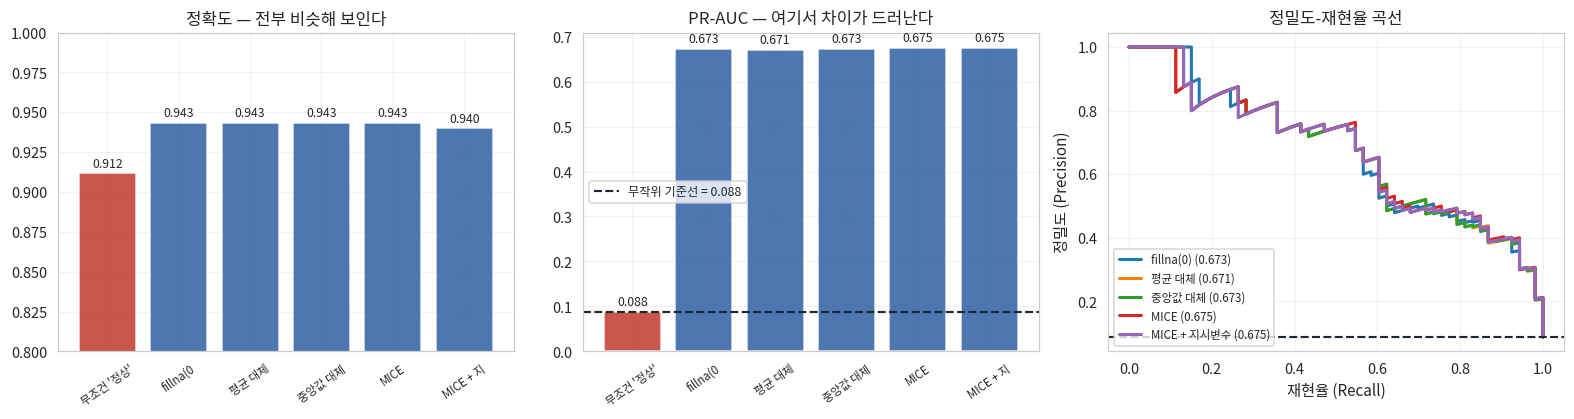

In [ ]:
# ============================================================
# 3-6. 분류 문제 — 불균형에서 정확도가 왜 쓸모없는가
# ============================================================
# 상위 8%만 '고가 매물'로 두어 불균형 이진 분류를 만든다
thr_price = np.quantile(clean["price"], 0.92)
y_cls_all = (clean["price"] > thr_price).astype(int)
print(f"양성(고가 매물) 비율: {y_cls_all.mean():.2%}")

Xc_tr = dirty.iloc[tr_idx][FEATURES]
Xc_te = clean.iloc[te_idx][FEATURES]
yc_tr = y_cls_all.iloc[tr_idx]
yc_te = y_cls_all.iloc[te_idx]

cls_strategies = {
    "fillna(0)": SimpleImputer(strategy="constant", fill_value=0),
    "평균 대체": SimpleImputer(strategy="mean"),
    "중앙값 대체": SimpleImputer(strategy="median"),
    "MICE": IterativeImputer(estimator=BayesianRidge(), max_iter=15, random_state=0),
    "MICE + 지시변수": IterativeImputer(estimator=BayesianRidge(), max_iter=15,
                                        random_state=0, add_indicator=True),
}

rows = []
proba_store = {}
for name, imp in cls_strategies.items():
    pipe = Pipeline([("imp", imp), ("sc", StandardScaler()),
                     ("m", LogisticRegression(max_iter=3000, class_weight=None))])
    pipe.fit(Xc_tr, yc_tr)
    prob = pipe.predict_proba(Xc_te)[:, 1]
    pred = (prob >= 0.5).astype(int)
    proba_store[name] = prob
    rows.append({
        "전략": name,
        "정확도": (pred == yc_te).mean(),
        "ROC-AUC": roc_auc_score(yc_te, prob),
        "PR-AUC": average_precision_score(yc_te, prob),
        "재현율": confusion_matrix(yc_te, pred)[1, 1] / max(yc_te.sum(), 1),
    })

# 베이스라인: 무조건 다수 클래스
rows.insert(0, {"전략": "무조건 '정상'이라 예측", "정확도": (yc_te == 0).mean(),
                "ROC-AUC": 0.5, "PR-AUC": yc_te.mean(), "재현율": 0.0})

cls_res = pd.DataFrame(rows)
show_table(cls_res, "분류 성능 — 정확도만 보면 아무것도 알 수 없다", "{:.4f}")

fig, axes = panel(1, 3, w=4.8, h=3.9)
xp_ = np.arange(len(cls_res))
axes[0].bar(xp_, cls_res["정확도"],
            color=[C["red"]] + [C["blue"]] * (len(cls_res) - 1), alpha=.85)
axes[0].set_ylim(0.8, 1.0)
axes[0].set_xticks(xp_, [s[:8] for s in cls_res["전략"]], rotation=35, fontsize=7.5)
axes[0].set_title("정확도 — 전부 비슷해 보인다")
annotate_bars(axes[0], "{:.3f}", dy=0.002)

axes[1].bar(xp_, cls_res["PR-AUC"],
            color=[C["red"]] + [C["blue"]] * (len(cls_res) - 1), alpha=.85)
axes[1].axhline(yc_te.mean(), color=C["dark"], ls="--", lw=1.4,
                label=f"무작위 기준선 = {yc_te.mean():.3f}")
axes[1].set_xticks(xp_, [s[:8] for s in cls_res["전략"]], rotation=35, fontsize=7.5)
axes[1].set_title("PR-AUC — 여기서 차이가 드러난다")
axes[1].legend(fontsize=8)
annotate_bars(axes[1], "{:.3f}")

from sklearn.metrics import precision_recall_curve
for name, prob in proba_store.items():
    pr, rc, _ = precision_recall_curve(yc_te, prob)
    axes[2].plot(rc, pr, lw=2, label=f"{name} ({average_precision_score(yc_te, prob):.3f})")
axes[2].axhline(yc_te.mean(), color=C["dark"], ls="--", lw=1.4)
axes[2].set_xlabel("재현율 (Recall)"); axes[2].set_ylabel("정밀도 (Precision)")
axes[2].set_title("정밀도-재현율 곡선")
axes[2].legend(fontsize=7.5, loc="lower left")

fig.tight_layout()
plt.show()

## 유방암 실습의 교훈이 여기서 반복됩니다

표의 첫 줄을 보세요. 무조건 정상이라고 예측하는 모델입니다. 코드로 치면 `return 0` 한 줄이죠.
정확도가 92%입니다. 아무것도 배우지 않았는데 말입니다.

첫 번째 막대그래프를 보면 모든 전략의 정확도가 0.92에서 0.95 사이에 몰려 있습니다.
이 그래프만 보면 전처리 전략이 아무 영향도 없는 것처럼 보입니다.

두 번째 그래프인 PR-AUC로 가면 완전히 다른 그림이 나옵니다.
베이스라인의 PR-AUC는 양성 비율인 0.08인데 실제 모델들은 그보다 훨씬 높고 전략 간 차이도 뚜렷합니다.

ROC-AUC도 이런 상황에서는 낙관적입니다.
ROC의 가로축인 거짓양성률은 분모가 음성 개수인데 음성이 92%라 분모가 큽니다.
거짓양성이 수십 건 늘어도 곡선이 거의 안 움직이죠.
PR 곡선은 정밀도의 분모가 "양성이라 예측한 개수"라서 이 문제가 없습니다.
불균형이 심할수록 PR-AUC를 봐야 하는 이유입니다.

실무로 옮기면, 불균형 데이터에서 정확도를 보고하면 안 됩니다.
회의에서 "정확도 95% 달성"이라고 말하는 순간 아무도 그게 `return 0`보다 나은지 알 수 없게 됩니다.
대신 PR-AUC와 Precision@k를 보고하고, 가능하면 비용으로 환산한 지표를 만드세요.
상위 100건을 심사했을 때 그중 몇 건이 진짜인가가 가장 정직한 숫자입니다.

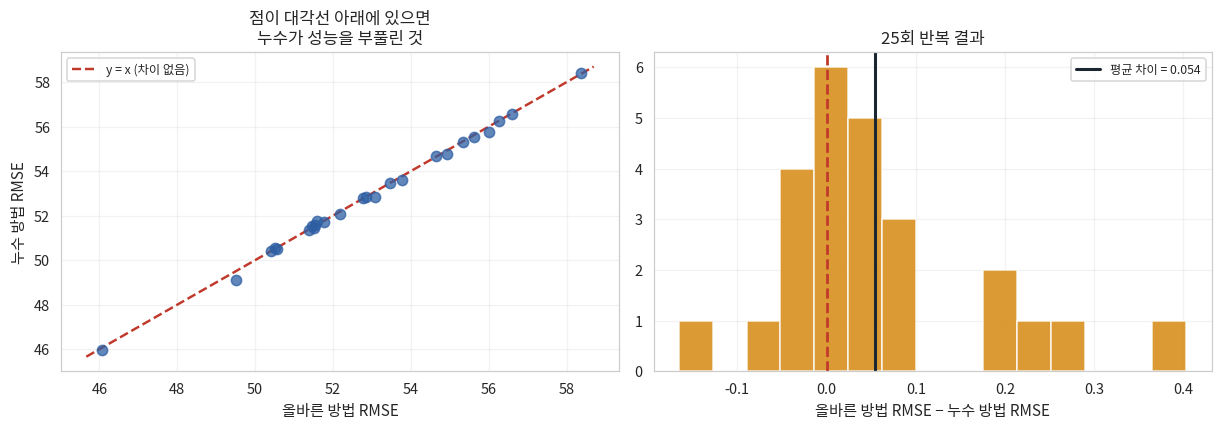

올바른 방법 평균 RMSE : 52.8861
누수 방법   평균 RMSE : 52.8318
누수가 성능을 더 좋게 보이게 한 횟수: 15 / 25
대응표본 t검정: t = 2.246, p = 0.0342


In [ ]:
# ============================================================
# 3-7. 데이터 누수 — 전체로 fit하면 성능이 얼마나 부풀려지는가
# ============================================================
def leakage_experiment(n_rep=30, miss_rate=0.30):
    rows = []
    for rep in range(n_rep):
        r = np.random.default_rng(900 + rep)
        d = clean.copy()
        for c in ["area", "age", "floor", "rooms"]:
            d.loc[r.random(len(d)) < miss_rate, c] = np.nan

        tr, te = train_test_split(np.arange(len(d)), test_size=0.3, random_state=rep)

        # (A) 올바른 방법: 훈련 데이터로만 fit
        pipe = Pipeline([("imp", IterativeImputer(estimator=BayesianRidge(),
                                                  max_iter=8, random_state=0)),
                         ("sc", StandardScaler()), ("m", Ridge(1.0))])
        pipe.fit(d.iloc[tr][FEATURES], d.iloc[tr][TARGET])
        rmse_ok = np.sqrt(mean_squared_error(clean.iloc[te][TARGET],
                                             pipe.predict(d.iloc[te][FEATURES])))

        # (B) 누수: 전체 데이터로 대치기를 fit
        imp = IterativeImputer(estimator=BayesianRidge(), max_iter=8, random_state=0)
        X_all_imp = imp.fit_transform(d[FEATURES])        # <-- 테스트 정보가 들어간다
        pipe2 = Pipeline([("sc", StandardScaler()), ("m", Ridge(1.0))])
        pipe2.fit(X_all_imp[tr], d.iloc[tr][TARGET])
        rmse_leak = np.sqrt(mean_squared_error(clean.iloc[te][TARGET],
                                               pipe2.predict(X_all_imp[te])))

        rows.append({"rep": rep, "올바른 방법 (train만 fit)": rmse_ok,
                     "누수 (전체로 fit)": rmse_leak})
    return pd.DataFrame(rows)


leak = leakage_experiment(n_rep=25)
diff = leak["올바른 방법 (train만 fit)"] - leak["누수 (전체로 fit)"]

fig, axes = panel(1, 2, w=5.6, h=4.0)
axes[0].scatter(leak["올바른 방법 (train만 fit)"], leak["누수 (전체로 fit)"],
                s=45, color=C["blue"], alpha=.75, zorder=4)
lim = [min(leak.min().min(), 0) * 0 + leak.iloc[:, 1:].min().min() - 0.3,
       leak.iloc[:, 1:].max().max() + 0.3]
axes[0].plot(lim, lim, color=C["red"], ls="--", lw=1.6, label="y = x (차이 없음)")
axes[0].set_xlabel("올바른 방법 RMSE"); axes[0].set_ylabel("누수 방법 RMSE")
axes[0].set_title("점이 대각선 아래에 있으면\n누수가 성능을 부풀린 것")
axes[0].legend(fontsize=8)

axes[1].hist(diff, bins=15, color=C["amber"], alpha=.85, edgecolor="white")
axes[1].axvline(0, color=C["red"], ls="--", lw=1.8)
axes[1].axvline(diff.mean(), color=C["dark"], lw=2, label=f"평균 차이 = {diff.mean():.3f}")
axes[1].set_xlabel("올바른 방법 RMSE − 누수 방법 RMSE")
axes[1].set_title(f"{len(leak)}회 반복 결과")
axes[1].legend(fontsize=8)
fig.tight_layout()
plt.show()

print(f"올바른 방법 평균 RMSE : {leak['올바른 방법 (train만 fit)'].mean():.4f}")
print(f"누수 방법   평균 RMSE : {leak['누수 (전체로 fit)'].mean():.4f}")
print(f"누수가 성능을 더 좋게 보이게 한 횟수: "
      f"{(diff > 0).sum()} / {len(leak)}")
t, pval = stats.ttest_rel(leak['올바른 방법 (train만 fit)'], leak['누수 (전체로 fit)'])
print(f"대응표본 t검정: t = {t:.3f}, p = {pval:.4f}")

## 누수는 조용히 옵니다

이 실험에서 차이는 크지 않습니다. 그게 오히려 위험한 지점입니다.

누수는 대개 극적인 형태로 오지 않습니다. RMSE가 절반으로 줄지 않아요. 0.5 정도 조용히 좋아집니다.
그래서 눈치채기가 어렵습니다.

그런데 이 조용한 이득이 문제를 일으키는 상황이 있습니다.
모델 A와 B를 비교하는데 A는 파이프라인을 썼고 B는 안 썼다면 B가 부당하게 유리해집니다.
하이퍼파라미터를 고를 때 누수된 검증 점수로 고르면 실제로는 나쁜 설정을 고를 수 있고요.
대회나 배포 환경에서는 미래 데이터를 미리 볼 수 없으니 누수로 얻은 이득이 통째로 사라집니다.

이 실험은 조건부로 온건한 편입니다. 다음 상황에서는 누수가 훨씬 커집니다.
표본이 작으면 테스트 데이터가 전체 통계량에 미치는 영향이 커지고,
`IterativeImputer`처럼 대치기가 실제로 회귀 모형을 학습하는 경우에는
전체로 fit하는 것이 곧 테스트 데이터로 모델을 학습하는 셈이 됩니다.
결측률이 높을수록 대치된 값이 많아 누수된 정보도 많아지고,
타깃 인코딩이나 스케일링까지 전체로 하면 누수가 누적됩니다.

결론은 간단합니다. `Pipeline`을 습관으로 만드세요. 그러면 이 실수를 구조적으로 할 수 없게 됩니다.

```python
# 이렇게 하지 마세요
X_imputed = SimpleImputer().fit_transform(X_all)     # 전체로 fit
X_tr, X_te = train_test_split(X_imputed, ...)

# 이렇게 하세요
pipe = Pipeline([("imp", SimpleImputer()), ("sc", StandardScaler()), ("m", Ridge())])
pipe.fit(X_tr, y_tr)        # 훈련 데이터로만 fit
pipe.predict(X_te)          # 테스트에는 transform만 적용된다
```

---

# 4부. 정리

## 오늘 확인한 것들

결측치 쪽부터 되짚어 보겠습니다.

메커니즘 세 가지를 직접 주입해 보니 MCAR과 MAR과 MNAR이 관측 그룹과 결측 그룹의 분포 차이로 나타났고,
MAR과 MNAR은 데이터만으로는 구분할 수 없다는 것을 확인했습니다.
결측 진단 세 장을 그려서 `rooms`와 `dist`가 항상 같이 빠지는 블록 결측을 발견했고,
완전제거 시뮬레이션에서는 변수별 18%가 행 기준 40% 손실로 증폭되는 $(1-r)^p$ 의 지수 붕괴를 봤습니다.

평균 대체의 분산 축소는 실측이 이론값 $\frac{m-1}{n-1}$ 과 정확히 맞았고 상관계수도 같은 비율로 감쇠했습니다.
결정론적 대치는 개별값 RMSE에서 이기고 분포 재현에서 지는데, $\sigma^2$ 을 버렸기 때문입니다.
대치기 여섯 개를 비교했더니 두 지표의 승자가 달랐고,
상관이 없는 변수는 어떤 방법으로도 복원되지 않았습니다.
MNAR에서는 "빠졌다는 사실"이 예측에 기여했지만 계수 해석에는 편향을 남겼습니다.

이상치 쪽에서는 같은 데이터에 세 기준이 서로 다른 답을 냈고,
IQR의 1.5가 정규분포 $\pm 2.7\sigma$ 에서 나온 설계값이라는 것을 유도했습니다.
마스킹 실험에서 Z-score는 오염률 7%를 넘자 재현율이 0으로 무너졌는데 붕괴점 0%의 실물이었습니다.
각 축에서는 정상인데 조합이 불가능한 점은 단변량 검사로 100% 놓쳤고요.

LOF는 수식을 그대로 옮긴 코드가 sklearn과 일치했고,
$a_1$ 과 $a_2$ 비교에서 전역 거리로는 $a_1$ 이 더 가까운데 LOF로는 훨씬 이상하다는 결과를 얻었습니다.
$c(256) \approx 10.24$ 를 검증했고 $E(h)=c(n)$ 에서 정확히 $s=0.5$ 가 나왔습니다.
서브샘플링에서는 데이터를 적게 쓸 때 AUC가 더 높았는데 마스킹이 해소되기 때문이었죠.
정규분포 데이터의 등고선이 십자로 뻗는 유령 영역도 확인했습니다.

성능 쪽에서는 모델을 바꾸지 않고 전처리만 바꿔서 RMSE가 25.8에서 63.9까지 벌어졌습니다.
RMSE가 비슷해도 계수 복원 품질은 전혀 달랐고요.
결측률 스윕에서는 결측이 설명변수에 의존하면 `dropna`가 멀쩡한데
타깃에 의존하면 대치가 오히려 더 크게 무너졌습니다.
이상치 5%만으로 OLS가 밀리고 Huber와 RANSAC이 버텼으며,
불균형 분류에서는 정확도로 안 보이던 차이가 PR-AUC에서 드러났습니다.
마지막으로 누수는 조용하지만 일관되게 성능을 부풀렸습니다.

## 실무 체크리스트

처리하기 전 진단 단계에서는 결측률 막대와 결측 지도와 결측 공발생 상관, 이 세 장을 반드시 그립니다.
결측 그룹과 비결측 그룹의 다른 변수 분포를 비교해서 MAR의 지문을 찾고,
결측이 왜 생겼는지를 도메인 담당자에게 직접 물어보세요. 데이터로는 MAR과 MNAR을 구분할 수 없습니다.
이상치는 단변량과 다변량 둘 다 보고, 발견하면 왜 이 값이 나왔는지를 수집 단계까지 거슬러 확인합니다.

처리 단계에서 `fillna(0)`은 0이 그 변수에서 실제로 의미 있을 때만 씁니다.
예측이 목적이면 대치 전략을 고민하는 것보다 지시변수를 추가하는 쪽이 효과적인 경우가 많고,
추론이나 신뢰구간이 목적이면 반드시 확률적 대치를 씁니다.
타깃이 결측인 행은 학습에서 제외하되 X는 버리지 않습니다.
이상치가 오류면 제거하고 진짜 현상일 수 있으면 로버스트 손실을 씁니다.
LOF를 쓸 때는 스케일링이 필수이고 Isolation Forest에는 필요 없습니다.
`contamination`은 학습되는 값이 아니라 주입하는 가정이라는 점을 기억하세요.

검증 단계에서는 모든 전처리를 `Pipeline` 안에서 훈련 데이터로만 `fit` 합니다.
대치 후에는 관측 분포와 대치 분포를 겹쳐 그려서 확인하고,
음수 면적이나 1을 넘는 확률 같은 불가능한 값이 생겼는지 점검합니다.
불균형 데이터에서 정확도는 보고하지 않습니다.
파라미터를 바꿔가며 결과가 안정적인지 확인하는데, 비지도에서는 안정성이 신뢰도의 대리 지표가 됩니다.
`random_state`를 고정하고 다중대치 $m$ 과 반복 수를 기록해 두세요.


## 마지막으로

오늘 실험 전체를 관통하는 문장 하나를 남깁니다.

> 추정한 값을 진짜 값인 것처럼 다루면, 우리는 항상 실제보다 더 확신하게 됩니다.

평균으로 채우면 분산이 줄고, 예측값으로 채우면 잔차가 사라지고, 전체 데이터로 fit하면 성능이 부풀려집니다.
전부 같은 실수의 변주입니다.

잔차 주입, 확률 샘플링, 다중 대치, 파이프라인, 로버스트 손실.
오늘 배운 기법들은 전부 이 한 가지 실수를 구조적으로 막기 위한 장치입니다.

데이터에 없는 것은 끝까지 없습니다.
우리가 할 수 있는 것은 그 없음의 크기를 정직하게 기록하는 것뿐입니다.

---